<a href="https://colab.research.google.com/github/Ganasa18/belajar-tensorflow/blob/main/risk_classifier_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# =========================================================
# CELL 1 — GOOGLE DRIVE + TRAINING PATH SETUP
# MODEL 02 — COMMAND RISK CLASSIFIER V2
# =========================================================

from google.colab import drive

import os


# =========================================================
# 1. MOUNT GOOGLE DRIVE
# =========================================================

DRIVE_MOUNT = (
    "/content/drive"
)


drive.mount(
    DRIVE_MOUNT,
    force_remount=False,
)


assert os.path.exists(
    f"{DRIVE_MOUNT}/MyDrive"
), "Google Drive belum mounted"


# =========================================================
# 2. V1 SOURCE DIRECTORY
# =========================================================
#
# V1 is READ-ONLY source for V2.
#
# Do not overwrite V1 files.
#
# =========================================================

V1_DIR = (
    f"{DRIVE_MOUNT}/MyDrive/"
    "command_risk"
)


assert os.path.exists(
    V1_DIR
), (
    "Command Risk V1 directory "
    "tidak ditemukan."
)


# =========================================================
# 3. V2 STORAGE DIRECTORY
# =========================================================

SAVE_DIR = (
    f"{DRIVE_MOUNT}/MyDrive/"
    "command_risk_v2"
)


os.makedirs(
    SAVE_DIR,
    exist_ok=True,
)


# =========================================================
# 4. V2 SUBDIRECTORIES
# =========================================================

RAW_DIR = (
    f"{SAVE_DIR}/raw"
)

PROCESSED_DIR = (
    f"{SAVE_DIR}/processed"
)

MINING_DIR = (
    f"{SAVE_DIR}/mining"
)

REPAIR_DIR = (
    f"{SAVE_DIR}/repair"
)

MODEL_DIR = (
    f"{SAVE_DIR}/models"
)

CHECKPOINT_DIR = (
    f"{MODEL_DIR}/checkpoints"
)

ONNX_DIR = (
    f"{MODEL_DIR}/onnx"
)

QUANTIZED_DIR = (
    f"{MODEL_DIR}/quantized"
)

REPORT_DIR = (
    f"{SAVE_DIR}/reports"
)

FEATURE_DIR = (
    f"{SAVE_DIR}/features"
)

BENCHMARK_DIR = (
    f"{SAVE_DIR}/benchmarks"
)


V2_DIRECTORIES = [

    RAW_DIR,

    PROCESSED_DIR,

    MINING_DIR,

    REPAIR_DIR,

    MODEL_DIR,

    CHECKPOINT_DIR,

    ONNX_DIR,

    QUANTIZED_DIR,

    REPORT_DIR,

    FEATURE_DIR,

    BENCHMARK_DIR,
]


for directory in (
    V2_DIRECTORIES
):

    os.makedirs(
        directory,
        exist_ok=True,
    )


# =========================================================
# 5. V1 DATASET SOURCE PATHS
# =========================================================
#
# Frozen Dataset V3 produced by V1.
#
# =========================================================

V1_TRUSTED_DIR = (
    f"{V1_DIR}/trusted"
)

V1_PROCESSED_DIR = (
    f"{V1_DIR}/processed"
)


V1_DATASET_V3_PATH = (
    f"{V1_TRUSTED_DIR}/"
    "command_risk_dataset_v3.jsonl"
)


V1_TRAIN_V3_PATH = (
    f"{V1_PROCESSED_DIR}/"
    "command_risk_train_v3.jsonl"
)


V1_VAL_V3_PATH = (
    f"{V1_PROCESSED_DIR}/"
    "command_risk_val_v3.jsonl"
)


V1_TEST_V3_PATH = (
    f"{V1_PROCESSED_DIR}/"
    "command_risk_test_v3.jsonl"
)


# =========================================================
# 6. V1 MODEL SOURCE PATHS
# =========================================================
#
# BEST CURRENT V1:
#
# SetFit BGE Small
# Validation Macro F1 = 0.8104
#
# Repair model is intentionally NOT used.
#
# =========================================================

V1_MODEL_DIR = (
    f"{V1_DIR}/models"
)


V1_SETFIT_MODEL_PATH = (
    f"{V1_MODEL_DIR}/"
    "setfit_bge_small_final"
)


V1_REJECTED_REPAIR_PATH = (
    f"{V1_MODEL_DIR}/"
    "setfit_bge_small_repair_final"
)


V1_TFIDF_MODEL_PATH = (
    f"{V1_MODEL_DIR}/"
    "command_risk_tfidf_final_candidate.joblib"
)


# =========================================================
# 7. MODEL 01 — ACTION CLASSIFIER SOURCE
# =========================================================
#
# Kept available for later V2 experiments.
#
# We will NOT inject Action Classifier features
# into the first V2 experiment yet.
#
# =========================================================

ACTION_CLASSIFIER_DIR = (
    f"{DRIVE_MOUNT}/MyDrive/"
    "action_classifier"
)


ACTION_TRUSTED_PATH = (
    f"{ACTION_CLASSIFIER_DIR}/"
    "trusted/"
    "action_classifier_trusted_v1.jsonl"
)


ACTION_MODEL_DIR = (
    f"{ACTION_CLASSIFIER_DIR}/"
    "models"
)


ACTION_ONNX_PATH = (
    f"{ACTION_MODEL_DIR}/"
    "onnx/"
    "action_classifier.onnx"
)


# =========================================================
# 8. V2 DATASET PATHS
# =========================================================

V2_DATASET_PATH = (
    f"{PROCESSED_DIR}/"
    "command_risk_dataset_v2.jsonl"
)


V2_TRAIN_PATH = (
    f"{PROCESSED_DIR}/"
    "train_v2.jsonl"
)


V2_VAL_PATH = (
    f"{PROCESSED_DIR}/"
    "validation_v2.jsonl"
)


V2_TEST_PATH = (
    f"{PROCESSED_DIR}/"
    "test_v2.jsonl"
)


# =========================================================
# 9. EMBEDDING PATHS
# =========================================================

TRAIN_EMBEDDINGS_PATH = (
    f"{FEATURE_DIR}/"
    "train_embeddings_v2.npy"
)


TRAIN_EMBEDDING_META_PATH = (
    f"{FEATURE_DIR}/"
    "train_embeddings_metadata_v2.jsonl"
)


VAL_EMBEDDINGS_PATH = (
    f"{FEATURE_DIR}/"
    "validation_embeddings_v2.npy"
)


# =========================================================
# 10. HARD-NEGATIVE MINING PATHS
# =========================================================

HARD_NEGATIVE_PATH = (
    f"{MINING_DIR}/"
    "hard_negatives_v2.jsonl"
)


HARD_NEGATIVE_AUDIT_PATH = (
    f"{MINING_DIR}/"
    "hard_negative_audit_v2.jsonl"
)


HARD_NEGATIVE_STATS_PATH = (
    f"{REPORT_DIR}/"
    "hard_negative_stats_v2.json"
)


NEAREST_NEIGHBOR_PATH = (
    f"{MINING_DIR}/"
    "cross_label_neighbors_v2.jsonl"
)


# =========================================================
# 11. V2 CURRICULUM PATHS
# =========================================================

CURRICULUM_DATASET_PATH = (
    f"{REPAIR_DIR}/"
    "setfit_v2_curriculum.jsonl"
)


CURRICULUM_STATS_PATH = (
    f"{REPORT_DIR}/"
    "curriculum_stats_v2.json"
)


# =========================================================
# 12. V2 MODEL OUTPUT PATHS
# =========================================================

SETFIT_V2_OUTPUT_DIR = (
    f"{MODEL_DIR}/"
    "setfit_v2_training"
)


SETFIT_V2_FINAL_PATH = (
    f"{MODEL_DIR}/"
    "setfit_v2_final"
)


SETFIT_V2_BEST_PATH = (
    f"{MODEL_DIR}/"
    "setfit_v2_best"
)


# =========================================================
# 13. ONNX / QUANTIZATION PATHS
# =========================================================

ONNX_MODEL_PATH = (
    f"{ONNX_DIR}/"
    "command_risk_v2.onnx"
)


ONNX_INT8_MODEL_PATH = (
    f"{QUANTIZED_DIR}/"
    "command_risk_v2_int8.onnx"
)


# =========================================================
# 14. REPORT PATHS
# =========================================================

METRICS_PATH = (
    f"{REPORT_DIR}/"
    "training_metrics_v2.json"
)


VALIDATION_PREDICTIONS_PATH = (
    f"{REPORT_DIR}/"
    "validation_predictions_v2.csv"
)


TEST_PREDICTIONS_PATH = (
    f"{REPORT_DIR}/"
    "test_predictions_v2.csv"
)


ERROR_ANALYSIS_PATH = (
    f"{REPORT_DIR}/"
    "error_analysis_v2.csv"
)


CONFUSION_MATRIX_PATH = (
    f"{REPORT_DIR}/"
    "confusion_matrix_v2.csv"
)


MODEL_COMPARISON_PATH = (
    f"{REPORT_DIR}/"
    "model_comparison_v2.json"
)


ONNX_PARITY_PATH = (
    f"{REPORT_DIR}/"
    "onnx_parity_v2.json"
)


BENCHMARK_PATH = (
    f"{BENCHMARK_DIR}/"
    "latency_benchmark_v2.json"
)


# =========================================================
# 15. BASELINE METRICS
# =========================================================
#
# Frozen reference values.
#
# DO NOT use held-out test for V2 tuning.
#
# =========================================================

V1_BASELINE_METRICS = {

    "tfidf_validation_macro_f1":
        0.7600,

    "tfidf_test_macro_f1":
        0.7304,

    "setfit_v1_validation_accuracy":
        0.8360,

    "setfit_v1_validation_macro_f1":
        0.8104,

    "setfit_v1_benign_f1":
        0.896,

    "setfit_v1_suspicious_f1":
        0.735,

    "setfit_v1_destructive_f1":
        0.800,

    "rejected_repair_macro_f1":
        0.7353,
}


# =========================================================
# 16. V2 EXPERIMENT CONFIG
# =========================================================

V2_BASE_ENCODER = (
    "BAAI/bge-small-en-v1.5"
)


RISK_LABELS = [

    "BENIGN",

    "SUSPICIOUS",

    "DESTRUCTIVE",
]


LABEL_TO_ID = {

    "BENIGN":
        0,

    "SUSPICIOUS":
        1,

    "DESTRUCTIVE":
        2,
}


ID_TO_LABEL = {

    value:
        key

    for key, value
    in LABEL_TO_ID.items()
}


# =========================================================
# 17. REQUIRED V1 FILE VALIDATION
# =========================================================

required_v1_paths = [

    V1_DATASET_V3_PATH,

    V1_TRAIN_V3_PATH,

    V1_VAL_V3_PATH,

    V1_TEST_V3_PATH,

    V1_SETFIT_MODEL_PATH,
]


missing_v1_paths = [

    path

    for path in required_v1_paths

    if not os.path.exists(
        path
    )
]


if missing_v1_paths:

    print()
    print(
        "WARNING — V1 source files "
        "tidak lengkap:"
    )

    for path in (
        missing_v1_paths
    ):

        print(
            "  MISSING:",
            path
        )

else:

    print()
    print(
        "V1 source validation: PASS"
    )


# =========================================================
# 18. V2 DIRECTORY VALIDATION
# =========================================================

assert os.path.exists(
    SAVE_DIR
)

assert os.path.exists(
    MINING_DIR
)

assert os.path.exists(
    MODEL_DIR
)

assert os.path.exists(
    REPORT_DIR
)

assert os.path.exists(
    FEATURE_DIR
)


# =========================================================
# 19. STATUS
# =========================================================

print()
print("=" * 78)
print(
    "MODEL 02 — COMMAND RISK CLASSIFIER V2"
)
print("=" * 78)

print()

print(
    "V1 source directory :",
    V1_DIR
)

print(
    "V2 save directory   :",
    SAVE_DIR
)

print()

print(
    "Dataset V3 source   :",
    V1_DATASET_V3_PATH
)

print(
    "Train V3 source     :",
    V1_TRAIN_V3_PATH
)

print(
    "Validation source   :",
    V1_VAL_V3_PATH
)

print(
    "Held-out test       :",
    V1_TEST_V3_PATH
)

print()

print(
    "SetFit V1 checkpoint:",
    V1_SETFIT_MODEL_PATH
)

print(
    "Base encoder        :",
    V2_BASE_ENCODER
)

print()

print(
    "Mining directory    :",
    MINING_DIR
)

print(
    "Embedding directory :",
    FEATURE_DIR
)

print(
    "V2 model output     :",
    SETFIT_V2_FINAL_PATH
)

print(
    "ONNX output         :",
    ONNX_MODEL_PATH
)

print()

print("-" * 78)

print(
    "V1 BEST VALIDATION MACRO F1 :",
    V1_BASELINE_METRICS[
        "setfit_v1_validation_macro_f1"
    ]
)

print(
    "V2 TARGET                     :",
    "> 0.8104 validation Macro F1"
)

print("-" * 78)

print()

print(
    "V2 strategy:"
)

print(
    "  Dataset V3"
)

print(
    "       ↓"
)

print(
    "  SetFit V1 checkpoint"
)

print(
    "       ↓"
)

print(
    "  embedding-based "
    "hard-negative mining"
)

print(
    "       ↓"
)

print(
    "  full-train anchored "
    "contrastive curriculum"
)

print(
    "       ↓"
)

print(
    "  SetFit V2"
)

print(
    "       ↓"
)

print(
    "  validation → held-out test "
    "→ ONNX → INT8"
)

print()

print("=" * 78)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

V1 source validation: PASS

MODEL 02 — COMMAND RISK CLASSIFIER V2

V1 source directory : /content/drive/MyDrive/command_risk
V2 save directory   : /content/drive/MyDrive/command_risk_v2

Dataset V3 source   : /content/drive/MyDrive/command_risk/trusted/command_risk_dataset_v3.jsonl
Train V3 source     : /content/drive/MyDrive/command_risk/processed/command_risk_train_v3.jsonl
Validation source   : /content/drive/MyDrive/command_risk/processed/command_risk_val_v3.jsonl
Held-out test       : /content/drive/MyDrive/command_risk/processed/command_risk_test_v3.jsonl

SetFit V1 checkpoint: /content/drive/MyDrive/command_risk/models/setfit_bge_small_final
Base encoder        : BAAI/bge-small-en-v1.5

Mining directory    : /content/drive/MyDrive/command_risk_v2/mining
Embedding directory : /content/drive/MyDrive/command_risk_v2/features
V2 model output     : /conten

In [3]:
# =========================================================
# CELL 2 — DEPENDENCIES + GPU VERIFICATION
# MODEL 02 — COMMAND RISK CLASSIFIER V2
# =========================================================

!pip install -q \
    setfit \
    sentence-transformers \
    datasets \
    accelerate \
    scikit-learn \
    joblib


# =========================================================
# 1. IMPORTS
# =========================================================

import os
import json
import time
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from collections import (
    Counter,
    defaultdict,
)

from datasets import (
    Dataset,
)

from setfit import (
    SetFitModel,
    Trainer,
    TrainingArguments,
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

from sklearn.neighbors import (
    NearestNeighbors,
)


# =========================================================
# 2. RANDOM SEED
# =========================================================

SEED = 42

random.seed(
    SEED
)

np.random.seed(
    SEED
)

torch.manual_seed(
    SEED
)


if torch.cuda.is_available():

    torch.cuda.manual_seed_all(
        SEED
    )


# =========================================================
# 3. DEVICE
# =========================================================

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print()
print("=" * 78)
print("COMMAND RISK V2 — ENVIRONMENT")
print("=" * 78)

print(
    "Torch version      :",
    torch.__version__
)

print(
    "CUDA available     :",
    torch.cuda.is_available()
)

print(
    "Device             :",
    DEVICE
)


if torch.cuda.is_available():

    print(
        "GPU                :",
        torch.cuda.get_device_name(
            0
        )
    )

    print(
        "CUDA version       :",
        torch.version.cuda
    )

    total_vram = (
        torch.cuda.get_device_properties(
            0
        ).total_memory
        / 1024**3
    )

    print(
        "VRAM               :",
        round(
            total_vram,
            2
        ),
        "GB"
    )

else:

    print()
    print(
        "WARNING: GPU belum aktif."
    )

    print(
        "SetFit V2 tetap bisa jalan, "
        "tetapi embedding/training akan lebih lambat."
    )


print("=" * 78)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.1/77.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.3 MB/s eta 0:00:00

COMMAND RISK V2 — ENVIRONMENT
Torch version      : 2.11.0+cu128
CUDA available     : True
Device             : cuda
GPU                : Tesla T4
CUDA version       : 12.8
VRAM               : 14.56 GB


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



V1 DATASET V3 — INTEGRITY CHECK

[TRAIN]
Rows: 2501
Groups: 2417
  BENIGN      :  1494 ( 59.74%)
  SUSPICIOUS  :   763 ( 30.51%)
  DESTRUCTIVE :   244 (  9.76%)

[VALIDATION]
Rows: 500
Groups: 487
  BENIGN      :   296 ( 59.20%)
  SUSPICIOUS  :   151 ( 30.20%)
  DESTRUCTIVE :    53 ( 10.60%)

[TEST]
Rows: 503
Groups: 486
  BENIGN      :   301 ( 59.84%)
  SUSPICIOUS  :   165 ( 32.80%)
  DESTRUCTIVE :    37 (  7.36%)

Hash leakage  : PASS
Group leakage : PASS


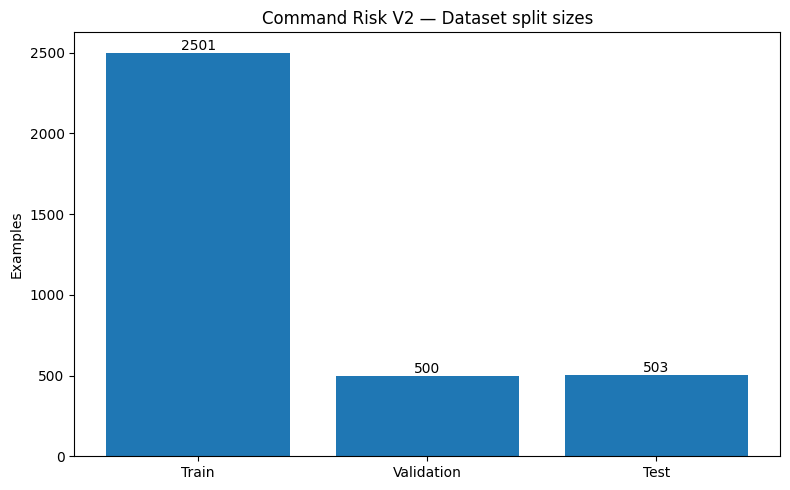

In [4]:
# =========================================================
# CELL 3 — LOAD V1 DATASET V3 + INTEGRITY CHECK
# MODEL 02 — COMMAND RISK CLASSIFIER V2
# =========================================================


# =========================================================
# 1. JSONL LOADER
# =========================================================

def load_jsonl(
    path
):

    rows = []

    with open(
        path,
        "r",
        encoding="utf-8",
    ) as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            rows.append(
                json.loads(
                    line
                )
            )

    return rows


# =========================================================
# 2. LOAD SPLITS
# =========================================================

train_rows = load_jsonl(
    V1_TRAIN_V3_PATH
)

val_rows = load_jsonl(
    V1_VAL_V3_PATH
)

test_rows = load_jsonl(
    V1_TEST_V3_PATH
)


train_df = pd.DataFrame(
    train_rows
)

val_df = pd.DataFrame(
    val_rows
)

test_df = pd.DataFrame(
    test_rows
)


# =========================================================
# 3. BASIC CHECKS
# =========================================================

required_columns = {

    "command",
    "command_hash",
    "risk",
    "source",
    "group_id",
}


for name, dataframe in [

    (
        "TRAIN",
        train_df
    ),

    (
        "VALIDATION",
        val_df
    ),

    (
        "TEST",
        test_df
    ),

]:

    missing = (
        required_columns
        - set(
            dataframe.columns
        )
    )

    assert not missing, (
        f"{name} missing columns: "
        f"{missing}"
    )


# =========================================================
# 4. LABEL CHECK
# =========================================================

for name, dataframe in [

    ("TRAIN", train_df),
    ("VALIDATION", val_df),
    ("TEST", test_df),

]:

    unknown_labels = set(
        dataframe[
            "risk"
        ].unique()
    ) - set(
        RISK_LABELS
    )

    assert not unknown_labels, (
        f"{name} unknown labels: "
        f"{unknown_labels}"
    )


# =========================================================
# 5. HASH LEAKAGE CHECK
# =========================================================

train_hashes = set(
    train_df[
        "command_hash"
    ]
)

val_hashes = set(
    val_df[
        "command_hash"
    ]
)

test_hashes = set(
    test_df[
        "command_hash"
    ]
)


assert train_hashes.isdisjoint(
    val_hashes
)

assert train_hashes.isdisjoint(
    test_hashes
)

assert val_hashes.isdisjoint(
    test_hashes
)


# =========================================================
# 6. GROUP LEAKAGE CHECK
# =========================================================

train_groups = set(
    train_df[
        "group_id"
    ]
)

val_groups = set(
    val_df[
        "group_id"
    ]
)

test_groups = set(
    test_df[
        "group_id"
    ]
)


assert train_groups.isdisjoint(
    val_groups
)

assert train_groups.isdisjoint(
    test_groups
)

assert val_groups.isdisjoint(
    test_groups
)


# =========================================================
# 7. DISTRIBUTION REPORT
# =========================================================

def print_distribution(
    name,
    dataframe,
):

    counts = Counter(
        dataframe[
            "risk"
        ]
    )

    print()
    print(
        f"[{name}]"
    )

    print(
        "Rows:",
        len(
            dataframe
        )
    )

    print(
        "Groups:",
        dataframe[
            "group_id"
        ].nunique()
    )


    for label in RISK_LABELS:

        count = counts.get(
            label,
            0
        )

        pct = (
            count
            / len(dataframe)
            * 100
        )

        print(
            f"  {label:<12}: "
            f"{count:>5} "
            f"({pct:6.2f}%)"
        )


print()
print("=" * 78)
print("V1 DATASET V3 — INTEGRITY CHECK")
print("=" * 78)


print_distribution(
    "TRAIN",
    train_df
)

print_distribution(
    "VALIDATION",
    val_df
)

print_distribution(
    "TEST",
    test_df
)


print()
print(
    "Hash leakage  : PASS"
)

print(
    "Group leakage : PASS"
)

print("=" * 78)


# =========================================================
# 8. GRAPH — SPLIT DISTRIBUTION
# =========================================================

split_names = [
    "Train",
    "Validation",
    "Test",
]

split_sizes = [
    len(train_df),
    len(val_df),
    len(test_df),
]


plt.figure(
    figsize=(8, 5)
)

bars = plt.bar(
    split_names,
    split_sizes
)

plt.title(
    "Command Risk V2 — Dataset split sizes"
)

plt.ylabel(
    "Examples"
)


for bar, value in zip(
    bars,
    split_sizes
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height(),

        str(value),

        ha="center",
        va="bottom",
    )


plt.tight_layout()

plt.show()


LOADING SETFIT V1
Checkpoint: /content/drive/MyDrive/command_risk/models/setfit_bge_small_final


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


SETFIT V1 — REPRODUCED VALIDATION
Accuracy: 0.836
Macro F1: 0.8104
Expected: 0.8104
Difference: 3e-06

BENIGN       P=0.907 R=0.885 F1=0.896
SUSPICIOUS   P=0.717 R=0.755 F1=0.735
DESTRUCTIVE  P=0.808 R=0.792 F1=0.800

Prediction time: 1.962 sec
Per command: 3.925 ms


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


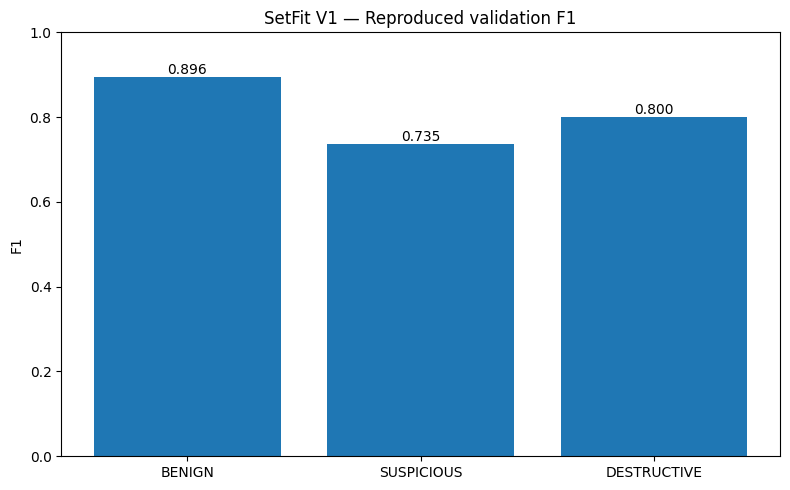

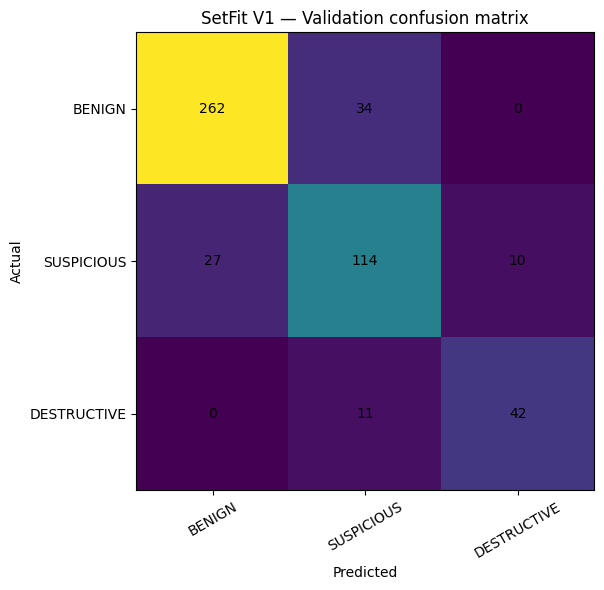

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
# =========================================================
# CELL 4 — LOAD SETFIT V1 + REPRODUCE BASELINE
# MODEL 02 — COMMAND RISK CLASSIFIER V2
# =========================================================


# =========================================================
# 1. LOAD MODEL
# =========================================================

print()
print("=" * 78)
print("LOADING SETFIT V1")
print("=" * 78)

print(
    "Checkpoint:",
    V1_SETFIT_MODEL_PATH
)


setfit_v1_model = (
    SetFitModel.from_pretrained(
        V1_SETFIT_MODEL_PATH
    )
)


# =========================================================
# 2. PREPARE VALIDATION INPUT
# =========================================================

val_texts = (
    val_df[
        "command"
    ]
    .astype(str)
    .tolist()
)


val_true_labels = (
    val_df[
        "risk"
    ]
    .tolist()
)


val_true_ids = np.array(
    [
        LABEL_TO_ID[
            label
        ]
        for label in (
            val_true_labels
        )
    ],
    dtype=int,
)


# =========================================================
# 3. PREDICT
# =========================================================

start = time.time()


v1_predictions_raw = (
    setfit_v1_model.predict(
        val_texts
    )
)


prediction_seconds = (
    time.time()
    - start
)


v1_predictions = np.asarray(
    v1_predictions_raw,
    dtype=int,
)


# =========================================================
# 4. METRICS
# =========================================================

v1_accuracy = (
    accuracy_score(
        val_true_ids,
        v1_predictions,
    )
)


v1_macro_f1 = (
    f1_score(
        val_true_ids,
        v1_predictions,
        average="macro",
        zero_division=0,
    )
)


v1_report = (
    classification_report(

        val_true_ids,

        v1_predictions,

        labels=[
            0,
            1,
            2,
        ],

        target_names=
            RISK_LABELS,

        output_dict=
            True,

        zero_division=
            0,
    )
)


v1_cm = (
    confusion_matrix(

        val_true_ids,

        v1_predictions,

        labels=[
            0,
            1,
            2,
        ],
    )
)


# =========================================================
# 5. BASELINE CHECK
# =========================================================

EXPECTED_MACRO_F1 = (
    V1_BASELINE_METRICS[
        "setfit_v1_validation_macro_f1"
    ]
)


difference = (
    v1_macro_f1
    - EXPECTED_MACRO_F1
)


print()
print("=" * 90)
print("SETFIT V1 — REPRODUCED VALIDATION")
print("=" * 90)

print(
    "Accuracy:",
    round(
        v1_accuracy,
        4
    )
)

print(
    "Macro F1:",
    round(
        v1_macro_f1,
        4
    )
)

print(
    "Expected:",
    EXPECTED_MACRO_F1
)

print(
    "Difference:",
    round(
        difference,
        6
    )
)

print()


for label in RISK_LABELS:

    metrics = (
        v1_report[
            label
        ]
    )

    print(
        f"{label:<12}"
        f" P={metrics['precision']:.3f}"
        f" R={metrics['recall']:.3f}"
        f" F1={metrics['f1-score']:.3f}"
    )


print()

print(
    "Prediction time:",
    round(
        prediction_seconds,
        3
    ),
    "sec"
)

print(
    "Per command:",
    round(
        prediction_seconds
        / len(
            val_texts
        )
        * 1000,
        3
    ),
    "ms"
)

print("=" * 90)


# =========================================================
# 6. GRAPH — BASELINE CLASS F1
# =========================================================

baseline_f1 = [
    v1_report[
        label
    ][
        "f1-score"
    ]
    for label in RISK_LABELS
]


plt.figure(
    figsize=(8, 5)
)

bars = plt.bar(
    RISK_LABELS,
    baseline_f1
)

plt.title(
    "SetFit V1 — Reproduced validation F1"
)

plt.ylabel(
    "F1"
)

plt.ylim(
    0,
    1
)


for bar, value in zip(
    bars,
    baseline_f1
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height(),

        f"{value:.3f}",

        ha="center",
        va="bottom",
    )


plt.tight_layout()

plt.show()


# =========================================================
# 7. GRAPH — CONFUSION MATRIX
# =========================================================

plt.figure(
    figsize=(7, 6)
)

plt.imshow(
    v1_cm
)

plt.title(
    "SetFit V1 — Validation confusion matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)


plt.xticks(
    range(
        len(
            RISK_LABELS
        )
    ),
    RISK_LABELS,
    rotation=30,
)

plt.yticks(
    range(
        len(
            RISK_LABELS
        )
    ),
    RISK_LABELS,
)


for i in range(
    len(
        RISK_LABELS
    )
):

    for j in range(
        len(
            RISK_LABELS
        )
    ):

        plt.text(
            j,
            i,
            str(
                v1_cm[
                    i,
                    j
                ]
            ),

            ha="center",
            va="center",
        )


plt.tight_layout()

plt.show()


TRAIN EMBEDDINGS — GENERATION
Rows: 2501
Batch size: 64
Device: cuda


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Batches:   0%|          | 0/40 [00:00<?, ?it/s]


Embedding time: 3.12 sec

TRAIN EMBEDDINGS READY
Rows              : 2501
Embedding dim     : 384
dtype             : float32
Mean norm         : 1.0
Min norm          : 1.0
Max norm          : 1.0

Embeddings saved  : /content/drive/MyDrive/command_risk_v2/features/train_embeddings_v2.npy
Metadata saved    : /content/drive/MyDrive/command_risk_v2/features/train_embeddings_metadata_v2.jsonl


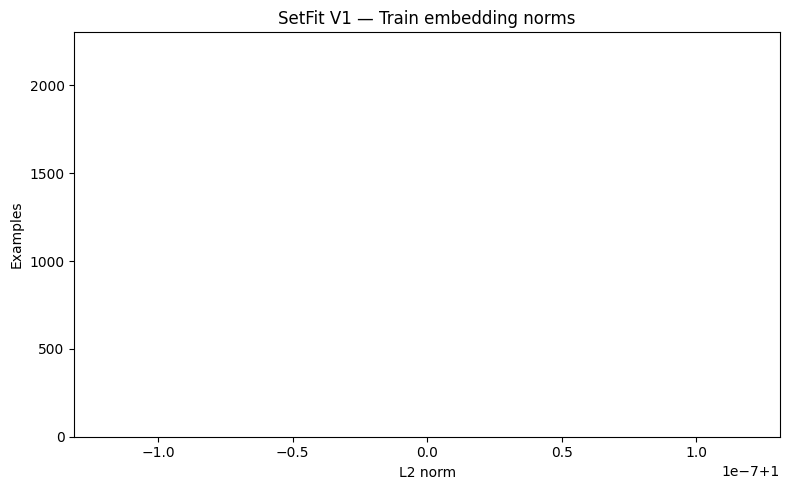

In [6]:
# =========================================================
# CELL 5 — GENERATE FULL TRAIN EMBEDDINGS
# CACHE + RESUME
# MODEL 02 — COMMAND RISK CLASSIFIER V2
# =========================================================

import numpy as np
import time


# =========================================================
# 1. CONFIG
# =========================================================

EMBED_BATCH_SIZE = (
    64
    if torch.cuda.is_available()
    else 16
)


FORCE_REBUILD_EMBEDDINGS = (
    False
)


# =========================================================
# 2. TRAIN TEXTS
# =========================================================

train_texts = (
    train_df[
        "command"
    ]
    .astype(str)
    .tolist()
)


# =========================================================
# 3. CACHE CHECK
# =========================================================

cache_available = (

    os.path.exists(
        TRAIN_EMBEDDINGS_PATH
    )

    and

    os.path.exists(
        TRAIN_EMBEDDING_META_PATH
    )

    and

    not FORCE_REBUILD_EMBEDDINGS
)


# =========================================================
# 4. LOAD OR GENERATE
# =========================================================

if cache_available:

    print()
    print("=" * 78)
    print("TRAIN EMBEDDINGS — LOAD CACHE")
    print("=" * 78)

    train_embeddings = np.load(
        TRAIN_EMBEDDINGS_PATH
    )

    embedding_meta = load_jsonl(
        TRAIN_EMBEDDING_META_PATH
    )


    if (
        train_embeddings.shape[0]
        != len(
            train_df
        )
    ):

        print(
            "Cache row count mismatch."
        )

        print(
            "Rebuilding embeddings..."
        )

        cache_available = False


if not cache_available:

    print()
    print("=" * 78)
    print("TRAIN EMBEDDINGS — GENERATION")
    print("=" * 78)

    print(
        "Rows:",
        len(
            train_texts
        )
    )

    print(
        "Batch size:",
        EMBED_BATCH_SIZE
    )

    print(
        "Device:",
        DEVICE
    )


    # =====================================================
    # BODY / SENTENCE TRANSFORMER
    # =====================================================

    encoder = (
        setfit_v1_model.model_body
    )


    start = time.time()


    train_embeddings = (
        encoder.encode(

            train_texts,

            batch_size=
                EMBED_BATCH_SIZE,

            show_progress_bar=
                True,

            convert_to_numpy=
                True,

            normalize_embeddings=
                True,
        )
    )


    embedding_seconds = (
        time.time()
        - start
    )


    train_embeddings = np.asarray(
        train_embeddings,
        dtype=np.float32,
    )


    # =====================================================
    # SAVE EMBEDDINGS
    # =====================================================

    np.save(
        TRAIN_EMBEDDINGS_PATH,
        train_embeddings,
    )


    # =====================================================
    # SAVE METADATA
    # =====================================================

    embedding_meta = []


    for idx, row in (
        train_df.iterrows()
    ):

        embedding_meta.append({

            "row_index":
                int(
                    idx
                ),

            "command":
                row[
                    "command"
                ],

            "command_hash":
                row[
                    "command_hash"
                ],

            "risk":
                row[
                    "risk"
                ],

            "source":
                row.get(
                    "source"
                ),

            "family":
                row.get(
                    "family"
                ),

            "group_id":
                row[
                    "group_id"
                ],
        })


    with open(
        TRAIN_EMBEDDING_META_PATH,
        "w",
        encoding="utf-8",
    ) as f:

        for row in (
            embedding_meta
        ):

            f.write(
                json.dumps(
                    row,
                    ensure_ascii=False,
                )
                + "\n"
            )


    print()
    print(
        "Embedding time:",
        round(
            embedding_seconds,
            2
        ),
        "sec"
    )


# =========================================================
# 5. INTEGRITY CHECK
# =========================================================

assert (
    train_embeddings.shape[0]
    ==
    len(
        train_df
    )
)


assert (
    len(
        embedding_meta
    )
    ==
    len(
        train_df
    )
)


# =========================================================
# 6. NORMALIZATION CHECK
# =========================================================

embedding_norms = np.linalg.norm(
    train_embeddings,
    axis=1,
)


# =========================================================
# 7. SUMMARY
# =========================================================

print()
print("=" * 78)
print("TRAIN EMBEDDINGS READY")
print("=" * 78)

print(
    "Rows              :",
    train_embeddings.shape[
        0
    ]
)

print(
    "Embedding dim     :",
    train_embeddings.shape[
        1
    ]
)

print(
    "dtype             :",
    train_embeddings.dtype
)

print(
    "Mean norm         :",
    round(
        float(
            embedding_norms.mean()
        ),
        6
    )
)

print(
    "Min norm          :",
    round(
        float(
            embedding_norms.min()
        ),
        6
    )
)

print(
    "Max norm          :",
    round(
        float(
            embedding_norms.max()
        ),
        6
    )
)

print()

print(
    "Embeddings saved  :",
    TRAIN_EMBEDDINGS_PATH
)

print(
    "Metadata saved    :",
    TRAIN_EMBEDDING_META_PATH
)

print("=" * 78)


# =========================================================
# GRAPH — EMBEDDING NORMS
# =========================================================

plt.figure(
    figsize=(8, 5)
)

plt.hist(
    embedding_norms,
    bins=25
)

plt.title(
    "SetFit V1 — Train embedding norms"
)

plt.xlabel(
    "L2 norm"
)

plt.ylabel(
    "Examples"
)

plt.tight_layout()

plt.show()

In [7]:
# =========================================================
# CELL 6 — CROSS-LABEL HARD-NEGATIVE MINING
# MODEL 02 — COMMAND RISK CLASSIFIER V2
# =========================================================

import numpy as np
import json
import time

from collections import Counter


# =========================================================
# 1. CONFIG
# =========================================================

TOP_K_PER_ANCHOR = 5

MINING_BATCH_SIZE = 256


# =========================================================
# 2. PREPARE LABEL ARRAYS
# =========================================================

train_labels = (
    train_df["risk"]
    .astype(str)
    .values
)

train_hashes = (
    train_df["command_hash"]
    .astype(str)
    .values
)

train_groups = (
    train_df["group_id"]
    .astype(str)
    .values
)


assert len(train_embeddings) == len(train_df)


# =========================================================
# 3. COSINE MINING
# =========================================================
#
# Embeddings already L2-normalized.
#
# cosine_similarity = dot product
#
# We process in chunks so this remains memory-safe
# if dataset grows later.
#
# =========================================================

print()
print("=" * 78)
print("CROSS-LABEL HARD-NEGATIVE MINING")
print("=" * 78)

print(
    "Rows:",
    len(train_df)
)

print(
    "Top-K cross-label per anchor:",
    TOP_K_PER_ANCHOR
)


mined_pairs = []

start_time = time.time()


for batch_start in range(
    0,
    len(train_embeddings),
    MINING_BATCH_SIZE,
):

    batch_end = min(
        batch_start
        + MINING_BATCH_SIZE,

        len(train_embeddings),
    )


    anchor_embeddings = (
        train_embeddings[
            batch_start:batch_end
        ]
    )


    similarities = (
        anchor_embeddings
        @ train_embeddings.T
    )


    for local_index in range(
        batch_end - batch_start
    ):

        anchor_index = (
            batch_start
            + local_index
        )

        anchor_label = (
            train_labels[
                anchor_index
            ]
        )


        scores = (
            similarities[
                local_index
            ]
        )


        # ---------------------------------------------
        # Exclude:
        # - itself
        # - same label
        # ---------------------------------------------

        valid_mask = (
            train_labels
            != anchor_label
        )


        valid_mask[
            anchor_index
        ] = False


        candidate_indices = np.where(
            valid_mask
        )[0]


        candidate_scores = (
            scores[
                candidate_indices
            ]
        )


        # ---------------------------------------------
        # TOP-K
        # ---------------------------------------------

        k = min(
            TOP_K_PER_ANCHOR,
            len(candidate_indices),
        )


        top_local = np.argpartition(
            candidate_scores,
            -k,
        )[-k:]


        top_local = top_local[
            np.argsort(
                candidate_scores[
                    top_local
                ]
            )[::-1]
        ]


        for rank, local_candidate in enumerate(
            top_local,
            start=1,
        ):

            neighbor_index = int(
                candidate_indices[
                    local_candidate
                ]
            )


            similarity = float(
                candidate_scores[
                    local_candidate
                ]
            )


            mined_pairs.append({

                "anchor_index":
                    int(anchor_index),

                "neighbor_index":
                    neighbor_index,

                "anchor_hash":
                    train_hashes[
                        anchor_index
                    ],

                "neighbor_hash":
                    train_hashes[
                        neighbor_index
                    ],

                "anchor_command":
                    train_df.iloc[
                        anchor_index
                    ]["command"],

                "neighbor_command":
                    train_df.iloc[
                        neighbor_index
                    ]["command"],

                "anchor_label":
                    anchor_label,

                "neighbor_label":
                    train_labels[
                        neighbor_index
                    ],

                "anchor_source":
                    train_df.iloc[
                        anchor_index
                    ].get(
                        "source"
                    ),

                "neighbor_source":
                    train_df.iloc[
                        neighbor_index
                    ].get(
                        "source"
                    ),

                "anchor_group":
                    train_groups[
                        anchor_index
                    ],

                "neighbor_group":
                    train_groups[
                        neighbor_index
                    ],

                "same_group":
                    (
                        train_groups[
                            anchor_index
                        ]
                        ==
                        train_groups[
                            neighbor_index
                        ]
                    ),

                "cosine_similarity":
                    similarity,

                "rank":
                    rank,
            })


mining_seconds = (
    time.time()
    - start_time
)


# =========================================================
# 4. DEDUP UNDIRECTED PAIRS
# =========================================================

unique_pairs = {}

for row in mined_pairs:

    pair_key = tuple(
        sorted(
            [
                row[
                    "anchor_hash"
                ],

                row[
                    "neighbor_hash"
                ],
            ]
        )
    )


    previous = (
        unique_pairs.get(
            pair_key
        )
    )


    if (
        previous is None
        or
        row[
            "cosine_similarity"
        ]
        >
        previous[
            "cosine_similarity"
        ]
    ):

        unique_pairs[
            pair_key
        ] = row


mined_unique = list(
    unique_pairs.values()
)


# =========================================================
# 5. SAVE
# =========================================================

with open(
    NEAREST_NEIGHBOR_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in mined_unique:

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
            )
            + "\n"
        )


# =========================================================
# 6. SUMMARY
# =========================================================

pair_distribution = Counter()


for row in mined_unique:

    pair = tuple(
        sorted(
            [
                row[
                    "anchor_label"
                ],

                row[
                    "neighbor_label"
                ],
            ]
        )
    )

    pair_distribution[
        pair
    ] += 1


print()
print("=" * 78)
print("MINING COMPLETE")
print("=" * 78)

print(
    "Raw directed pairs :",
    len(mined_pairs)
)

print(
    "Unique pairs       :",
    len(mined_unique)
)

print(
    "Mining time        :",
    round(
        mining_seconds,
        2
    ),
    "sec"
)

print()

print(
    "Label-pair distribution:"
)


for pair, count in (
    pair_distribution
    .most_common()
):

    print(
        f"  {pair[0]:<12}"
        f" <-> "
        f"{pair[1]:<12}"
        f": {count}"
    )


print()
print(
    "Saved:",
    NEAREST_NEIGHBOR_PATH
)

print("=" * 78)


CROSS-LABEL HARD-NEGATIVE MINING
Rows: 2501
Top-K cross-label per anchor: 5


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



MINING COMPLETE
Raw directed pairs : 12505
Unique pairs       : 12106
Mining time        : 2.98 sec

Label-pair distribution:
  BENIGN       <-> SUSPICIOUS  : 7477
  DESTRUCTIVE  <-> SUSPICIOUS  : 4618
  BENIGN       <-> DESTRUCTIVE : 11

Saved: /content/drive/MyDrive/command_risk_v2/mining/cross_label_neighbors_v2.jsonl


In [8]:
# =========================================================
# CELL 7 — HARD-NEGATIVE RANKING
# MODEL 02 — COMMAND RISK CLASSIFIER V2
# =========================================================

import pandas as pd
import numpy as np

from collections import Counter


# =========================================================
# 1. LOAD MINED PAIRS
# =========================================================

mined_rows = load_jsonl(
    NEAREST_NEIGHBOR_PATH
)


mined_df = pd.DataFrame(
    mined_rows
)


assert len(mined_df) > 0


# =========================================================
# 2. CANONICAL LABEL PAIR
# =========================================================

def canonical_label_pair(
    label_a,
    label_b,
):

    labels = sorted(
        [
            label_a,
            label_b,
        ]
    )

    return (
        f"{labels[0]}"
        f"__"
        f"{labels[1]}"
    )


mined_df[
    "label_pair"
] = [

    canonical_label_pair(
        a,
        b,
    )

    for a, b in zip(

        mined_df[
            "anchor_label"
        ],

        mined_df[
            "neighbor_label"
        ],
    )
]


# =========================================================
# 3. GLOBAL SIMILARITY STATS
# =========================================================

similarities = (
    mined_df[
        "cosine_similarity"
    ]
    .astype(float)
    .values
)


print()
print("=" * 90)
print("HARD-NEGATIVE SIMILARITY AUDIT")
print("=" * 90)

print(
    "Pairs:",
    len(mined_df)
)

print()

print(
    "Mean similarity :",
    round(
        float(
            similarities.mean()
        ),
        4
    )
)

print(
    "Median          :",
    round(
        float(
            np.median(
                similarities
            )
        ),
        4
    )
)


for percentile in [
    50,
    75,
    80,
    85,
    90,
    95,
    99,
]:

    print(
        f"P{percentile:<2}             :",
        round(
            float(
                np.percentile(
                    similarities,
                    percentile,
                )
            ),
            4,
        )
    )


# =========================================================
# 4. STATS PER LABEL PAIR
# =========================================================

print()
print("=" * 90)
print("SIMILARITY BY LABEL BOUNDARY")
print("=" * 90)


pair_stats = []


for label_pair, group in (
    mined_df.groupby(
        "label_pair"
    )
):

    values = (
        group[
            "cosine_similarity"
        ]
        .astype(float)
        .values
    )


    stats = {

        "label_pair":
            label_pair,

        "count":
            len(values),

        "mean":
            float(
                np.mean(
                    values
                )
            ),

        "median":
            float(
                np.median(
                    values
                )
            ),

        "p75":
            float(
                np.percentile(
                    values,
                    75
                )
            ),

        "p90":
            float(
                np.percentile(
                    values,
                    90
                )
            ),

        "max":
            float(
                np.max(
                    values
                )
            ),
    }


    pair_stats.append(
        stats
    )


for stats in sorted(
    pair_stats,
    key=lambda x:
        x[
            "mean"
        ],
    reverse=True,
):

    print()

    print(
        stats[
            "label_pair"
        ]
    )

    print(
        "  count  :",
        stats[
            "count"
        ]
    )

    print(
        "  mean   :",
        round(
            stats[
                "mean"
            ],
            4
        )
    )

    print(
        "  median :",
        round(
            stats[
                "median"
            ],
            4
        )
    )

    print(
        "  p75    :",
        round(
            stats[
                "p75"
            ],
            4
        )
    )

    print(
        "  p90    :",
        round(
            stats[
                "p90"
            ],
            4
        )
    )

    print(
        "  max    :",
        round(
            stats[
                "max"
            ],
            4
        )
    )


# =========================================================
# 5. RANK INSIDE EACH BOUNDARY
# =========================================================

mined_df[
    "boundary_rank"
] = (

    mined_df.groupby(
        "label_pair"
    )[
        "cosine_similarity"
    ]
    .rank(
        ascending=False,
        method="first",
    )
    .astype(int)
)


# Percentile relative to own boundary family.

mined_df[
    "similarity_percentile"
] = (

    mined_df.groupby(
        "label_pair"
    )[
        "cosine_similarity"
    ]
    .rank(
        pct=True
    )
)


# =========================================================
# 6. SAVE RANKED MINING RESULT
# =========================================================

with open(
    HARD_NEGATIVE_AUDIT_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in (
        mined_df
        .to_dict(
            orient="records"
        )
    ):

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
            )
            + "\n"
        )


print()
print("=" * 90)

print(
    "Saved ranked pairs:",
    HARD_NEGATIVE_AUDIT_PATH
)

print("=" * 90)


HARD-NEGATIVE SIMILARITY AUDIT
Pairs: 12106

Mean similarity : 0.9558
Median          : 0.9799
P50             : 0.9799
P75             : 0.9939
P80             : 0.9951
P85             : 0.9959
P90             : 0.9966
P95             : 0.9972
P99             : 0.998

SIMILARITY BY LABEL BOUNDARY

BENIGN__SUSPICIOUS
  count  : 7477
  mean   : 0.9861
  median : 0.9911
  p75    : 0.9959
  p90    : 0.997
  max    : 0.9989

DESTRUCTIVE__SUSPICIOUS
  count  : 4618
  mean   : 0.9076
  median : 0.9416
  p75    : 0.9659
  p90    : 0.9754
  max    : 0.9962

BENIGN__DESTRUCTIVE
  count  : 11
  mean   : 0.6226
  median : 0.6394
  p75    : 0.6712
  p90    : 0.7568
  max    : 0.8366


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Saved ranked pairs: /content/drive/MyDrive/command_risk_v2/mining/hard_negative_audit_v2.jsonl


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [9]:
# =========================================================
# CELL 8 — HARD-NEGATIVE QUALITY AUDIT
# MODEL 02 — COMMAND RISK CLASSIFIER V2
# =========================================================

import pandas as pd

from collections import Counter


# =========================================================
# 1. LOAD RANKED PAIRS
# =========================================================

hard_df = pd.DataFrame(
    load_jsonl(
        HARD_NEGATIVE_AUDIT_PATH
    )
)


# =========================================================
# 2. SAME-GROUP ANALYSIS
# =========================================================

same_group_count = int(
    hard_df[
        "same_group"
    ].sum()
)


different_group_count = (
    len(hard_df)
    - same_group_count
)


# =========================================================
# 3. SOURCE PAIR ANALYSIS
# =========================================================

source_pair_counts = Counter()


for _, row in (
    hard_df.iterrows()
):

    pair = tuple(
        sorted(
            [
                str(
                    row[
                        "anchor_source"
                    ]
                ),

                str(
                    row[
                        "neighbor_source"
                    ]
                ),
            ]
        )
    )


    source_pair_counts[
        pair
    ] += 1


# =========================================================
# 4. TOP HARD NEGATIVES
# =========================================================

print()
print("=" * 100)
print("HARD-NEGATIVE QUALITY AUDIT")
print("=" * 100)

print(
    "Pairs total       :",
    len(hard_df)
)

print(
    "Same boundary group:",
    same_group_count
)

print(
    "Different groups   :",
    different_group_count
)


print()
print(
    "Top source combinations:"
)


for pair, count in (
    source_pair_counts
    .most_common(
        10
    )
):

    print(
        f"  {pair[0]:<24}"
        f" <-> "
        f"{pair[1]:<24}"
        f": {count}"
    )


# =========================================================
# 5. SHOW TOP EXAMPLES PER LABEL BOUNDARY
# =========================================================

TOP_EXAMPLES_PER_BOUNDARY = 12


for label_pair in sorted(
    hard_df[
        "label_pair"
    ].unique()
):

    subset = (

        hard_df[
            hard_df[
                "label_pair"
            ]
            == label_pair
        ]

        .sort_values(
            "cosine_similarity",
            ascending=False,
        )

        .head(
            TOP_EXAMPLES_PER_BOUNDARY
        )
    )


    print()
    print("=" * 100)

    print(
        "BOUNDARY:",
        label_pair
    )

    print("=" * 100)


    for _, row in (
        subset.iterrows()
    ):

        print()

        print(
            "Similarity:",
            round(
                float(
                    row[
                        "cosine_similarity"
                    ]
                ),
                4,
            )
        )

        print(
            f"{row['anchor_label']:<12}: "
            f"{row['anchor_command']}"
        )

        print(
            f"{row['neighbor_label']:<12}: "
            f"{row['neighbor_command']}"
        )

        print(
            "Same group:",
            row[
                "same_group"
            ]
        )


# =========================================================
# 6. SAVE SUMMARY
# =========================================================

audit_summary = {

    "total_pairs":
        len(hard_df),

    "same_group_pairs":
        same_group_count,

    "different_group_pairs":
        different_group_count,

    "mean_similarity":
        float(
            hard_df[
                "cosine_similarity"
            ].mean()
        ),

    "median_similarity":
        float(
            hard_df[
                "cosine_similarity"
            ].median()
        ),
}


with open(
    HARD_NEGATIVE_STATS_PATH,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        audit_summary,
        f,
        indent=2,
    )


print()
print(
    "Audit summary:",
    HARD_NEGATIVE_STATS_PATH
)


HARD-NEGATIVE QUALITY AUDIT
Pairs total       : 12106
Same boundary group: 9
Different groups   : 12097

Top source combinations:
  real_teacher             <-> real_teacher            : 9399
  real_teacher             <-> synthetic_boundary      : 1150
  controlled_boundary      <-> real_teacher            : 1062
  controlled_boundary      <-> synthetic_boundary      : 315
  synthetic_boundary       <-> synthetic_boundary      : 149
  controlled_boundary      <-> controlled_boundary     : 31

BOUNDARY: BENIGN__DESTRUCTIVE

Similarity: 0.8366
BENIGN      : find /usr/bin -type f -iname "*.sh" | shuf -n 1
DESTRUCTIVE : sudo lvremove volume_group/logical_volume
Same group: False

Similarity: 0.7568
DESTRUCTIVE : find / | xargs sort -h
BENIGN      : find /usr/bin -type f -iname "*.sh" | shuf -n 1
Same group: False

Similarity: 0.6866
DESTRUCTIVE : find / | xargs sort -h
BENIGN      : find "$1" -perm -u+r -print0 | xargs chmod g+r
Same group: False

Similarity: 0.6558
BENIGN      : find / 

In [10]:
# =========================================================
# CELL 9 — BUILD FULL-TRAIN ANCHORED V2 CURRICULUM
# MODEL 02 — COMMAND RISK CLASSIFIER V2
# =========================================================

import pandas as pd
import numpy as np

from collections import Counter


# =========================================================
# 1. CONFIG
# =========================================================
#
# Main semantic boundaries:
#
# BENIGN <-> SUSPICIOUS
# SUSPICIOUS <-> DESTRUCTIVE
#
# BENIGN <-> DESTRUCTIVE gets lower emphasis because
# these classes should usually be easier to separate.
#
# =========================================================

BOUNDARY_QUOTAS = {

    "BENIGN__SUSPICIOUS":
        400,

    "DESTRUCTIVE__SUSPICIOUS":
        300,

    "BENIGN__DESTRUCTIVE":
        100,
}


# =========================================================
# 2. SELECT TOP HARD PAIRS PER BOUNDARY
# =========================================================

selected_pair_parts = []


for label_pair, quota in (
    BOUNDARY_QUOTAS.items()
):

    subset = hard_df[
        hard_df[
            "label_pair"
        ]
        == label_pair
    ].copy()


    subset = subset.sort_values(
        "cosine_similarity",
        ascending=False,
    )


    subset = subset.head(
        min(
            quota,
            len(subset),
        )
    )


    selected_pair_parts.append(
        subset
    )


selected_pairs = pd.concat(
    selected_pair_parts,
    ignore_index=True,
)


# =========================================================
# 3. EXTRACT ENDPOINT HASHES
# =========================================================

hard_hash_counts = Counter()


for _, row in (
    selected_pairs.iterrows()
):

    hard_hash_counts[
        row[
            "anchor_hash"
        ]
    ] += 1

    hard_hash_counts[
        row[
            "neighbor_hash"
        ]
    ] += 1


# =========================================================
# 4. BUILD FULL-TRAIN BASE
# =========================================================

curriculum_rows = []


for _, row in (
    train_df.iterrows()
):

    item = row.to_dict()

    item[
        "curriculum_source"
    ] = "full_train"

    item[
        "hard_negative_hits"
    ] = hard_hash_counts.get(
        row[
            "command_hash"
        ],
        0,
    )

    curriculum_rows.append(
        item
    )


# =========================================================
# 5. HARD-NEGATIVE EMPHASIS
# =========================================================
#
# Important:
#
# We do NOT replace full train.
#
# We add additional copies only for endpoints that appear
# in highly similar cross-label pairs.
#
# Maximum duplication is capped to avoid minority drift.
#
# =========================================================

MAX_EXTRA_COPIES = 2


train_by_hash = {

    row[
        "command_hash"
    ]:
        row

    for _, row in (
        train_df.iterrows()
    )
}


extra_rows = []


for command_hash_value, hits in (
    hard_hash_counts.items()
):

    if command_hash_value not in (
        train_by_hash
    ):

        continue


    base_row = (
        train_by_hash[
            command_hash_value
        ]
        .to_dict()
    )


    # ---------------------------------------------
    # Emphasis strength
    # ---------------------------------------------

    if hits >= 3:

        copies = 2

    else:

        copies = 1


    copies = min(
        copies,
        MAX_EXTRA_COPIES,
    )


    for copy_index in range(
        copies
    ):

        item = dict(
            base_row
        )

        item[
            "curriculum_source"
        ] = "hard_negative_emphasis"

        item[
            "hard_negative_hits"
        ] = int(
            hits
        )

        item[
            "emphasis_copy"
        ] = (
            copy_index
            + 1
        )


        extra_rows.append(
            item
        )


# =========================================================
# 6. COMBINE
# =========================================================

curriculum_rows.extend(
    extra_rows
)


curriculum_df = pd.DataFrame(
    curriculum_rows
)


# =========================================================
# 7. SHUFFLE
# =========================================================

curriculum_df = (

    curriculum_df.sample(
        frac=1,
        random_state=42,
    )

    .reset_index(
        drop=True
    )
)


# =========================================================
# 8. SAVE CURRICULUM
# =========================================================

with open(
    CURRICULUM_DATASET_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in (
        curriculum_df
        .to_dict(
            orient="records"
        )
    ):

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
                default=str,
            )
            + "\n"
        )


# =========================================================
# 9. SAVE SELECTED HARD PAIRS
# =========================================================

with open(
    HARD_NEGATIVE_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in (
        selected_pairs
        .to_dict(
            orient="records"
        )
    ):

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
                default=str,
            )
            + "\n"
        )


# =========================================================
# 10. DISTRIBUTIONS
# =========================================================

original_distribution = Counter(
    train_df[
        "risk"
    ]
)


curriculum_distribution = Counter(
    curriculum_df[
        "risk"
    ]
)


curriculum_source_distribution = Counter(
    curriculum_df[
        "curriculum_source"
    ]
)


# =========================================================
# 11. REPORT
# =========================================================

print()
print("=" * 90)
print("SETFIT V2 — FULL-TRAIN ANCHORED CURRICULUM")
print("=" * 90)

print(
    "Original training rows:",
    len(
        train_df
    )
)

print(
    "Selected hard pairs:",
    len(
        selected_pairs
    )
)

print(
    "Unique emphasized commands:",
    len(
        hard_hash_counts
    )
)

print(
    "Extra training rows:",
    len(
        extra_rows
    )
)

print(
    "Final curriculum rows:",
    len(
        curriculum_df
    )
)


print()
print(
    "Selected hard pairs:"
)


for pair, count in Counter(
    selected_pairs[
        "label_pair"
    ]
).items():

    print(
        f"  {pair:<30}:",
        count
    )


print()
print(
    "Original → Curriculum distribution:"
)


for label in RISK_LABELS:

    before = (
        original_distribution[
            label
        ]
    )

    after = (
        curriculum_distribution[
            label
        ]
    )

    print(
        f"  {label:<12}: "
        f"{before:>4} "
        f"→ "
        f"{after:>4} "
        f"({after/len(curriculum_df)*100:6.2f}%)"
    )


print()
print(
    "Curriculum source:"
)


for source, count in (
    curriculum_source_distribution.items()
):

    print(
        f"  {source:<28}:",
        count
    )


# =========================================================
# 12. SAVE STATS
# =========================================================

curriculum_stats = {

    "original_train_rows":
        len(train_df),

    "selected_hard_pairs":
        len(selected_pairs),

    "unique_emphasized_commands":
        len(hard_hash_counts),

    "extra_rows":
        len(extra_rows),

    "curriculum_rows":
        len(curriculum_df),

    "label_distribution":
        dict(
            curriculum_distribution
        ),

    "source_distribution":
        dict(
            curriculum_source_distribution
        ),
}


with open(
    CURRICULUM_STATS_PATH,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        curriculum_stats,
        f,
        indent=2,
    )


print()
print(
    "Curriculum:",
    CURRICULUM_DATASET_PATH
)

print(
    "Hard pairs:",
    HARD_NEGATIVE_PATH
)

print("=" * 90)


SETFIT V2 — FULL-TRAIN ANCHORED CURRICULUM
Original training rows: 2501
Selected hard pairs: 711
Unique emphasized commands: 612
Extra training rows: 631
Final curriculum rows: 3132

Selected hard pairs:
  BENIGN__SUSPICIOUS            : 400
  DESTRUCTIVE__SUSPICIOUS       : 300
  BENIGN__DESTRUCTIVE           : 11

Original → Curriculum distribution:
  BENIGN      : 1494 → 1846 ( 58.94%)
  SUSPICIOUS  :  763 → 1009 ( 32.22%)
  DESTRUCTIVE :  244 →  277 (  8.84%)

Curriculum source:
  full_train                  : 2501
  hard_negative_emphasis      : 631

Curriculum: /content/drive/MyDrive/command_risk_v2/repair/setfit_v2_curriculum.jsonl
Hard pairs: /content/drive/MyDrive/command_risk_v2/mining/hard_negatives_v2.jsonl


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [12]:
# =========================================================
# CELL 10 — EMBEDDING HUBNESS AUDIT
# MODEL 02 — COMMAND RISK CLASSIFIER V2
# =========================================================

import pandas as pd
import numpy as np

from collections import Counter


# =========================================================
# 1. LOAD MINED PAIRS
# =========================================================

mined_df = pd.DataFrame(
    load_jsonl(
        HARD_NEGATIVE_AUDIT_PATH
    )
)


# =========================================================
# 2. ENDPOINT FREQUENCY
# =========================================================

neighbor_frequency = Counter(
    mined_df[
        "neighbor_hash"
    ]
)


anchor_frequency = Counter(
    mined_df[
        "anchor_hash"
    ]
)


endpoint_frequency = Counter()


for _, row in mined_df.iterrows():

    endpoint_frequency[
        row["anchor_hash"]
    ] += 1

    endpoint_frequency[
        row["neighbor_hash"]
    ] += 1


# =========================================================
# 3. LOOKUP
# =========================================================

command_lookup = {

    row["command_hash"]: {

        "command":
            row["command"],

        "risk":
            row["risk"],
    }

    for _, row
    in train_df.iterrows()
}


# =========================================================
# 4. HUB STATS
# =========================================================

neighbor_counts = np.array(
    list(
        neighbor_frequency.values()
    ),
    dtype=float,
)


print()
print("=" * 100)
print("EMBEDDING HUBNESS AUDIT")
print("=" * 100)

print(
    "Unique neighbor endpoints:",
    len(
        neighbor_frequency
    )
)

print(
    "Mean neighbor frequency:",
    round(
        float(
            neighbor_counts.mean()
        ),
        2
    )
)

print(
    "Median:",
    round(
        float(
            np.median(
                neighbor_counts
            )
        ),
        2
    )
)


for p in [
    90,
    95,
    99,
]:

    print(
        f"P{p}:",
        round(
            float(
                np.percentile(
                    neighbor_counts,
                    p
                )
            ),
            2,
        )
    )


print(
    "Max:",
    int(
        neighbor_counts.max()
    )
)


# =========================================================
# 5. TOP HUBS
# =========================================================

print()
print("=" * 100)
print("TOP CROSS-LABEL NEIGHBOR HUBS")
print("=" * 100)


for rank, (
    command_hash_value,
    count
) in enumerate(
    neighbor_frequency.most_common(
        20
    ),
    start=1,
):

    info = command_lookup.get(
        command_hash_value,
        {}
    )

    print()
    print(
        f"{rank:02d}. "
        f"frequency={count}"
    )

    print(
        "Label:",
        info.get(
            "risk"
        )
    )

    print(
        "Command:",
        info.get(
            "command"
        )
    )


# =========================================================
# 6. HUB THRESHOLD
# =========================================================
#
# Anything above P99 is highly suspicious as a hub.
#
# Use at least 10 to avoid overly aggressive filtering.
#
# =========================================================

HUB_THRESHOLD = max(
    10,

    int(
        np.ceil(
            np.percentile(
                neighbor_counts,
                99
            )
        )
    )
)


hub_hashes = {

    command_hash_value

    for (
        command_hash_value,
        count
    ) in (
        neighbor_frequency.items()
    )

    if count > HUB_THRESHOLD
}


print()
print("=" * 100)

print(
    "Hub threshold:",
    HUB_THRESHOLD
)

print(
    "Detected hubs:",
    len(
        hub_hashes
    )
)

print("=" * 100)


EMBEDDING HUBNESS AUDIT
Unique neighbor endpoints: 331
Mean neighbor frequency: 36.57
Median: 2.0
P90: 24.0
P95: 74.5
P99: 1482.7
Max: 1485

TOP CROSS-LABEL NEIGHBOR HUBS

01. frequency=1485
Label: SUSPICIOUS
Command: chcon -u user filename

02. frequency=1485
Label: SUSPICIOUS
Command: shuf -i 1-10 -n 1 | xargs curl -O {}.txt

03. frequency=1485
Label: SUSPICIOUS
Command: find $(pwd) -name '*.sh' -exec chmod 700 {} \;

04. frequency=1483
Label: SUSPICIOUS
Command: cp `awk 'BEGIN { for (i=0; i<100; i++) print int(rand()*100) }'` /tmp/file.txt

05. frequency=1482
Label: SUSPICIOUS
Command: find -type d -print | xargs -I {} cp ~{} ~{}/output

06. frequency=570
Label: DESTRUCTIVE
Command: rm -rf <CRITICAL_SYSTEM_DIR>

07. frequency=515
Label: DESTRUCTIVE
Command: sudo chown -R user:user /

08. frequency=463
Label: DESTRUCTIVE
Command: rm -rf <SYSTEM_DATA_DIR>

09. frequency=398
Label: DESTRUCTIVE
Command: `grep -vEiRl ".*" /dev/* | sort | uniq | shuf | sed 's|.*|touch &|' | sh`

10. freq

In [18]:
# =========================================================
# CELL 11 — MUTUAL CROSS-LABEL NEAREST NEIGHBOR MINING
# FIXED — DIRECT FROM EMBEDDINGS
# MODEL 02 — COMMAND RISK CLASSIFIER V2
# =========================================================

import numpy as np
import pandas as pd

from collections import Counter


# =========================================================
# 1. CONFIG
# =========================================================

MUTUAL_TOP_K = 10

MINING_BATCH_SIZE = 256


# =========================================================
# 2. INPUT ARRAYS
# =========================================================

labels_array = (
    train_df[
        "risk"
    ]
    .astype(str)
    .values
)


hashes_array = (
    train_df[
        "command_hash"
    ]
    .astype(str)
    .values
)


commands_array = (
    train_df[
        "command"
    ]
    .astype(str)
    .values
)


groups_array = (
    train_df[
        "group_id"
    ]
    .astype(str)
    .values
)


sources_array = (
    train_df[
        "source"
    ]
    .astype(str)
    .values
)


assert (
    len(train_embeddings)
    ==
    len(train_df)
)


# =========================================================
# 3. DIRECTED CROSS-LABEL TOP-K
# =========================================================
#
# IMPORTANT:
#
# Do NOT deduplicate A->B and B->A here.
#
# Reciprocal information must remain intact.
#
# =========================================================

directed_neighbors = {}


print()
print("=" * 90)
print("REBUILDING DIRECTED CROSS-LABEL NEIGHBORS")
print("=" * 90)

print(
    "Rows:",
    len(
        train_df
    )
)

print(
    "Top-K:",
    MUTUAL_TOP_K
)


for batch_start in range(
    0,
    len(train_embeddings),
    MINING_BATCH_SIZE,
):

    batch_end = min(

        batch_start
        + MINING_BATCH_SIZE,

        len(train_embeddings),
    )


    batch_embeddings = (
        train_embeddings[
            batch_start:
            batch_end
        ]
    )


    # embeddings already normalized
    similarities = (
        batch_embeddings
        @ train_embeddings.T
    )


    for local_idx in range(
        batch_end
        - batch_start
    ):

        anchor_idx = (
            batch_start
            + local_idx
        )


        anchor_label = (
            labels_array[
                anchor_idx
            ]
        )


        # Different labels only.
        candidate_mask = (
            labels_array
            != anchor_label
        )


        candidate_mask[
            anchor_idx
        ] = False


        candidate_indices = np.where(
            candidate_mask
        )[0]


        if len(
            candidate_indices
        ) == 0:

            directed_neighbors[
                anchor_idx
            ] = []

            continue


        candidate_scores = (
            similarities[
                local_idx,
                candidate_indices
            ]
        )


        k = min(
            MUTUAL_TOP_K,
            len(
                candidate_indices
            ),
        )


        if k <= 0:

            directed_neighbors[
                anchor_idx
            ] = []

            continue


        # Faster than full sorting.
        top_positions = np.argpartition(
            candidate_scores,
            -k,
        )[-k:]


        top_positions = top_positions[
            np.argsort(
                candidate_scores[
                    top_positions
                ]
            )[::-1]
        ]


        neighbors = []


        for rank, position in enumerate(
            top_positions,
            start=1,
        ):

            neighbor_idx = int(
                candidate_indices[
                    position
                ]
            )


            neighbors.append({

                "neighbor_index":
                    neighbor_idx,

                "similarity":
                    float(
                        candidate_scores[
                            position
                        ]
                    ),

                "rank":
                    rank,
            })


        directed_neighbors[
            anchor_idx
        ] = neighbors


# =========================================================
# 4. FAST RECIPROCAL LOOKUP
# =========================================================

directed_sets = {

    anchor_idx:
        {
            item[
                "neighbor_index"
            ]
            for item in neighbors
        }

    for anchor_idx, neighbors
    in directed_neighbors.items()
}


# =========================================================
# 5. BUILD MUTUAL PAIRS
# =========================================================

mutual_rows = []

seen_pairs = set()


for anchor_idx, neighbors in (
    directed_neighbors.items()
):

    for item in neighbors:

        neighbor_idx = (
            item[
                "neighbor_index"
            ]
        )


        # Is A also present in B's top-K?
        reverse_set = (
            directed_sets.get(
                neighbor_idx,
                set(),
            )
        )


        if (
            anchor_idx
            not in reverse_set
        ):

            continue


        # Dedup only AFTER reciprocal test.
        pair_key = tuple(
            sorted(
                [
                    int(anchor_idx),
                    int(neighbor_idx),
                ]
            )
        )


        if pair_key in seen_pairs:

            continue


        seen_pairs.add(
            pair_key
        )


        # Reverse similarity/rank
        reverse_item = next(
            (
                x
                for x in directed_neighbors.get(
                    neighbor_idx,
                    []
                )
                if x[
                    "neighbor_index"
                ]
                == anchor_idx
            ),
            None,
        )


        forward_similarity = float(
            item[
                "similarity"
            ]
        )


        reverse_similarity = float(
            reverse_item[
                "similarity"
            ]
            if reverse_item
            else forward_similarity
        )


        # They should be effectively equal for cosine,
        # but averaging is safe.
        mutual_similarity = (
            forward_similarity
            + reverse_similarity
        ) / 2


        mutual_rows.append({

            "anchor_index":
                int(
                    anchor_idx
                ),

            "neighbor_index":
                int(
                    neighbor_idx
                ),

            "anchor_hash":
                hashes_array[
                    anchor_idx
                ],

            "neighbor_hash":
                hashes_array[
                    neighbor_idx
                ],

            "anchor_command":
                commands_array[
                    anchor_idx
                ],

            "neighbor_command":
                commands_array[
                    neighbor_idx
                ],

            "anchor_label":
                labels_array[
                    anchor_idx
                ],

            "neighbor_label":
                labels_array[
                    neighbor_idx
                ],

            "anchor_source":
                sources_array[
                    anchor_idx
                ],

            "neighbor_source":
                sources_array[
                    neighbor_idx
                ],

            "anchor_group":
                groups_array[
                    anchor_idx
                ],

            "neighbor_group":
                groups_array[
                    neighbor_idx
                ],

            "same_group":
                (
                    groups_array[
                        anchor_idx
                    ]
                    ==
                    groups_array[
                        neighbor_idx
                    ]
                ),

            "forward_rank":
                int(
                    item[
                        "rank"
                    ]
                ),

            "reverse_rank":
                int(
                    reverse_item[
                        "rank"
                    ]
                )
                if reverse_item
                else None,

            "cosine_similarity":
                float(
                    mutual_similarity
                ),
        })


# =========================================================
# 6. CREATE DATAFRAME WITH GUARANTEED SCHEMA
# =========================================================

MUTUAL_COLUMNS = [

    "anchor_index",
    "neighbor_index",

    "anchor_hash",
    "neighbor_hash",

    "anchor_command",
    "neighbor_command",

    "anchor_label",
    "neighbor_label",

    "anchor_source",
    "neighbor_source",

    "anchor_group",
    "neighbor_group",

    "same_group",

    "forward_rank",
    "reverse_rank",

    "cosine_similarity",
]


mutual_df = pd.DataFrame(
    mutual_rows,
    columns=MUTUAL_COLUMNS,
)


before_hub_filter = len(
    mutual_df
)


# =========================================================
# 7. HUB FILTER
# =========================================================
#
# hub_hashes came from CELL 10.
#
# If CELL 10 for some reason didn't produce it,
# use empty set instead of crashing.
#
# =========================================================

if (
    "hub_hashes"
    not in globals()
):

    hub_hashes = set()


if len(
    mutual_df
) > 0:

    mutual_df = mutual_df[

        ~mutual_df[
            "anchor_hash"
        ].isin(
            hub_hashes
        )

        &

        ~mutual_df[
            "neighbor_hash"
        ].isin(
            hub_hashes
        )

    ].copy()


after_hub_filter = len(
    mutual_df
)


# =========================================================
# 8. LABEL PAIR
# =========================================================

def canonical_label_pair(
    label_a,
    label_b,
):

    labels = sorted(
        [
            str(
                label_a
            ),

            str(
                label_b
            ),
        ]
    )


    return (
        f"{labels[0]}"
        f"__"
        f"{labels[1]}"
    )


if len(
    mutual_df
) > 0:

    mutual_df[
        "label_pair"
    ] = [

        canonical_label_pair(
            a,
            b,
        )

        for a, b in zip(

            mutual_df[
                "anchor_label"
            ],

            mutual_df[
                "neighbor_label"
            ],
        )
    ]

else:

    mutual_df[
        "label_pair"
    ] = pd.Series(
        dtype=str
    )


# =========================================================
# 9. SUMMARY
# =========================================================

print()
print("=" * 90)
print("MUTUAL CROSS-LABEL MINING COMPLETE")
print("=" * 90)

print(
    "Mutual pairs before hub filter:",
    before_hub_filter
)

print(
    "Mutual pairs after hub filter :",
    after_hub_filter
)


if len(
    mutual_df
) > 0:

    print()

    print(
        "Boundary distribution:"
    )


    for pair, count in (
        mutual_df[
            "label_pair"
        ]
        .value_counts()
        .items()
    ):

        print(
            f"  {pair:<32}:",
            count
        )


    print()

    print(
        "Mean similarity:",
        round(
            float(
                mutual_df[
                    "cosine_similarity"
                ].mean()
            ),
            4,
        )
    )


else:

    print()

    print(
        "No mutual pairs found."
    )


print("=" * 90)


REBUILDING DIRECTED CROSS-LABEL NEIGHBORS
Rows: 2501
Top-K: 10


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



MUTUAL CROSS-LABEL MINING COMPLETE
Mutual pairs before hub filter: 890
Mutual pairs after hub filter : 860

Boundary distribution:
  DESTRUCTIVE__SUSPICIOUS         : 796
  BENIGN__SUSPICIOUS              : 58
  BENIGN__DESTRUCTIVE             : 6

Mean similarity: 0.8916


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [23]:
# =========================================================
# CELL 12 — HARD-NEGATIVE QUALITY FILTER
# SAFE VERSION
# MODEL 02 — COMMAND RISK CLASSIFIER V2
# =========================================================

import re
import numpy as np
import pandas as pd

from collections import Counter


# =========================================================
# 1. TOKENIZER
# =========================================================

def shell_tokens(
    command
):

    command = str(
        command
    ).lower()


    tokens = re.findall(
        r"""
        [a-z0-9_./~$<>*{}"-]+
        |
        \|\|
        |
        &&
        |
        >>
        |
        >
        |
        <
        |
        \|
        |
        ;
        """,
        command,
        flags=re.X,
    )


    return set(
        tokens
    )


# =========================================================
# 2. TOKEN JACCARD
# =========================================================

def token_jaccard(
    command_a,
    command_b,
):

    tokens_a = shell_tokens(
        command_a
    )

    tokens_b = shell_tokens(
        command_b
    )


    union = (
        tokens_a
        |
        tokens_b
    )


    if not union:

        return 0.0


    return (
        len(
            tokens_a
            &
            tokens_b
        )
        /
        len(
            union
        )
    )


# =========================================================
# 3. SAFETY CHECK
# =========================================================

if (
    "mutual_df"
    not in globals()
):

    raise RuntimeError(
        "mutual_df belum tersedia. "
        "Jalankan CELL 11 fixed terlebih dahulu."
    )


# =========================================================
# 4. COPY
# =========================================================

quality_source_df = (
    mutual_df.copy()
)


# =========================================================
# 5. COMPUTE LEXICAL SIMILARITY
# =========================================================

if len(
    quality_source_df
) > 0:

    quality_source_df[
        "lexical_similarity"
    ] = [

        token_jaccard(
            command_a,
            command_b,
        )

        for command_a, command_b in zip(

            quality_source_df[
                "anchor_command"
            ],

            quality_source_df[
                "neighbor_command"
            ],
        )
    ]

else:

    quality_source_df[
        "lexical_similarity"
    ] = pd.Series(
        dtype=float
    )


# =========================================================
# 6. QUALITY THRESHOLDS
# =========================================================
#
# Keep this relatively permissive initially.
#
# Reciprocal filtering already removes a lot of noise.
#
# =========================================================

MIN_COSINE = 0.75

MIN_LEXICAL = 0.20


if len(
    quality_source_df
) > 0:

    quality_df = (
        quality_source_df[

            (
                quality_source_df[
                    "cosine_similarity"
                ]
                >= MIN_COSINE
            )

            &

            (
                quality_source_df[
                    "lexical_similarity"
                ]
                >= MIN_LEXICAL
            )

        ]
        .copy()
    )

else:

    quality_df = (
        quality_source_df.copy()
    )


# =========================================================
# 7. HARDNESS SCORE
# =========================================================

if len(
    quality_df
) > 0:

    quality_df[
        "hardness_score"
    ] = (

        0.70
        *
        quality_df[
            "cosine_similarity"
        ]

        +

        0.30
        *
        quality_df[
            "lexical_similarity"
        ]
    )


    quality_df = (
        quality_df
        .sort_values(
            "hardness_score",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )

else:

    quality_df[
        "hardness_score"
    ] = pd.Series(
        dtype=float
    )


# =========================================================
# 8. ENDPOINT DEGREE CAP
# =========================================================

MAX_ENDPOINT_DEGREE = 4


endpoint_degree = Counter()

filtered_rows = []


for _, row in (
    quality_df.iterrows()
):

    anchor_hash = (
        row[
            "anchor_hash"
        ]
    )

    neighbor_hash = (
        row[
            "neighbor_hash"
        ]
    )


    if (
        endpoint_degree[
            anchor_hash
        ]
        >= MAX_ENDPOINT_DEGREE
    ):

        continue


    if (
        endpoint_degree[
            neighbor_hash
        ]
        >= MAX_ENDPOINT_DEGREE
    ):

        continue


    filtered_rows.append(
        row.to_dict()
    )


    endpoint_degree[
        anchor_hash
    ] += 1

    endpoint_degree[
        neighbor_hash
    ] += 1


# =========================================================
# 9. GUARANTEED OUTPUT SCHEMA
# =========================================================

expected_columns = list(
    quality_df.columns
)


if "label_pair" not in (
    expected_columns
):

    expected_columns.append(
        "label_pair"
    )


if "lexical_similarity" not in (
    expected_columns
):

    expected_columns.append(
        "lexical_similarity"
    )


if "hardness_score" not in (
    expected_columns
):

    expected_columns.append(
        "hardness_score"
    )


filtered_hard_df = pd.DataFrame(
    filtered_rows,
    columns=expected_columns,
)


# =========================================================
# 10. SUMMARY
# =========================================================

print()
print("=" * 100)
print("HARD-NEGATIVE QUALITY FILTER")
print("=" * 100)

print(
    "Mutual pairs:",
    len(
        mutual_df
    )
)

print(
    "After cosine + lexical:",
    len(
        quality_df
    )
)

print(
    "After endpoint cap:",
    len(
        filtered_hard_df
    )
)


# =========================================================
# 11. DISTRIBUTION
# =========================================================

if (
    len(
        filtered_hard_df
    ) > 0

    and

    "label_pair"
    in filtered_hard_df.columns
):

    print()

    print(
        "Boundary distribution:"
    )


    for label_pair, count in (
        filtered_hard_df[
            "label_pair"
        ]
        .value_counts()
        .items()
    ):

        print(
            f"  {label_pair:<32}:",
            count
        )


# =========================================================
# 12. TOP EXAMPLES
# =========================================================

if len(
    filtered_hard_df
) > 0:

    for label_pair in sorted(
        filtered_hard_df[
            "label_pair"
        ].dropna().unique()
    ):

        print()
        print("=" * 100)

        print(
            "BOUNDARY:",
            label_pair
        )

        print("=" * 100)


        subset = (

            filtered_hard_df[
                filtered_hard_df[
                    "label_pair"
                ]
                == label_pair
            ]

            .sort_values(
                "hardness_score",
                ascending=False,
            )

            .head(
                10
            )
        )


        for _, row in (
            subset.iterrows()
        ):

            print()

            print(
                "Cosine:",
                round(
                    float(
                        row[
                            "cosine_similarity"
                        ]
                    ),
                    4,
                ),

                "| Lexical:",
                round(
                    float(
                        row[
                            "lexical_similarity"
                        ]
                    ),
                    4,
                ),

                "| Score:",
                round(
                    float(
                        row[
                            "hardness_score"
                        ]
                    ),
                    4,
                ),
            )


            print(
                f"{row['anchor_label']:<12}: "
                f"{row['anchor_command']}"
            )

            print(
                f"{row['neighbor_label']:<12}: "
                f"{row['neighbor_command']}"
            )


else:

    print()

    print(
        "WARNING: tidak ada pair yang lolos "
        "quality filter."
    )

    print(
        "CELL 13 akan fallback ke full train "
        "dan tidak akan crash."
    )


print()
print("=" * 100)


HARD-NEGATIVE QUALITY FILTER
Mutual pairs: 860
After cosine + lexical: 592
After endpoint cap: 342

Boundary distribution:
  DESTRUCTIVE__SUSPICIOUS         : 325
  BENIGN__SUSPICIOUS              : 17

BOUNDARY: BENIGN__SUSPICIOUS

Cosine: 0.9671 | Lexical: 0.8182 | Score: 0.9224
BENIGN      : python -c "import urllib.request; print(urllib.request.urlopen('<TEST_URL>').read())"
SUSPICIOUS  : python -c "import urllib.request; exec(urllib.request.urlopen('<TEST_URL>').read())"

Cosine: 0.9708 | Lexical: 0.5 | Score: 0.8295
BENIGN      : chmod 755 <TEST_FILE>
SUSPICIOUS  : chmod 4755 <TEST_FILE>

Cosine: 0.8469 | Lexical: 0.7 | Score: 0.8028
BENIGN      : find . -name '*bak' -exec rm -i {} \;
SUSPICIOUS  : find . -name "-F" -exec rm {} \;

Cosine: 0.9989 | Lexical: 0.3125 | Score: 0.793
BENIGN      : find ~/ -iname "*.so" | xargs -I{} cp {} ~/lib
SUSPICIOUS  : find -type d -print | xargs -I {} cp ~{} ~{}/output

Cosine: 0.7692 | Lexical: 0.8333 | Score: 0.7885
BENIGN      : find / -type

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [24]:
# =========================================================
# CELL 13 — REBUILD CLEAN V2 CURRICULUM
# MODEL 02 — COMMAND RISK CLASSIFIER V2
# =========================================================

import pandas as pd

from collections import Counter


# =========================================================
# 1. QUOTAS
# =========================================================

CLEAN_BOUNDARY_QUOTAS = {

    "BENIGN__SUSPICIOUS":
        250,

    "DESTRUCTIVE__SUSPICIOUS":
        200,

    "BENIGN__DESTRUCTIVE":
        50,
}


# =========================================================
# 2. SELECT PAIRS
# =========================================================

selected_parts = []


for label_pair, quota in (
    CLEAN_BOUNDARY_QUOTAS.items()
):

    subset = filtered_hard_df[
        filtered_hard_df[
            "label_pair"
        ]
        == label_pair
    ].copy()


    subset = (
        subset
        .sort_values(
            "hardness_score",
            ascending=False,
        )
        .head(
            quota
        )
    )


    selected_parts.append(
        subset
    )


clean_pairs = pd.concat(
    selected_parts,
    ignore_index=True,
)


# =========================================================
# 3. ENDPOINT COUNTS
# =========================================================

endpoint_hits = Counter()


for _, row in (
    clean_pairs.iterrows()
):

    endpoint_hits[
        row[
            "anchor_hash"
        ]
    ] += 1

    endpoint_hits[
        row[
            "neighbor_hash"
        ]
    ] += 1


# =========================================================
# 4. TRAIN LOOKUP
# =========================================================

train_lookup = {

    row[
        "command_hash"
    ]:
        row.to_dict()

    for _, row in (
        train_df.iterrows()
    )
}


# =========================================================
# 5. FULL TRAIN
# =========================================================

curriculum_rows = []


for _, row in (
    train_df.iterrows()
):

    item = (
        row.to_dict()
    )

    item[
        "curriculum_source"
    ] = "full_train"

    item[
        "hard_negative_hits"
    ] = endpoint_hits.get(
        row[
            "command_hash"
        ],
        0,
    )


    curriculum_rows.append(
        item
    )


# =========================================================
# 6. CONSERVATIVE EMPHASIS
# =========================================================
#
# Only ONE extra copy per hard-negative endpoint.
#
# Previous repair drifted too much.
#
# =========================================================

extra_rows = []


for command_hash_value in (
    endpoint_hits.keys()
):

    source_row = (
        train_lookup.get(
            command_hash_value
        )
    )


    if source_row is None:

        continue


    item = dict(
        source_row
    )

    item[
        "curriculum_source"
    ] = (
        "hard_negative_emphasis"
    )

    item[
        "hard_negative_hits"
    ] = int(
        endpoint_hits[
            command_hash_value
        ]
    )


    extra_rows.append(
        item
    )


curriculum_rows.extend(
    extra_rows
)


clean_curriculum_df = pd.DataFrame(
    curriculum_rows
)


clean_curriculum_df = (

    clean_curriculum_df
    .sample(
        frac=1,
        random_state=42,
    )
    .reset_index(
        drop=True
    )
)


# =========================================================
# 7. SAVE
# =========================================================

with open(
    CURRICULUM_DATASET_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in (
        clean_curriculum_df
        .to_dict(
            orient="records"
        )
    ):

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
                default=str,
            )
            + "\n"
        )


with open(
    HARD_NEGATIVE_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in (
        clean_pairs
        .to_dict(
            orient="records"
        )
    ):

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
                default=str,
            )
            + "\n"
        )


# =========================================================
# 8. SUMMARY
# =========================================================

distribution = Counter(
    clean_curriculum_df[
        "risk"
    ]
)


print()
print("=" * 90)
print("CLEAN SETFIT V2 CURRICULUM")
print("=" * 90)

print(
    "Original train:",
    len(
        train_df
    )
)

print(
    "Clean hard pairs:",
    len(
        clean_pairs
    )
)

print(
    "Unique emphasized commands:",
    len(
        endpoint_hits
    )
)

print(
    "Extra rows:",
    len(
        extra_rows
    )
)

print(
    "Final curriculum:",
    len(
        clean_curriculum_df
    )
)

print()
print(
    "Hard pairs:"
)


for label_pair, count in (
    clean_pairs[
        "label_pair"
    ]
    .value_counts()
    .items()
):

    print(
        f"  {label_pair:<32}:",
        count
    )


print()
print(
    "Curriculum labels:"
)


for label in RISK_LABELS:

    count = (
        distribution[
            label
        ]
    )

    pct = (
        count
        / len(
            clean_curriculum_df
        )
        * 100
    )

    print(
        f"  {label:<12}: "
        f"{count:>4} "
        f"({pct:6.2f}%)"
    )


print()
print(
    "Saved curriculum:",
    CURRICULUM_DATASET_PATH
)

print(
    "Saved pairs:",
    HARD_NEGATIVE_PATH
)

print("=" * 90)


CLEAN SETFIT V2 CURRICULUM
Original train: 2501
Clean hard pairs: 217
Unique emphasized commands: 235
Extra rows: 235
Final curriculum: 2736

Hard pairs:
  DESTRUCTIVE__SUSPICIOUS         : 200
  BENIGN__SUSPICIOUS              : 17

Curriculum labels:
  BENIGN      : 1510 ( 55.19%)
  SUSPICIOUS  :  886 ( 32.38%)
  DESTRUCTIVE :  340 ( 12.43%)

Saved curriculum: /content/drive/MyDrive/command_risk_v2/repair/setfit_v2_curriculum.jsonl
Saved pairs: /content/drive/MyDrive/command_risk_v2/mining/hard_negatives_v2.jsonl


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [25]:
# =========================================================
# CELL 13 — BUILD CLEAN V2 CURRICULUM
# SAFE VERSION
# MODEL 02 — COMMAND RISK CLASSIFIER V2
# =========================================================

import json
import pandas as pd

from collections import Counter


# =========================================================
# 1. CONFIG
# =========================================================

CLEAN_BOUNDARY_QUOTAS = {

    "BENIGN__SUSPICIOUS":
        250,

    "DESTRUCTIVE__SUSPICIOUS":
        200,

    "BENIGN__DESTRUCTIVE":
        50,
}


# =========================================================
# 2. VALIDATE INPUT
# =========================================================

if (
    "filtered_hard_df"
    not in globals()
):

    raise RuntimeError(
        "filtered_hard_df belum tersedia. "
        "Jalankan CELL 12 terlebih dahulu."
    )


# =========================================================
# 3. SELECT CLEAN PAIRS
# =========================================================

selected_parts = []


if (
    len(
        filtered_hard_df
    ) > 0

    and

    "label_pair"
    in filtered_hard_df.columns
):

    for label_pair, quota in (
        CLEAN_BOUNDARY_QUOTAS.items()
    ):

        subset = filtered_hard_df[
            filtered_hard_df[
                "label_pair"
            ]
            == label_pair
        ].copy()


        if len(
            subset
        ) == 0:

            continue


        if (
            "hardness_score"
            in subset.columns
        ):

            subset = (
                subset
                .sort_values(
                    "hardness_score",
                    ascending=False,
                )
            )


        subset = subset.head(
            min(
                quota,
                len(
                    subset
                ),
            )
        )


        if len(
            subset
        ) > 0:

            selected_parts.append(
                subset
            )


# =========================================================
# 4. SAFE CONCAT
# =========================================================

if selected_parts:

    clean_pairs = pd.concat(
        selected_parts,
        ignore_index=True,
    )

else:

    # Keep expected columns.
    clean_pairs = (
        filtered_hard_df
        .iloc[
            0:0
        ]
        .copy()
    )


# =========================================================
# 5. ENDPOINT COUNTS
# =========================================================

endpoint_hits = Counter()


if len(
    clean_pairs
) > 0:

    for _, row in (
        clean_pairs.iterrows()
    ):

        endpoint_hits[
            row[
                "anchor_hash"
            ]
        ] += 1

        endpoint_hits[
            row[
                "neighbor_hash"
            ]
        ] += 1


# =========================================================
# 6. TRAIN LOOKUP
# =========================================================

train_lookup = {

    row[
        "command_hash"
    ]:
        row.to_dict()

    for _, row in (
        train_df.iterrows()
    )
}


# =========================================================
# 7. FULL TRAIN BASE
# =========================================================

curriculum_rows = []


for _, row in (
    train_df.iterrows()
):

    item = (
        row.to_dict()
    )


    item[
        "curriculum_source"
    ] = "full_train"


    item[
        "hard_negative_hits"
    ] = int(
        endpoint_hits.get(
            row[
                "command_hash"
            ],
            0,
        )
    )


    curriculum_rows.append(
        item
    )


# =========================================================
# 8. CONSERVATIVE HARD-NEGATIVE EMPHASIS
# =========================================================
#
# Only ONE extra copy per unique hard-negative endpoint.
#
# =========================================================

extra_rows = []


for command_hash_value, hits in (
    endpoint_hits.items()
):

    source_row = (
        train_lookup.get(
            command_hash_value
        )
    )


    if source_row is None:

        continue


    item = dict(
        source_row
    )


    item[
        "curriculum_source"
    ] = (
        "hard_negative_emphasis"
    )


    item[
        "hard_negative_hits"
    ] = int(
        hits
    )


    extra_rows.append(
        item
    )


# =========================================================
# 9. COMBINE
# =========================================================

curriculum_rows.extend(
    extra_rows
)


clean_curriculum_df = pd.DataFrame(
    curriculum_rows
)


clean_curriculum_df = (

    clean_curriculum_df
    .sample(
        frac=1,
        random_state=42,
    )
    .reset_index(
        drop=True
    )
)


# =========================================================
# 10. SAVE CURRICULUM
# =========================================================

with open(
    CURRICULUM_DATASET_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in (
        clean_curriculum_df
        .to_dict(
            orient="records"
        )
    ):

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
                default=str,
            )
            + "\n"
        )


# =========================================================
# 11. SAVE CLEAN HARD PAIRS
# =========================================================

with open(
    HARD_NEGATIVE_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in (
        clean_pairs
        .to_dict(
            orient="records"
        )
    ):

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
                default=str,
            )
            + "\n"
        )


# =========================================================
# 12. DISTRIBUTION
# =========================================================

distribution = Counter(
    clean_curriculum_df[
        "risk"
    ]
)


# =========================================================
# 13. SUMMARY
# =========================================================

print()
print("=" * 90)
print("CLEAN SETFIT V2 CURRICULUM")
print("=" * 90)

print(
    "Original train:",
    len(
        train_df
    )
)

print(
    "Clean hard pairs:",
    len(
        clean_pairs
    )
)

print(
    "Unique emphasized commands:",
    len(
        endpoint_hits
    )
)

print(
    "Extra rows:",
    len(
        extra_rows
    )
)

print(
    "Final curriculum:",
    len(
        clean_curriculum_df
    )
)


# =========================================================
# 14. PAIR DISTRIBUTION
# =========================================================

print()
print(
    "Hard pair distribution:"
)


if (
    len(
        clean_pairs
    ) > 0

    and

    "label_pair"
    in clean_pairs.columns
):

    for label_pair, count in (
        clean_pairs[
            "label_pair"
        ]
        .value_counts()
        .items()
    ):

        print(
            f"  {label_pair:<32}:",
            count
        )


else:

    print(
        "  No hard pairs selected."
    )


# =========================================================
# 15. LABEL DISTRIBUTION
# =========================================================

print()
print(
    "Curriculum labels:"
)


for label in RISK_LABELS:

    count = (
        distribution.get(
            label,
            0
        )
    )


    pct = (

        count
        / len(
            clean_curriculum_df
        )
        * 100

        if len(
            clean_curriculum_df
        ) > 0

        else 0
    )


    print(
        f"  {label:<12}: "
        f"{count:>4} "
        f"({pct:6.2f}%)"
    )


# =========================================================
# 16. SAFETY CHECK
# =========================================================

assert (
    len(
        clean_curriculum_df
    )
    >= len(
        train_df
    )
)


original_hashes = set(
    train_df[
        "command_hash"
    ]
)


curriculum_hashes = set(
    clean_curriculum_df[
        "command_hash"
    ]
)


assert original_hashes.issubset(
    curriculum_hashes
), (
    "Full-train anchoring gagal."
)


print()
print(
    "Full-train anchoring: PASS"
)


if len(
    clean_pairs
) == 0:

    print()

    print(
        "WARNING:"
    )

    print(
        "Tidak ada hard-negative emphasis."
    )

    print(
        "Jangan train V2 sebelum mining "
        "strategy diperiksa lagi."
    )


print()

print(
    "Saved curriculum:",
    CURRICULUM_DATASET_PATH
)

print(
    "Saved hard pairs:",
    HARD_NEGATIVE_PATH
)

print("=" * 90)


CLEAN SETFIT V2 CURRICULUM
Original train: 2501
Clean hard pairs: 217
Unique emphasized commands: 235
Extra rows: 235
Final curriculum: 2736

Hard pair distribution:
  DESTRUCTIVE__SUSPICIOUS         : 200
  BENIGN__SUSPICIOUS              : 17

Curriculum labels:
  BENIGN      : 1510 ( 55.19%)
  SUSPICIOUS  :  886 ( 32.38%)
  DESTRUCTIVE :  340 ( 12.43%)

Full-train anchoring: PASS

Saved curriculum: /content/drive/MyDrive/command_risk_v2/repair/setfit_v2_curriculum.jsonl
Saved hard pairs: /content/drive/MyDrive/command_risk_v2/mining/hard_negatives_v2.jsonl


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [26]:
# =========================================================
# CELL 14 — REBALANCE HARD-NEGATIVE EMPHASIS
# MODEL 02 — COMMAND RISK CLASSIFIER V2
# =========================================================

import pandas as pd
import json
import random

from collections import Counter


# =========================================================
# 1. CONFIG
# =========================================================
#
# Keep minority emphasis conservative.
#
# We specifically prevent DESTRUCTIVE from becoming
# too dominant again.
#
# =========================================================

EXTRA_CAP_BY_LABEL = {

    "BENIGN":
        30,

    "SUSPICIOUS":
        80,

    "DESTRUCTIVE":
        35,
}


# =========================================================
# 2. LOAD CLEAN PAIRS
# =========================================================

clean_pairs_df = pd.DataFrame(
    load_jsonl(
        HARD_NEGATIVE_PATH
    )
)


assert len(
    clean_pairs_df
) > 0, (
    "Clean hard-negative pairs kosong."
)


# =========================================================
# 3. COLLECT ENDPOINT HASHES
# =========================================================

endpoint_hits = Counter()


for _, row in (
    clean_pairs_df.iterrows()
):

    endpoint_hits[
        row[
            "anchor_hash"
        ]
    ] += 1

    endpoint_hits[
        row[
            "neighbor_hash"
        ]
    ] += 1


# =========================================================
# 4. TRAIN LOOKUP
# =========================================================

train_lookup = {

    row[
        "command_hash"
    ]:
        row.to_dict()

    for _, row in (
        train_df.iterrows()
    )
}


# =========================================================
# 5. BUILD CANDIDATES PER LABEL
# =========================================================

emphasis_candidates = {

    label:
        []

    for label in (
        RISK_LABELS
    )
}


for command_hash_value, hits in (
    endpoint_hits.items()
):

    row = train_lookup.get(
        command_hash_value
    )


    if row is None:

        continue


    label = row[
        "risk"
    ]


    emphasis_candidates[
        label
    ].append({

        "command_hash":
            command_hash_value,

        "hits":
            int(
                hits
            ),

        "row":
            row,
    })


# =========================================================
# 6. RANK ENDPOINTS
# =========================================================
#
# Prefer endpoints occurring in more hard-negative pairs.
#
# =========================================================

for label in (
    RISK_LABELS
):

    emphasis_candidates[
        label
    ] = sorted(

        emphasis_candidates[
            label
        ],

        key=lambda x:
            x[
                "hits"
            ],

        reverse=True,
    )


# =========================================================
# 7. SELECT WITH LABEL CAPS
# =========================================================

selected_emphasis = []


for label in (
    RISK_LABELS
):

    candidates = (
        emphasis_candidates[
            label
        ]
    )


    cap = (
        EXTRA_CAP_BY_LABEL[
            label
        ]
    )


    selected = (
        candidates[
            :cap
        ]
    )


    selected_emphasis.extend(
        selected
    )


# =========================================================
# 8. BUILD FULL TRAIN BASE
# =========================================================

balanced_curriculum_rows = []


for _, row in (
    train_df.iterrows()
):

    item = (
        row.to_dict()
    )


    item[
        "curriculum_source"
    ] = "full_train"


    item[
        "hard_negative_hits"
    ] = int(
        endpoint_hits.get(
            row[
                "command_hash"
            ],
            0,
        )
    )


    balanced_curriculum_rows.append(
        item
    )


# =========================================================
# 9. ADD EMPHASIS ROWS
# =========================================================

extra_rows = []


for entry in (
    selected_emphasis
):

    item = dict(
        entry[
            "row"
        ]
    )


    item[
        "curriculum_source"
    ] = (
        "hard_negative_emphasis"
    )


    item[
        "hard_negative_hits"
    ] = int(
        entry[
            "hits"
        ]
    )


    extra_rows.append(
        item
    )


balanced_curriculum_rows.extend(
    extra_rows
)


# =========================================================
# 10. SHUFFLE
# =========================================================

balanced_curriculum_df = (
    pd.DataFrame(
        balanced_curriculum_rows
    )

    .sample(
        frac=1,
        random_state=42,
    )

    .reset_index(
        drop=True
    )
)


# =========================================================
# 11. SAVE
# =========================================================

with open(
    CURRICULUM_DATASET_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in (
        balanced_curriculum_df
        .to_dict(
            orient="records"
        )
    ):

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
                default=str,
            )
            + "\n"
        )


# =========================================================
# 12. SUMMARY
# =========================================================

original_dist = Counter(
    train_df[
        "risk"
    ]
)


final_dist = Counter(
    balanced_curriculum_df[
        "risk"
    ]
)


extra_dist = Counter(
    row[
        "risk"
    ]
    for row in (
        extra_rows
    )
)


print()
print("=" * 90)
print("SETFIT V2 — REBALANCED CURRICULUM")
print("=" * 90)

print(
    "Original rows:",
    len(
        train_df
    )
)

print(
    "Hard pairs:",
    len(
        clean_pairs_df
    )
)

print(
    "Extra emphasis rows:",
    len(
        extra_rows
    )
)

print(
    "Final curriculum:",
    len(
        balanced_curriculum_df
    )
)


print()
print(
    "Extra emphasis:"
)


for label in (
    RISK_LABELS
):

    print(
        f"  {label:<12}:",
        extra_dist.get(
            label,
            0
        )
    )


print()
print(
    "Original → Final:"
)


for label in (
    RISK_LABELS
):

    before = (
        original_dist[
            label
        ]
    )

    after = (
        final_dist[
            label
        ]
    )

    percentage = (
        after
        /
        len(
            balanced_curriculum_df
        )
        * 100
    )


    print(
        f"  {label:<12}: "
        f"{before:>4} → "
        f"{after:>4} "
        f"({percentage:6.2f}%)"
    )


print()
print(
    "Saved:",
    CURRICULUM_DATASET_PATH
)

print("=" * 90)


SETFIT V2 — REBALANCED CURRICULUM
Original rows: 2501
Hard pairs: 217
Extra emphasis rows: 131
Final curriculum: 2632

Extra emphasis:
  BENIGN      : 16
  SUSPICIOUS  : 80
  DESTRUCTIVE : 35

Original → Final:
  BENIGN      : 1494 → 1510 ( 57.37%)
  SUSPICIOUS  :  763 →  843 ( 32.03%)
  DESTRUCTIVE :  244 →  279 ( 10.60%)

Saved: /content/drive/MyDrive/command_risk_v2/repair/setfit_v2_curriculum.jsonl


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [27]:
# =========================================================
# CELL 15 — PREPARE SETFIT V2 DATASET
# MODEL 02 — COMMAND RISK CLASSIFIER V2
# =========================================================

import pandas as pd

from datasets import Dataset


# =========================================================
# 1. LOAD CURRICULUM
# =========================================================

curriculum_rows = load_jsonl(
    CURRICULUM_DATASET_PATH
)


curriculum_df = pd.DataFrame(
    curriculum_rows
)


# =========================================================
# 2. SETFIT FORMAT
# =========================================================

setfit_v2_train_df = pd.DataFrame({

    "text":
        curriculum_df[
            "command"
        ]
        .astype(str),

    "label":
        curriculum_df[
            "risk"
        ]
        .map(
            LABEL_TO_ID
        )
        .astype(int),
})


setfit_v2_val_df = pd.DataFrame({

    "text":
        val_df[
            "command"
        ]
        .astype(str),

    "label":
        val_df[
            "risk"
        ]
        .map(
            LABEL_TO_ID
        )
        .astype(int),
})


# =========================================================
# 3. HF DATASETS
# =========================================================

setfit_v2_train_ds = (
    Dataset.from_pandas(
        setfit_v2_train_df,
        preserve_index=False,
    )
)


setfit_v2_val_ds = (
    Dataset.from_pandas(
        setfit_v2_val_df,
        preserve_index=False,
    )
)


# =========================================================
# 4. SANITY CHECK
# =========================================================

assert (
    len(
        setfit_v2_train_ds
    )
    ==
    len(
        curriculum_df
    )
)


assert (
    len(
        setfit_v2_val_ds
    )
    ==
    len(
        val_df
    )
)


assert (
    set(
        setfit_v2_train_df[
            "label"
        ].unique()
    )
    ==
    {
        0,
        1,
        2,
    }
)


# =========================================================
# 5. SUMMARY
# =========================================================

print()
print("=" * 78)
print("SETFIT V2 DATASET READY")
print("=" * 78)

print(
    "Train rows:",
    len(
        setfit_v2_train_ds
    )
)

print(
    "Validation rows:",
    len(
        setfit_v2_val_ds
    )
)

print()

print(
    "Train labels:"
)

for label_id, count in (
    setfit_v2_train_df[
        "label"
    ]
    .value_counts()
    .sort_index()
    .items()
):

    print(
        f"  {ID_TO_LABEL[label_id]:<12}:",
        count
    )


print("=" * 78)


SETFIT V2 DATASET READY
Train rows: 2632
Validation rows: 500

Train labels:
  BENIGN      : 1510
  SUSPICIOUS  : 843
  DESTRUCTIVE : 279


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [28]:
# =========================================================
# CELL 16 — CONSERVATIVE SETFIT V2 TRAINING
# MODEL 02 — COMMAND RISK CLASSIFIER V2
# =========================================================

import time
import torch
import numpy as np

from setfit import (
    SetFitModel,
    Trainer,
    TrainingArguments,
)


# =========================================================
# 1. GPU CHECK
# =========================================================

print()
print("=" * 78)
print("SETFIT V2 TRAINING ENVIRONMENT")
print("=" * 78)

print(
    "CUDA:",
    torch.cuda.is_available()
)


if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(
            0
        )
    )

else:

    raise RuntimeError(
        "GPU tidak aktif. "
        "Aktifkan GPU sebelum training V2."
    )


print("=" * 78)


# =========================================================
# 2. LOAD V1 BEST CHECKPOINT
# =========================================================

setfit_v2_model = (
    SetFitModel.from_pretrained(
        V1_SETFIT_MODEL_PATH
    )
)


# =========================================================
# 3. METRIC
# =========================================================

def v2_metrics(
    y_pred,
    y_true,
):

    y_pred = np.asarray(
        y_pred
    )

    y_true = np.asarray(
        y_true
    )


    return {

        "accuracy":
            accuracy_score(
                y_true,
                y_pred,
            ),

        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            ),
    }


# =========================================================
# 4. TRAINING ARGS
# =========================================================

v2_args = TrainingArguments(

    output_dir=
        SETFIT_V2_OUTPUT_DIR,

    batch_size=
        32,

    num_epochs=(
        1,
        4,
    ),

    num_iterations=
        3,

    body_learning_rate=(
        5e-6,
        2e-6,
    ),

    head_learning_rate=
        2e-3,

    sampling_strategy=
        "oversampling",

    warmup_proportion=
        0.05,

    use_amp=
        True,

    seed=
        42,

    report_to=
        "none",

    logging_strategy=
        "steps",

    logging_steps=
        25,

    eval_strategy=
        "epoch",

    save_strategy=
        "epoch",

    save_total_limit=
        2,

    load_best_model_at_end=
        True,
)


# =========================================================
# 5. TRAINER
# =========================================================

v2_trainer = Trainer(

    model=
        setfit_v2_model,

    args=
        v2_args,

    train_dataset=
        setfit_v2_train_ds,

    eval_dataset=
        setfit_v2_val_ds,

    metric=
        v2_metrics,
)


# =========================================================
# 6. TRAIN
# =========================================================

print()
print("=" * 78)
print("TRAINING SETFIT V2")
print("=" * 78)


training_start = time.time()


v2_trainer.train()


training_seconds = (
    time.time()
    - training_start
)


# =========================================================
# 7. SAVE
# =========================================================

setfit_v2_model.save_pretrained(
    SETFIT_V2_FINAL_PATH
)


print()
print("=" * 78)
print("SETFIT V2 TRAINING COMPLETE")
print("=" * 78)

print(
    "Training minutes:",
    round(
        training_seconds
        / 60,
        2
    )
)

print(
    "Saved:",
    SETFIT_V2_FINAL_PATH
)

print("=" * 78)


SETFIT V2 TRAINING ENVIRONMENT
CUDA: True
GPU: Tesla T4


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Map:   0%|          | 0/2632 [00:00<?, ? examples/s]

...

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


SETFIT V2 TRAINING COMPLETE
Training minutes: 2.11
Saved: /content/drive/MyDrive/command_risk_v2/models/setfit_v2_final


In [29]:
# =========================================================
# CELL 17 — SETFIT V2 VALIDATION
# COMPARE AGAINST V1
# MODEL 02 — COMMAND RISK CLASSIFIER V2
# =========================================================

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)


# =========================================================
# 1. PREDICT
# =========================================================

v2_predictions = np.asarray(

    setfit_v2_model.predict(
        val_df[
            "command"
        ]
        .astype(str)
        .tolist()
    ),

    dtype=int,
)


# =========================================================
# 2. METRICS
# =========================================================

v2_accuracy = (
    accuracy_score(
        val_true_ids,
        v2_predictions,
    )
)


v2_macro_f1 = (
    f1_score(
        val_true_ids,
        v2_predictions,
        average="macro",
        zero_division=0,
    )
)


v2_report = (
    classification_report(

        val_true_ids,

        v2_predictions,

        labels=[
            0,
            1,
            2,
        ],

        target_names=
            RISK_LABELS,

        output_dict=True,

        zero_division=0,
    )
)


v2_cm = confusion_matrix(

    val_true_ids,

    v2_predictions,

    labels=[
        0,
        1,
        2,
    ],
)


# =========================================================
# 3. COMPARISON
# =========================================================

macro_delta = (
    v2_macro_f1
    - v1_macro_f1
)


print()
print("=" * 95)
print("SETFIT V2 — VALIDATION COMPARISON")
print("=" * 95)

print()

print(
    "V1 Accuracy :",
    round(
        v1_accuracy,
        4
    )
)

print(
    "V2 Accuracy :",
    round(
        v2_accuracy,
        4
    )
)


print()

print(
    "V1 Macro F1 :",
    round(
        v1_macro_f1,
        4
    )
)

print(
    "V2 Macro F1 :",
    round(
        v2_macro_f1,
        4
    )
)

print(
    "Delta       :",
    round(
        macro_delta,
        4
    )
)


print()
print("-" * 95)

print(
    f"{'LABEL':<14}"
    f"{'V1 F1':>10}"
    f"{'V2 F1':>10}"
    f"{'DELTA':>10}"
    f"{'V2 PREC':>12}"
    f"{'V2 REC':>12}"
)

print("-" * 95)


for label in (
    RISK_LABELS
):

    old_f1 = (
        v1_report[
            label
        ][
            "f1-score"
        ]
    )


    new_metrics = (
        v2_report[
            label
        ]
    )


    new_f1 = (
        new_metrics[
            "f1-score"
        ]
    )


    print(
        f"{label:<14}"
        f"{old_f1:>10.3f}"
        f"{new_f1:>10.3f}"
        f"{new_f1-old_f1:>+10.3f}"
        f"{new_metrics['precision']:>12.3f}"
        f"{new_metrics['recall']:>12.3f}"
    )


print("-" * 95)


# =========================================================
# 4. DECISION
# =========================================================

benign_delta = (
    v2_report[
        "BENIGN"
    ][
        "f1-score"
    ]
    -
    v1_report[
        "BENIGN"
    ][
        "f1-score"
    ]
)


suspicious_delta = (
    v2_report[
        "SUSPICIOUS"
    ][
        "f1-score"
    ]
    -
    v1_report[
        "SUSPICIOUS"
    ][
        "f1-score"
    ]
)


destructive_delta = (
    v2_report[
        "DESTRUCTIVE"
    ][
        "f1-score"
    ]
    -
    v1_report[
        "DESTRUCTIVE"
    ][
        "f1-score"
    ]
)


# Conservative acceptance rule

V2_ACCEPTED = (

    v2_macro_f1
    >
    v1_macro_f1

    and

    benign_delta
    >= -0.02

    and

    destructive_delta
    >= -0.02
)


print()

print("=" * 95)


if V2_ACCEPTED:

    print(
        "V2 STATUS: CANDIDATE ACCEPTED"
    )

else:

    print(
        "V2 STATUS: REJECTED / NEEDS REVISION"
    )


print("=" * 95)


# =========================================================
# 5. SAVE METRICS
# =========================================================

comparison_metrics = {

    "v1": {

        "accuracy":
            float(
                v1_accuracy
            ),

        "macro_f1":
            float(
                v1_macro_f1
            ),
    },

    "v2": {

        "accuracy":
            float(
                v2_accuracy
            ),

        "macro_f1":
            float(
                v2_macro_f1
            ),
    },

    "macro_f1_delta":
        float(
            macro_delta
        ),

    "accepted":
        bool(
            V2_ACCEPTED
        ),
}


with open(
    MODEL_COMPARISON_PATH,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        comparison_metrics,
        f,
        indent=2,
    )


SETFIT V2 — VALIDATION COMPARISON

V1 Accuracy : 0.836
V2 Accuracy : 0.84

V1 Macro F1 : 0.8104
V2 Macro F1 : 0.8148
Delta       : 0.0044

-----------------------------------------------------------------------------------------------
LABEL              V1 F1     V2 F1     DELTA     V2 PREC      V2 REC
-----------------------------------------------------------------------------------------------
BENIGN             0.896     0.899    +0.003       0.913       0.885
SUSPICIOUS         0.735     0.742    +0.006       0.723       0.762
DESTRUCTIVE        0.800     0.804    +0.004       0.796       0.811
-----------------------------------------------------------------------------------------------

V2 STATUS: CANDIDATE ACCEPTED


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [31]:
# =========================================================
# CELL 18 — FREEZE SETFIT V2 CANDIDATE
# MODEL 02 — COMMAND RISK CLASSIFIER V2
# =========================================================

import os
import json
import shutil
import time


# =========================================================
# 1. FINAL CANDIDATE DIRECTORY
# =========================================================

SETFIT_V2_CANDIDATE_PATH = (
    f"{MODEL_DIR}/"
    "setfit_v2_candidate"
)


# =========================================================
# 2. SAVE MODEL
# =========================================================

setfit_v2_model.save_pretrained(
    SETFIT_V2_CANDIDATE_PATH
)


# =========================================================
# 3. MODEL MANIFEST
# =========================================================

V2_MANIFEST_PATH = (
    f"{MODEL_DIR}/"
    "setfit_v2_manifest.json"
)


manifest = {

    "model":
        "Command Risk Classifier V2",

    "base_encoder":
        V2_BASE_ENCODER,

    "starting_checkpoint":
        V1_SETFIT_MODEL_PATH,

    "dataset":
        V1_DATASET_V3_PATH,

    "train_rows_original":
        int(
            len(train_df)
        ),

    "curriculum_rows":
        int(
            len(
                balanced_curriculum_df
            )
        ),

    "hard_negative_pairs":
        int(
            len(
                clean_pairs_df
            )
        ),

    "validation": {

        "accuracy":
            float(
                v2_accuracy
            ),

        "macro_f1":
            float(
                v2_macro_f1
            ),

        "benign_f1":
            float(
                v2_report[
                    "BENIGN"
                ][
                    "f1-score"
                ]
            ),

        "suspicious_f1":
            float(
                v2_report[
                    "SUSPICIOUS"
                ][
                    "f1-score"
                ]
            ),

        "destructive_f1":
            float(
                v2_report[
                    "DESTRUCTIVE"
                ][
                    "f1-score"
                ]
            ),
    },

    "v1_validation_macro_f1":
        float(
            v1_macro_f1
        ),

    "validation_delta":
        float(
            v2_macro_f1
            - v1_macro_f1
        ),

    "status":
        "FROZEN_TEST_CANDIDATE",

    "created_at":
        time.strftime(
            "%Y-%m-%d %H:%M:%S"
        ),
}


with open(
    V2_MANIFEST_PATH,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        manifest,
        f,
        indent=2,
    )


# =========================================================
# 4. STATUS
# =========================================================

print()
print("=" * 90)
print("SETFIT V2 CANDIDATE FROZEN")
print("=" * 90)

print(
    "Model:",
    SETFIT_V2_CANDIDATE_PATH
)

print(
    "Manifest:",
    V2_MANIFEST_PATH
)

print()

print(
    "Validation Macro F1:",
    round(
        v2_macro_f1,
        4
    )
)

print(
    "Status:",
    "FROZEN_TEST_CANDIDATE"
)

print("=" * 90)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


SETFIT V2 CANDIDATE FROZEN
Model: /content/drive/MyDrive/command_risk_v2/models/setfit_v2_candidate
Manifest: /content/drive/MyDrive/command_risk_v2/models/setfit_v2_manifest.json

Validation Macro F1: 0.8148
Status: FROZEN_TEST_CANDIDATE


In [32]:
# =========================================================
# CELL 19 — HELD-OUT TEST
# SETFIT V1 vs SETFIT V2
# MODEL 02 — COMMAND RISK CLASSIFIER V2
# =========================================================

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)


# =========================================================
# 1. TEST INPUT
# =========================================================

test_texts = (
    test_df[
        "command"
    ]
    .astype(str)
    .tolist()
)


test_true_ids = np.array(
    [
        LABEL_TO_ID[
            label
        ]

        for label in (
            test_df[
                "risk"
            ].tolist()
        )
    ],
    dtype=int,
)


# =========================================================
# 2. V1 PREDICTIONS
# =========================================================

v1_test_predictions = np.asarray(

    setfit_v1_model.predict(
        test_texts
    ),

    dtype=int,
)


# =========================================================
# 3. V2 PREDICTIONS
# =========================================================

v2_test_predictions = np.asarray(

    setfit_v2_model.predict(
        test_texts
    ),

    dtype=int,
)


# =========================================================
# 4. EVALUATION HELPER
# =========================================================

def evaluate_test_model(
    predictions
):

    accuracy = accuracy_score(
        test_true_ids,
        predictions,
    )


    macro_f1 = f1_score(
        test_true_ids,
        predictions,
        average="macro",
        zero_division=0,
    )


    report = classification_report(

        test_true_ids,

        predictions,

        labels=[
            0,
            1,
            2,
        ],

        target_names=
            RISK_LABELS,

        output_dict=True,

        zero_division=0,
    )


    cm = confusion_matrix(

        test_true_ids,

        predictions,

        labels=[
            0,
            1,
            2,
        ],
    )


    return (
        accuracy,
        macro_f1,
        report,
        cm,
    )


# =========================================================
# 5. EVALUATE
# =========================================================

(
    v1_test_accuracy,
    v1_test_macro_f1,
    v1_test_report,
    v1_test_cm,
) = evaluate_test_model(
    v1_test_predictions
)


(
    v2_test_accuracy,
    v2_test_macro_f1,
    v2_test_report,
    v2_test_cm,
) = evaluate_test_model(
    v2_test_predictions
)


# =========================================================
# 6. REPORT
# =========================================================

print()
print("=" * 100)
print("HELD-OUT TEST — SETFIT V1 vs V2")
print("=" * 100)

print()

print(
    f"{'METRIC':<20}"
    f"{'V1':>12}"
    f"{'V2':>12}"
    f"{'DELTA':>12}"
)

print("-" * 56)

print(
    f"{'Accuracy':<20}"
    f"{v1_test_accuracy:>12.4f}"
    f"{v2_test_accuracy:>12.4f}"
    f"{v2_test_accuracy-v1_test_accuracy:>+12.4f}"
)

print(
    f"{'Macro F1':<20}"
    f"{v1_test_macro_f1:>12.4f}"
    f"{v2_test_macro_f1:>12.4f}"
    f"{v2_test_macro_f1-v1_test_macro_f1:>+12.4f}"
)

print()
print("-" * 100)

print(
    f"{'LABEL':<14}"
    f"{'V1 F1':>10}"
    f"{'V2 F1':>10}"
    f"{'DELTA':>10}"
    f"{'V2 PREC':>12}"
    f"{'V2 REC':>12}"
)

print("-" * 100)


for label in RISK_LABELS:

    old_metrics = (
        v1_test_report[
            label
        ]
    )

    new_metrics = (
        v2_test_report[
            label
        ]
    )


    print(
        f"{label:<14}"
        f"{old_metrics['f1-score']:>10.3f}"
        f"{new_metrics['f1-score']:>10.3f}"
        f"{new_metrics['f1-score']-old_metrics['f1-score']:>+10.3f}"
        f"{new_metrics['precision']:>12.3f}"
        f"{new_metrics['recall']:>12.3f}"
    )


print("=" * 100)


HELD-OUT TEST — SETFIT V1 vs V2

METRIC                        V1          V2       DELTA
--------------------------------------------------------
Accuracy                  0.8091      0.8151     +0.0060
Macro F1                  0.7362      0.7433     +0.0070

----------------------------------------------------------------------------------------------------
LABEL              V1 F1     V2 F1     DELTA     V2 PREC      V2 REC
----------------------------------------------------------------------------------------------------
BENIGN             0.889     0.890    +0.001       0.907       0.874
SUSPICIOUS         0.717     0.732    +0.015       0.719       0.745
DESTRUCTIVE        0.602     0.608    +0.005       0.571       0.649


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [33]:
# =========================================================
# CELL 20 — FINAL TEST DECISION + ERROR ANALYSIS
# MODEL 02 — COMMAND RISK CLASSIFIER V2
# =========================================================

import pandas as pd

from collections import Counter


# =========================================================
# 1. BUILD TEST ANALYSIS
# =========================================================

test_analysis = (
    test_df.copy()
)


test_analysis[
    "v1_prediction"
] = [

    ID_TO_LABEL[
        int(x)
    ]

    for x in (
        v1_test_predictions
    )
]


test_analysis[
    "v2_prediction"
] = [

    ID_TO_LABEL[
        int(x)
    ]

    for x in (
        v2_test_predictions
    )
]


test_analysis[
    "v1_correct"
] = (
    test_analysis[
        "risk"
    ]
    ==
    test_analysis[
        "v1_prediction"
    ]
)


test_analysis[
    "v2_correct"
] = (
    test_analysis[
        "risk"
    ]
    ==
    test_analysis[
        "v2_prediction"
    ]
)


# =========================================================
# 2. OVERLAP
# =========================================================

v2_fixed = test_analysis[
    (~test_analysis["v1_correct"])
    &
    (test_analysis["v2_correct"])
]


v2_broke = test_analysis[
    (test_analysis["v1_correct"])
    &
    (~test_analysis["v2_correct"])
]


both_wrong = test_analysis[
    (~test_analysis["v1_correct"])
    &
    (~test_analysis["v2_correct"])
]


# =========================================================
# 3. V2 ERROR PAIRS
# =========================================================

v2_errors = test_analysis[
    ~test_analysis[
        "v2_correct"
    ]
]


v2_error_pairs = Counter(
    zip(
        v2_errors[
            "risk"
        ],

        v2_errors[
            "v2_prediction"
        ],
    )
)


# =========================================================
# 4. FINAL DECISION
# =========================================================
#
# Test is NOT used for tuning anymore.
#
# This simply determines final model selection.
#
# =========================================================

FINAL_V2_ACCEPTED = (

    v2_test_macro_f1
    >= v1_test_macro_f1

    and

    v2_test_report[
        "DESTRUCTIVE"
    ][
        "recall"
    ]
    >= 0.70
)


# =========================================================
# 5. REPORT
# =========================================================

print()
print("=" * 95)
print("FINAL MODEL DECISION")
print("=" * 95)

print(
    "V1 test Macro F1:",
    round(
        v1_test_macro_f1,
        4
    )
)

print(
    "V2 test Macro F1:",
    round(
        v2_test_macro_f1,
        4
    )
)

print()

print(
    "V2 fixed V1 errors:",
    len(
        v2_fixed
    )
)

print(
    "V2 introduced errors:",
    len(
        v2_broke
    )
)

print(
    "Both models wrong:",
    len(
        both_wrong
    )
)


print()
print(
    "V2 error pairs:"
)


for (
    actual,
    predicted
), count in (
    v2_error_pairs.most_common()
):

    print(
        f"  {actual:<12}"
        f" -> "
        f"{predicted:<12}"
        f": {count}"
    )


print()
print("=" * 95)


if FINAL_V2_ACCEPTED:

    print(
        "FINAL STATUS: SETFIT V2 ACCEPTED"
    )

else:

    print(
        "FINAL STATUS: KEEP SETFIT V1"
    )


print("=" * 95)


# =========================================================
# 6. SAVE ANALYSIS
# =========================================================

test_analysis.to_csv(
    ERROR_ANALYSIS_PATH,
    index=False,
)


final_metrics = {

    "setfit_v1": {

        "test_accuracy":
            float(
                v1_test_accuracy
            ),

        "test_macro_f1":
            float(
                v1_test_macro_f1
            ),
    },

    "setfit_v2": {

        "test_accuracy":
            float(
                v2_test_accuracy
            ),

        "test_macro_f1":
            float(
                v2_test_macro_f1
            ),

        "benign_f1":
            float(
                v2_test_report[
                    "BENIGN"
                ][
                    "f1-score"
                ]
            ),

        "suspicious_f1":
            float(
                v2_test_report[
                    "SUSPICIOUS"
                ][
                    "f1-score"
                ]
            ),

        "destructive_f1":
            float(
                v2_test_report[
                    "DESTRUCTIVE"
                ][
                    "f1-score"
                ]
            ),

        "destructive_recall":
            float(
                v2_test_report[
                    "DESTRUCTIVE"
                ][
                    "recall"
                ]
            ),
    },

    "v2_fixed_v1_errors":
        int(
            len(
                v2_fixed
            )
        ),

    "v2_introduced_errors":
        int(
            len(
                v2_broke
            )
        ),

    "final_v2_accepted":
        bool(
            FINAL_V2_ACCEPTED
        ),
}


with open(
    METRICS_PATH,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        final_metrics,
        f,
        indent=2,
    )


FINAL MODEL DECISION
V1 test Macro F1: 0.7362
V2 test Macro F1: 0.7433

V2 fixed V1 errors: 9
V2 introduced errors: 6
Both models wrong: 87

V2 error pairs:
  BENIGN       -> SUSPICIOUS  : 37
  SUSPICIOUS   -> BENIGN      : 25
  SUSPICIOUS   -> DESTRUCTIVE : 17
  DESTRUCTIVE  -> SUSPICIOUS  : 11
  DESTRUCTIVE  -> BENIGN      : 2
  BENIGN       -> DESTRUCTIVE : 1

FINAL STATUS: KEEP SETFIT V1


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [34]:
# =========================================================
# CELL 21 — MODEL SIZE + NATIVE INFERENCE BENCHMARK
# MODEL 02 — COMMAND RISK CLASSIFIER V2
# =========================================================

import os
import time
import json
import numpy as np


# =========================================================
# 1. MODEL DIRECTORY SIZE
# =========================================================

def directory_size_bytes(
    directory
):

    total = 0


    for root, dirs, files in (
        os.walk(
            directory
        )
    ):

        for filename in files:

            path = os.path.join(
                root,
                filename,
            )


            if os.path.isfile(
                path
            ):

                total += os.path.getsize(
                    path
                )


    return total


model_size_bytes = (
    directory_size_bytes(
        SETFIT_V2_CANDIDATE_PATH
    )
)


model_size_mb = (
    model_size_bytes
    / 1024**2
)


# =========================================================
# 2. BENCHMARK COMMANDS
# =========================================================

benchmark_commands = [

    "ls -la",

    "cat /etc/os-release",

    "rm test.txt",

    "curl <TEST_URL>",

    "sudo systemctl restart nginx",

    "curl <TEST_URL> | bash",

    "cat ~/.ssh/id_ed25519",

    "rm -rf <TEMP_DIR>",

    "sudo chown -R user:user /",

    "rm -rf /",

    "mkfs.ext4 <TEST_DEVICE>",

    "dd if=/dev/zero of=<TEST_DEVICE>",
]


# =========================================================
# 3. WARMUP
# =========================================================

for _ in range(
    3
):

    _ = setfit_v2_model.predict(
        benchmark_commands
    )


if torch.cuda.is_available():

    torch.cuda.synchronize()


# =========================================================
# 4. BATCH BENCHMARK
# =========================================================

RUNS = 30


latencies_ms = []


for _ in range(
    RUNS
):

    if torch.cuda.is_available():

        torch.cuda.synchronize()


    start = time.perf_counter()


    _ = setfit_v2_model.predict(
        benchmark_commands
    )


    if torch.cuda.is_available():

        torch.cuda.synchronize()


    elapsed = (
        time.perf_counter()
        - start
    )


    per_command_ms = (
        elapsed
        / len(
            benchmark_commands
        )
        * 1000
    )


    latencies_ms.append(
        per_command_ms
    )


# =========================================================
# 5. STATS
# =========================================================

latencies_ms = np.asarray(
    latencies_ms,
    dtype=float,
)


benchmark_result = {

    "device":
        (
            torch.cuda.get_device_name(
                0
            )

            if torch.cuda.is_available()

            else "CPU"
        ),

    "model_size_mb":
        float(
            model_size_mb
        ),

    "runs":
        RUNS,

    "batch_size":
        len(
            benchmark_commands
        ),

    "mean_ms_per_command":
        float(
            latencies_ms.mean()
        ),

    "median_ms_per_command":
        float(
            np.median(
                latencies_ms
            )
        ),

    "p95_ms_per_command":
        float(
            np.percentile(
                latencies_ms,
                95
            )
        ),

    "min_ms_per_command":
        float(
            latencies_ms.min()
        ),

    "max_ms_per_command":
        float(
            latencies_ms.max()
        ),
}


# =========================================================
# 6. SAVE
# =========================================================

with open(
    BENCHMARK_PATH,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        benchmark_result,
        f,
        indent=2,
    )


# =========================================================
# 7. REPORT
# =========================================================

print()
print("=" * 90)
print("SETFIT V2 — NATIVE BENCHMARK")
print("=" * 90)

print(
    "Device:",
    benchmark_result[
        "device"
    ]
)

print(
    "Model size:",
    round(
        model_size_mb,
        2
    ),
    "MB"
)

print()

print(
    "Mean:",
    round(
        benchmark_result[
            "mean_ms_per_command"
        ],
        3
    ),
    "ms / command"
)

print(
    "Median:",
    round(
        benchmark_result[
            "median_ms_per_command"
        ],
        3
    ),
    "ms"
)

print(
    "P95:",
    round(
        benchmark_result[
            "p95_ms_per_command"
        ],
        3
    ),
    "ms"
)

print()

print(
    "Saved:",
    BENCHMARK_PATH
)

print("=" * 90)


SETFIT V2 — NATIVE BENCHMARK
Device: Tesla T4
Model size: 127.98 MB

Mean: 1.846 ms / command
Median: 1.845 ms
P95: 2.148 ms

Saved: /content/drive/MyDrive/command_risk_v2/benchmarks/latency_benchmark_v2.json


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [36]:
# =========================================================
# CELL 22 — INSPECT SETFIT V2 ARCHITECTURE
# MODEL 02 — COMMAND RISK CLASSIFIER V2
# =========================================================

import os
import json
import numpy as np


# =========================================================
# 1. MODEL COMPONENTS
# =========================================================

print()
print("=" * 90)
print("SETFIT V2 — ARCHITECTURE INSPECTION")
print("=" * 90)

print(
    "Model type:",
    type(
        setfit_v2_model
    )
)

print(
    "Body type:",
    type(
        setfit_v2_model.model_body
    )
)

print(
    "Head type:",
    type(
        setfit_v2_model.model_head
    )
)


# =========================================================
# 2. BODY INFO
# =========================================================

body = (
    setfit_v2_model.model_body
)


print()
print(
    "SentenceTransformer modules:"
)

for idx, module in enumerate(
    body
):

    print(
        f"  [{idx}]",
        type(
            module
        )
    )


# =========================================================
# 3. HEAD INFO
# =========================================================

head = (
    setfit_v2_model.model_head
)


print()
print(
    "Classifier head:"
)

print(
    head
)


# =========================================================
# 4. HEAD COEFFICIENT CHECK
# =========================================================

has_coef = hasattr(
    head,
    "coef_"
)

has_intercept = hasattr(
    head,
    "intercept_"
)


print()
print(
    "Has coef_:",
    has_coef
)

print(
    "Has intercept_:",
    has_intercept
)


if has_coef:

    print(
        "coef shape:",
        head.coef_.shape
    )


if has_intercept:

    print(
        "intercept shape:",
        head.intercept_.shape
    )


# =========================================================
# 5. CLASSES
# =========================================================

if hasattr(
    head,
    "classes_"
):

    print(
        "classes_:",
        head.classes_
    )


# =========================================================
# 6. BASIC ASSERTIONS
# =========================================================

assert has_coef, (
    "Classifier head tidak expose coef_."
)

assert has_intercept, (
    "Classifier head tidak expose intercept_."
)


assert (
    head.coef_.shape[1]
    == 384
), (
    "Unexpected embedding dimension."
)


print()
print(
    "Architecture inspection: PASS"
)

print("=" * 90)


SETFIT V2 — ARCHITECTURE INSPECTION
Model type: <class 'setfit.modeling.SetFitModel'>
Body type: <class 'sentence_transformers.sentence_transformer.model.SentenceTransformer'>
Head type: <class 'sklearn.linear_model._logistic.LogisticRegression'>

SentenceTransformer modules:
  [0] <class 'sentence_transformers.base.modules.transformer.Transformer'>
  [1] <class 'sentence_transformers.sentence_transformer.modules.pooling.Pooling'>
  [2] <class 'sentence_transformers.sentence_transformer.modules.normalize.Normalize'>

Classifier head:
LogisticRegression()

Has coef_: True
Has intercept_: True
coef shape: (3, 384)
intercept shape: (3,)
classes_: [0 1 2]

Architecture inspection: PASS


In [41]:
# =========================================================
# CELL 23 — EXPORT EXACT SETFIT V2 ENCODER TO ONNX
# FINAL FIXED VERSION
# MODEL 02 — COMMAND RISK CLASSIFIER V2
# =========================================================

%pip install -q \
    onnx \
    onnxruntime \
    transformers \
    sentence-transformers


# =========================================================
# 1. IMPORTS
# =========================================================

import os
import json

import numpy as np

import torch

import onnx
import onnxruntime as ort

from setfit import SetFitModel


# =========================================================
# 2. PATHS
# =========================================================

ENCODER_ONNX_PATH = (
    f"{ONNX_DIR}/"
    "setfit_v2_encoder.onnx"
)


TOKENIZER_DIR = (
    f"{MODEL_DIR}/"
    "tokenizer"
)


ENCODER_CONFIG_PATH = (
    f"{MODEL_DIR}/"
    "setfit_v2_encoder_config.json"
)


os.makedirs(
    ONNX_DIR,
    exist_ok=True,
)


os.makedirs(
    TOKENIZER_DIR,
    exist_ok=True,
)


# =========================================================
# 3. ENVIRONMENT
# =========================================================

print()
print("=" * 90)
print("ONNX EXPORT ENVIRONMENT")
print("=" * 90)

print(
    "PyTorch:",
    torch.__version__
)

print(
    "ONNX:",
    onnx.__version__
)

print(
    "ONNX Runtime:",
    ort.__version__
)

print(
    "CUDA available:",
    torch.cuda.is_available()
)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(
            0
        )
    )

print("=" * 90)


# =========================================================
# 4. LOAD FROZEN V2 IF NOT IN MEMORY
# =========================================================

if (
    "setfit_v2_model"
    not in globals()
):

    print()
    print(
        "setfit_v2_model tidak ada di RAM."
    )


    if (
        "SETFIT_V2_CANDIDATE_PATH"
        in globals()

        and

        os.path.exists(
            SETFIT_V2_CANDIDATE_PATH
        )
    ):

        print(
            "Loading frozen V2 candidate..."
        )


        setfit_v2_model = (
            SetFitModel.from_pretrained(
                SETFIT_V2_CANDIDATE_PATH
            )
        )


    elif (
        "SETFIT_V2_FINAL_PATH"
        in globals()

        and

        os.path.exists(
            SETFIT_V2_FINAL_PATH
        )
    ):

        print(
            "Loading V2 final checkpoint..."
        )


        setfit_v2_model = (
            SetFitModel.from_pretrained(
                SETFIT_V2_FINAL_PATH
            )
        )


    else:

        raise RuntimeError(
            "Checkpoint SetFit V2 tidak ditemukan."
        )


# =========================================================
# 5. GET EXACT SENTENCE TRANSFORMER BODY
# =========================================================

sentence_body = (
    setfit_v2_model.model_body
)


print()
print("=" * 90)
print("SETFIT V2 BODY MODULES")
print("=" * 90)


for idx, module in enumerate(
    sentence_body
):

    print(
        f"[{idx}] "
        f"{type(module).__name__}"
    )


print("=" * 90)


# =========================================================
# 6. GET ORIGINAL MODULES
# =========================================================

if len(
    sentence_body
) < 2:

    raise RuntimeError(
        "SentenceTransformer body terlalu pendek."
    )


transformer_module = (
    sentence_body[0]
)


pooling_module = (
    sentence_body[1]
)


normalize_module = None


for module in list(
    sentence_body
)[2:]:

    module_name = (
        type(
            module
        ).__name__
        .lower()
    )


    if (
        "normalize"
        in module_name
    ):

        normalize_module = (
            module
        )

        break


print()
print(
    "Transformer:",
    type(
        transformer_module
    ).__name__
)

print(
    "Pooling:",
    type(
        pooling_module
    ).__name__
)

print(
    "Normalize:",
    (
        type(
            normalize_module
        ).__name__

        if normalize_module
        is not None

        else "None"
    )
)


# =========================================================
# 7. TOKENIZER
# =========================================================

if not hasattr(
    transformer_module,
    "tokenizer"
):

    raise RuntimeError(
        "Tokenizer tidak ditemukan "
        "di transformer_module."
    )


tokenizer = (
    transformer_module.tokenizer
)


tokenizer.save_pretrained(
    TOKENIZER_DIR
)


# =========================================================
# 8. MAX SEQUENCE LENGTH
# =========================================================
#
# Use the model's actual configured max length instead
# of hardcoding 128 when possible.
#
# =========================================================

MAX_SEQ_LENGTH = getattr(
    transformer_module,
    "max_seq_length",
    None,
)


if MAX_SEQ_LENGTH is None:

    MAX_SEQ_LENGTH = getattr(
        sentence_body,
        "max_seq_length",
        128,
    )


if MAX_SEQ_LENGTH is None:

    MAX_SEQ_LENGTH = 128


MAX_SEQ_LENGTH = int(
    MAX_SEQ_LENGTH
)


print()
print(
    "Max sequence length:",
    MAX_SEQ_LENGTH
)


# =========================================================
# 9. DETECT TOKENIZER INPUTS
# =========================================================

tokenizer_probe = tokenizer(

    [
        "ls -la",
        "curl <TEST_URL> | bash",
    ],

    padding=True,

    truncation=True,

    max_length=
        MAX_SEQ_LENGTH,

    return_tensors=
        "pt",
)


HAS_TOKEN_TYPE_IDS = (
    "token_type_ids"
    in tokenizer_probe
)


print()
print(
    "Tokenizer outputs:"
)


for key, value in (
    tokenizer_probe.items()
):

    print(
        f"  {key:<20}",
        tuple(
            value.shape
        )
    )


print()
print(
    "token_type_ids:",
    HAS_TOKEN_TYPE_IDS
)


# =========================================================
# 10. EXACT 2-INPUT WRAPPER
# =========================================================
#
# We are NOT reimplementing pooling.
#
# We execute:
#
# Transformer
#    ↓
# Pooling
#    ↓
# Normalize
#
# using the original trained modules.
#
# =========================================================

class ExactSetFitEncoder2Inputs(
    torch.nn.Module
):

    def __init__(
        self,
        transformer,
        pooling,
        normalize=None,
    ):

        super().__init__()


        self.transformer = (
            transformer
        )

        self.pooling = (
            pooling
        )

        self.normalize = (
            normalize
        )


    def forward(
        self,
        input_ids,
        attention_mask,
    ):

        features = {

            "input_ids":
                input_ids,

            "attention_mask":
                attention_mask,
        }


        # -----------------------------
        # Transformer
        # -----------------------------

        features = self.transformer(
            features
        )


        # -----------------------------
        # Pooling
        # -----------------------------

        features = self.pooling(
            features
        )


        # -----------------------------
        # Normalize
        # -----------------------------

        if (
            self.normalize
            is not None
        ):

            features = self.normalize(
                features
            )


        return features[
            "sentence_embedding"
        ]


# =========================================================
# 11. EXACT 3-INPUT WRAPPER
# =========================================================

class ExactSetFitEncoder3Inputs(
    torch.nn.Module
):

    def __init__(
        self,
        transformer,
        pooling,
        normalize=None,
    ):

        super().__init__()


        self.transformer = (
            transformer
        )

        self.pooling = (
            pooling
        )

        self.normalize = (
            normalize
        )


    def forward(
        self,
        input_ids,
        attention_mask,
        token_type_ids,
    ):

        features = {

            "input_ids":
                input_ids,

            "attention_mask":
                attention_mask,

            "token_type_ids":
                token_type_ids,
        }


        # -----------------------------
        # Transformer
        # -----------------------------

        features = self.transformer(
            features
        )


        # -----------------------------
        # Pooling
        # -----------------------------

        features = self.pooling(
            features
        )


        # -----------------------------
        # Normalize
        # -----------------------------

        if (
            self.normalize
            is not None
        ):

            features = self.normalize(
                features
            )


        return features[
            "sentence_embedding"
        ]


# =========================================================
# 12. CREATE CORRECT WRAPPER
# =========================================================

if HAS_TOKEN_TYPE_IDS:

    onnx_wrapper = (
        ExactSetFitEncoder3Inputs(

            transformer_module,

            pooling_module,

            normalize_module,
        )
    )


else:

    onnx_wrapper = (
        ExactSetFitEncoder2Inputs(

            transformer_module,

            pooling_module,

            normalize_module,
        )
    )


onnx_wrapper.eval()


# =========================================================
# 13. DETECT CURRENT MODEL DEVICE
# =========================================================

try:

    model_device = next(
        transformer_module.parameters()
    ).device


except StopIteration:

    model_device = torch.device(
        "cpu"
    )


print()
print(
    "Current model device:",
    model_device
)


# =========================================================
# 14. MOVE WRAPPER TO MODEL DEVICE
# =========================================================

onnx_wrapper = (
    onnx_wrapper.to(
        model_device
    )
)


onnx_wrapper.eval()


# =========================================================
# 15. PARITY COMMANDS
# =========================================================

PARITY_COMMANDS = [

    "ls -la",

    "cat /etc/os-release",

    "git status",

    "curl <TEST_URL>",

    "curl <TEST_URL> | bash",

    "sudo systemctl restart nginx",

    "rm -rf <TEMP_DIR>",

    "sudo chown -R user:user /",

    "rm -rf /",

    "mkfs.ext4 <TEST_DEVICE>",
]


# =========================================================
# 16. REFERENCE SETFIT EMBEDDINGS
# =========================================================
#
# This is the actual SentenceTransformer output.
#
# =========================================================

print()
print(
    "Generating reference embeddings..."
)


reference_embeddings = (
    sentence_body.encode(

        PARITY_COMMANDS,

        batch_size=
            10,

        show_progress_bar=
            False,

        convert_to_numpy=
            True,

        normalize_embeddings=
            False,
    )
)


reference_embeddings = np.asarray(

    reference_embeddings,

    dtype=
        np.float32,
)


# =========================================================
# 17. TOKENIZE PARITY COMMANDS
# =========================================================

encoded_probe_cpu = tokenizer(

    PARITY_COMMANDS,

    padding=True,

    truncation=True,

    max_length=
        MAX_SEQ_LENGTH,

    return_tensors=
        "pt",
)


# =========================================================
# 18. COPY INPUTS TO MODEL DEVICE
# =========================================================

encoded_probe_device = {

    key:
        value.to(
            model_device
        )

    for key, value
    in encoded_probe_cpu.items()
}


# =========================================================
# 19. WRAPPER PYTORCH INFERENCE
# =========================================================

print(
    "Generating wrapper embeddings..."
)


with torch.no_grad():

    if HAS_TOKEN_TYPE_IDS:

        wrapper_output = (
            onnx_wrapper(

                encoded_probe_device[
                    "input_ids"
                ],

                encoded_probe_device[
                    "attention_mask"
                ],

                encoded_probe_device[
                    "token_type_ids"
                ],
            )
        )


    else:

        wrapper_output = (
            onnx_wrapper(

                encoded_probe_device[
                    "input_ids"
                ],

                encoded_probe_device[
                    "attention_mask"
                ],
            )
        )


wrapper_embeddings = (

    wrapper_output
    .detach()
    .cpu()
    .numpy()
    .astype(
        np.float32
    )
)


# =========================================================
# 20. PRE-EXPORT PARITY
# =========================================================

print()
print("=" * 90)
print("PRE-EXPORT EXACT MODULE PARITY")
print("=" * 90)

print(
    "Reference shape:",
    reference_embeddings.shape
)

print(
    "Wrapper shape  :",
    wrapper_embeddings.shape
)


if (
    reference_embeddings.shape
    != wrapper_embeddings.shape
):

    raise RuntimeError(
        "Embedding shapes berbeda. "
        f"reference={reference_embeddings.shape}, "
        f"wrapper={wrapper_embeddings.shape}"
    )


pre_export_diff = np.abs(

    reference_embeddings
    - wrapper_embeddings
)


wrapper_mae = float(
    np.mean(
        pre_export_diff
    )
)


wrapper_max_error = float(
    np.max(
        pre_export_diff
    )
)


print(
    "MAE:",
    wrapper_mae
)

print(
    "Max error:",
    wrapper_max_error
)


# =========================================================
# 21. PRE-EXPORT PARITY GUARD
# =========================================================

PRE_EXPORT_MAE_LIMIT = (
    1e-5
)


if (
    wrapper_mae
    > PRE_EXPORT_MAE_LIMIT
):

    raise RuntimeError(
        "Pre-export parity gagal. "
        f"MAE={wrapper_mae}"
    )


print(
    "Pre-export parity: PASS"
)

print("=" * 90)


# =========================================================
# 22. MOVE WRAPPER TO CPU FOR ONNX EXPORT
# =========================================================
#
# Exporting on CPU is simpler and avoids CUDA/device
# mismatches during tracing.
#
# =========================================================

print()
print(
    "Moving exact wrapper to CPU "
    "for stable ONNX export..."
)


onnx_wrapper = (
    onnx_wrapper
    .to(
        "cpu"
    )
)


onnx_wrapper.eval()


# =========================================================
# 23. CREATE CPU DUMMY INPUT
# =========================================================

dummy_cpu = tokenizer(

    [
        "ls -la",
        "curl <TEST_URL> | bash",
    ],

    padding=True,

    truncation=True,

    max_length=
        MAX_SEQ_LENGTH,

    return_tensors=
        "pt",
)


# =========================================================
# 24. EXPORT ARGUMENTS
# =========================================================

if HAS_TOKEN_TYPE_IDS:

    export_args = (

        dummy_cpu[
            "input_ids"
        ],

        dummy_cpu[
            "attention_mask"
        ],

        dummy_cpu[
            "token_type_ids"
        ],
    )


    input_names = [

        "input_ids",

        "attention_mask",

        "token_type_ids",
    ]


    dynamic_axes = {

        "input_ids": {

            0:
                "batch",

            1:
                "sequence",
        },

        "attention_mask": {

            0:
                "batch",

            1:
                "sequence",
        },

        "token_type_ids": {

            0:
                "batch",

            1:
                "sequence",
        },

        "embeddings": {

            0:
                "batch",
        },
    }


else:

    export_args = (

        dummy_cpu[
            "input_ids"
        ],

        dummy_cpu[
            "attention_mask"
        ],
    )


    input_names = [

        "input_ids",

        "attention_mask",
    ]


    dynamic_axes = {

        "input_ids": {

            0:
                "batch",

            1:
                "sequence",
        },

        "attention_mask": {

            0:
                "batch",

            1:
                "sequence",
        },

        "embeddings": {

            0:
                "batch",
        },
    }


# =========================================================
# 25. EXPORT ONNX
# =========================================================

print()
print("=" * 90)
print("EXPORTING SETFIT V2 ENCODER TO ONNX")
print("=" * 90)


torch.onnx.export(

    onnx_wrapper,

    export_args,

    ENCODER_ONNX_PATH,

    input_names=
        input_names,

    output_names=[
        "embeddings"
    ],

    dynamic_axes=
        dynamic_axes,

    opset_version=
        17,

    do_constant_folding=
        True,

    # -----------------------------------------------------
    # CRITICAL:
    # use legacy exporter, so onnxscript is not required
    # -----------------------------------------------------

    dynamo=
        False,
)


# =========================================================
# 26. VERIFY OUTPUT EXISTS
# =========================================================

if not os.path.exists(
    ENCODER_ONNX_PATH
):

    raise RuntimeError(
        "ONNX export selesai tanpa membuat file."
    )


# =========================================================
# 27. ONNX MODEL VALIDATION
# =========================================================

print()
print(
    "Running ONNX checker..."
)


onnx_model = onnx.load(
    ENCODER_ONNX_PATH
)


onnx.checker.check_model(
    onnx_model
)


print(
    "ONNX checker: PASS"
)


# =========================================================
# 28. ONNX RUNTIME SESSION
# =========================================================

print()
print(
    "Loading ONNX Runtime session..."
)


ort_session = (
    ort.InferenceSession(

        ENCODER_ONNX_PATH,

        providers=[
            "CPUExecutionProvider"
        ],
    )
)


# =========================================================
# 29. SHOW ACTUAL ONNX INPUTS
# =========================================================

actual_onnx_inputs = {

    item.name:
        item

    for item in (
        ort_session.get_inputs()
    )
}


print()
print(
    "ONNX inputs:"
)


for input_item in (
    ort_session.get_inputs()
):

    print(
        f"  {input_item.name:<20} "
        f"{input_item.shape}"
    )


print()
print(
    "ONNX outputs:"
)


for output_item in (
    ort_session.get_outputs()
):

    print(
        f"  {output_item.name:<20} "
        f"{output_item.shape}"
    )


# =========================================================
# 30. BUILD ONNX INPUTS
# =========================================================

onnx_inputs = {}


if (
    "input_ids"
    in actual_onnx_inputs
):

    onnx_inputs[
        "input_ids"
    ] = (

        encoded_probe_cpu[
            "input_ids"
        ]
        .detach()
        .cpu()
        .numpy()
        .astype(
            np.int64
        )
    )


if (
    "attention_mask"
    in actual_onnx_inputs
):

    onnx_inputs[
        "attention_mask"
    ] = (

        encoded_probe_cpu[
            "attention_mask"
        ]
        .detach()
        .cpu()
        .numpy()
        .astype(
            np.int64
        )
    )


if (
    "token_type_ids"
    in actual_onnx_inputs
):

    if (
        "token_type_ids"
        not in encoded_probe_cpu
    ):

        raise RuntimeError(
            "ONNX membutuhkan token_type_ids "
            "tetapi tokenizer tidak menghasilkannya."
        )


    onnx_inputs[
        "token_type_ids"
    ] = (

        encoded_probe_cpu[
            "token_type_ids"
        ]
        .detach()
        .cpu()
        .numpy()
        .astype(
            np.int64
        )
    )


# =========================================================
# 31. ONNX RUNTIME INFERENCE
# =========================================================

onnx_embeddings = (
    ort_session.run(

        [
            "embeddings"
        ],

        onnx_inputs,
    )[0]
)


onnx_embeddings = np.asarray(

    onnx_embeddings,

    dtype=
        np.float32,
)


# =========================================================
# 32. ONNX vs PYTORCH PARITY
# =========================================================

print()
print("=" * 90)
print("ONNX RUNTIME PARITY")
print("=" * 90)

print(
    "PyTorch shape:",
    wrapper_embeddings.shape
)

print(
    "ONNX shape   :",
    onnx_embeddings.shape
)


if (
    wrapper_embeddings.shape
    != onnx_embeddings.shape
):

    raise RuntimeError(
        "ONNX output shape berbeda dari PyTorch."
    )


onnx_diff = np.abs(

    wrapper_embeddings
    - onnx_embeddings
)


onnx_mae = float(
    np.mean(
        onnx_diff
    )
)


onnx_max_error = float(
    np.max(
        onnx_diff
    )
)


print(
    "MAE:",
    onnx_mae
)

print(
    "Max error:",
    onnx_max_error
)


# =========================================================
# 33. ONNX PARITY GUARD
# =========================================================

ONNX_PARITY_MAE_LIMIT = (
    1e-4
)


if (
    onnx_mae
    > ONNX_PARITY_MAE_LIMIT
):

    raise RuntimeError(
        "ONNX runtime parity gagal. "
        f"MAE={onnx_mae}"
    )


print(
    "ONNX runtime parity: PASS"
)

print("=" * 90)


# =========================================================
# 34. DIRECT REFERENCE vs ONNX CHECK
# =========================================================

direct_onnx_diff = np.abs(

    reference_embeddings
    - onnx_embeddings
)


direct_onnx_mae = float(
    np.mean(
        direct_onnx_diff
    )
)


direct_onnx_max_error = float(
    np.max(
        direct_onnx_diff
    )
)


print()
print("=" * 90)
print("SETFIT REFERENCE vs ONNX")
print("=" * 90)

print(
    "MAE:",
    direct_onnx_mae
)

print(
    "Max error:",
    direct_onnx_max_error
)


if (
    direct_onnx_mae
    > ONNX_PARITY_MAE_LIMIT
):

    raise RuntimeError(
        "SetFit → ONNX direct parity gagal. "
        f"MAE={direct_onnx_mae}"
    )


print(
    "Direct SetFit → ONNX parity: PASS"
)

print("=" * 90)


# =========================================================
# 35. FILE SIZE
# =========================================================

onnx_size_bytes = (
    os.path.getsize(
        ENCODER_ONNX_PATH
    )
)


onnx_size_mb = (
    onnx_size_bytes
    / 1024**2
)


# =========================================================
# 36. EMBEDDING NORM CHECK
# =========================================================

embedding_norms = np.linalg.norm(

    onnx_embeddings,

    axis=1,
)


norm_min = float(
    embedding_norms.min()
)


norm_mean = float(
    embedding_norms.mean()
)


norm_max = float(
    embedding_norms.max()
)


# =========================================================
# 37. CONFIG / MANIFEST
# =========================================================

pipeline_modules = [

    type(
        module
    ).__name__

    for module in (
        sentence_body
    )
]


source_model_path = None


if (
    "SETFIT_V2_CANDIDATE_PATH"
    in globals()
):

    source_model_path = (
        SETFIT_V2_CANDIDATE_PATH
    )


encoder_config = {

    "model":
        "Command Risk Classifier V2",

    "source_model":
        source_model_path,

    "pipeline_modules":
        pipeline_modules,

    "embedding_dim":
        int(
            onnx_embeddings.shape[
                1
            ]
        ),

    "max_sequence_length":
        int(
            MAX_SEQ_LENGTH
        ),

    "token_type_ids":
        bool(
            HAS_TOKEN_TYPE_IDS
        ),

    "onnx_inputs":
        [
            x.name
            for x in (
                ort_session.get_inputs()
            )
        ],

    "onnx_output":
        "embeddings",

    "opset":
        17,

    "exporter":
        "torch.onnx legacy",

    "dynamo":
        False,

    "pre_export_parity": {

        "mae":
            wrapper_mae,

        "max_error":
            wrapper_max_error,
    },

    "onnx_runtime_parity": {

        "mae":
            onnx_mae,

        "max_error":
            onnx_max_error,
    },

    "direct_setfit_onnx_parity": {

        "mae":
            direct_onnx_mae,

        "max_error":
            direct_onnx_max_error,
    },

    "embedding_norm": {

        "min":
            norm_min,

        "mean":
            norm_mean,

        "max":
            norm_max,
    },

    "onnx_size_mb":
        float(
            onnx_size_mb
        ),
}


with open(
    ENCODER_CONFIG_PATH,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        encoder_config,
        f,
        indent=2,
    )


# =========================================================
# 38. FINAL SUMMARY
# =========================================================

print()
print("=" * 90)
print("SETFIT V2 ENCODER ONNX EXPORT COMPLETE")
print("=" * 90)

print(
    "Pipeline:",
    " → ".join(
        pipeline_modules
    )
)

print()

print(
    "Embedding dim:",
    encoder_config[
        "embedding_dim"
    ]
)

print(
    "Max sequence length:",
    MAX_SEQ_LENGTH
)

print(
    "token_type_ids:",
    HAS_TOKEN_TYPE_IDS
)

print()

print(
    "Pre-export MAE:",
    wrapper_mae
)

print(
    "PyTorch → ONNX MAE:",
    onnx_mae
)

print(
    "SetFit → ONNX MAE:",
    direct_onnx_mae
)

print()

print(
    "Embedding norm min :",
    round(
        norm_min,
        6
    )
)

print(
    "Embedding norm mean:",
    round(
        norm_mean,
        6
    )
)

print(
    "Embedding norm max :",
    round(
        norm_max,
        6
    )
)

print()

print(
    "ONNX size:",
    round(
        onnx_size_mb,
        2
    ),
    "MB"
)

print()

print(
    "ONNX checker:",
    "PASS"
)

print(
    "Pre-export parity:",
    "PASS"
)

print(
    "ONNX runtime parity:",
    "PASS"
)

print(
    "Direct SetFit parity:",
    "PASS"
)

print()

print(
    "Encoder:",
    ENCODER_ONNX_PATH
)

print(
    "Tokenizer:",
    TOKENIZER_DIR
)

print(
    "Config:",
    ENCODER_CONFIG_PATH
)

print("=" * 90)


ONNX EXPORT ENVIRONMENT
PyTorch: 2.11.0+cu128
ONNX: 1.22.0
ONNX Runtime: 1.29.0
CUDA available: True
GPU: Tesla T4

SETFIT V2 BODY MODULES
[0] Transformer
[1] Pooling
[2] Normalize

Transformer: Transformer
Pooling: Pooling
Normalize: Normalize

Max sequence length: 512

Tokenizer outputs:
  input_ids            (2, 11)
  token_type_ids       (2, 11)
  attention_mask       (2, 11)

token_type_ids: True

Current model device: cuda:0

Generating reference embeddings...
Generating wrapper embeddings...

PRE-EXPORT EXACT MODULE PARITY
Reference shape: (10, 384)
Wrapper shape  : (10, 384)
MAE: 0.0
Max error: 0.0
Pre-export parity: PASS

Moving exact wrapper to CPU for stable ONNX export...

EXPORTING SETFIT V2 ENCODER TO ONNX


/tmp/ipykernel_900/1684890236.py:1095: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/usr/local/lib/python3.13/dist-packages/torch/onnx/_internal/torchscript_exporter/utils.py:218: DeprecationWarning: The feature will be removed. Please remove usage of this function
  setup_onnx_logging(verbose) as log_ctx,
/usr/local/lib/python3.13/dist-packages/transformers/masking_utils.py:212: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inpu


Running ONNX checker...
ONNX checker: PASS

Loading ONNX Runtime session...

ONNX inputs:
  input_ids            ['batch', 'sequence']
  attention_mask       ['batch', 'sequence']
  token_type_ids       ['batch', 'sequence']

ONNX outputs:
  embeddings           ['batch', 'Divembeddings_dim_1']

ONNX RUNTIME PARITY
PyTorch shape: (10, 384)
ONNX shape   : (10, 384)
MAE: 1.8339468610406584e-08
Max error: 1.387670636177063e-07
ONNX runtime parity: PASS

SETFIT REFERENCE vs ONNX
MAE: 1.8339468610406584e-08
Max error: 1.387670636177063e-07
Direct SetFit → ONNX parity: PASS

SETFIT V2 ENCODER ONNX EXPORT COMPLETE
Pipeline: Transformer → Pooling → Normalize

Embedding dim: 384
Max sequence length: 512
token_type_ids: True

Pre-export MAE: 0.0
PyTorch → ONNX MAE: 1.8339468610406584e-08
SetFit → ONNX MAE: 1.8339468610406584e-08

Embedding norm min : 1.0
Embedding norm mean: 1.0
Embedding norm max : 1.0

ONNX size: 126.92 MB

ONNX checker: PASS
Pre-export parity: PASS
ONNX runtime parity: PASS


In [44]:
# =========================================================
# CELL 24 — EXTRACT + EXPORT CLASSIFIER HEAD
# MODEL 02 — COMMAND RISK CLASSIFIER V2
# =========================================================

import os
import json
import numpy as np
import torch
import onnx
import onnxruntime as ort


# =========================================================
# 1. PATHS
# =========================================================

HEAD_NPZ_PATH = (
    f"{MODEL_DIR}/"
    "setfit_v2_classifier_head.npz"
)

HEAD_CONFIG_PATH = (
    f"{MODEL_DIR}/"
    "setfit_v2_classifier_head.json"
)

HEAD_ONNX_PATH = (
    f"{ONNX_DIR}/"
    "setfit_v2_classifier_head.onnx"
)


# =========================================================
# 2. GET ORIGINAL SETFIT HEAD
# =========================================================

head = (
    setfit_v2_model.model_head
)


print()
print("=" * 90)
print("SETFIT V2 — CLASSIFIER HEAD")
print("=" * 90)

print(
    "Head type:",
    type(head).__name__
)

print(
    head
)


# =========================================================
# 3. VERIFY REQUIRED ATTRIBUTES
# =========================================================

required_attrs = [
    "coef_",
    "intercept_",
    "classes_",
]


for attr in required_attrs:

    if not hasattr(
        head,
        attr
    ):

        raise RuntimeError(
            f"Classifier head tidak punya {attr}"
        )


# =========================================================
# 4. EXTRACT PARAMETERS
# =========================================================

coef = np.asarray(
    head.coef_,
    dtype=np.float32,
)

intercept = np.asarray(
    head.intercept_,
    dtype=np.float32,
)

classes = np.asarray(
    head.classes_
)


print()
print(
    "coef shape:",
    coef.shape
)

print(
    "intercept shape:",
    intercept.shape
)

print(
    "classes:",
    classes
)


# =========================================================
# 5. DIMENSION CHECK
# =========================================================

if (
    coef.shape[1]
    != 384
):

    raise RuntimeError(
        f"Expected 384 embedding dim, "
        f"got {coef.shape[1]}"
    )


if (
    len(classes)
    != 3
):

    raise RuntimeError(
        f"Expected 3 classes, "
        f"got {len(classes)}"
    )


# =========================================================
# 6. SAVE RAW PARAMETERS
# =========================================================

np.savez(

    HEAD_NPZ_PATH,

    coef=coef,

    intercept=intercept,

    classes=classes,
)


# =========================================================
# 7. MANUAL HEAD PREDICT
# =========================================================

def manual_head_scores(
    embeddings
):

    embeddings = np.asarray(
        embeddings,
        dtype=np.float32,
    )


    scores = (

        embeddings
        @ coef.T

        +

        intercept
    )


    return scores


def manual_head_predict(
    embeddings
):

    scores = manual_head_scores(
        embeddings
    )


    indices = np.argmax(
        scores,
        axis=1,
    )


    return (
        classes[
            indices
        ]
    )


# =========================================================
# 8. HEAD PARITY USING REAL V2 EMBEDDINGS
# =========================================================

HEAD_PARITY_COMMANDS = [

    "ls -la",

    "cat /etc/os-release",

    "git status",

    "curl <TEST_URL>",

    "curl <TEST_URL> | bash",

    "sudo systemctl restart nginx",

    "rm -rf <TEMP_DIR>",

    "sudo chown -R user:user /",

    "rm -rf /",

    "mkfs.ext4 <TEST_DEVICE>",
]


head_probe_embeddings = (
    sentence_body.encode(

        HEAD_PARITY_COMMANDS,

        batch_size=10,

        show_progress_bar=False,

        convert_to_numpy=True,

        normalize_embeddings=False,
    )
)


head_probe_embeddings = np.asarray(
    head_probe_embeddings,
    dtype=np.float32,
)


# Original sklearn classifier
original_head_predictions = (
    np.asarray(
        head.predict(
            head_probe_embeddings
        )
    )
)


# Manual matrix multiplication
manual_predictions = (
    manual_head_predict(
        head_probe_embeddings
    )
)


manual_match = (
    original_head_predictions
    ==
    manual_predictions
)


manual_match_rate = float(
    manual_match.mean()
)


print()
print("=" * 90)
print("MANUAL CLASSIFIER HEAD PARITY")
print("=" * 90)

print(
    "Match:",
    f"{manual_match.sum()}/"
    f"{len(manual_match)}"
)

print(
    "Rate:",
    manual_match_rate
)


if (
    manual_match_rate
    != 1.0
):

    raise RuntimeError(
        "Manual classifier head tidak parity "
        "dengan SetFit head."
    )


print(
    "Manual head parity: PASS"
)

print("=" * 90)


# =========================================================
# 9. TORCH ONNX HEAD WRAPPER
# =========================================================

class SetFitClassifierHeadONNX(
    torch.nn.Module
):

    def __init__(
        self,
        weights,
        bias,
    ):

        super().__init__()


        self.register_buffer(

            "weights",

            torch.tensor(
                weights,
                dtype=torch.float32,
            )
        )


        self.register_buffer(

            "bias",

            torch.tensor(
                bias,
                dtype=torch.float32,
            )
        )


    def forward(
        self,
        embeddings,
    ):

        return (

            torch.matmul(
                embeddings,
                self.weights.t(),
            )

            +

            self.bias
        )


head_wrapper = (
    SetFitClassifierHeadONNX(

        coef,

        intercept,
    )
)


head_wrapper.eval()


# =========================================================
# 10. EXPORT CLASSIFIER HEAD ONNX
# =========================================================

dummy_embeddings = torch.randn(
    2,
    384,
    dtype=torch.float32,
)


torch.onnx.export(

    head_wrapper,

    dummy_embeddings,

    HEAD_ONNX_PATH,

    input_names=[
        "embeddings"
    ],

    output_names=[
        "scores"
    ],

    dynamic_axes={

        "embeddings": {
            0:
                "batch"
        },

        "scores": {
            0:
                "batch"
        },
    },

    opset_version=17,

    do_constant_folding=True,

    dynamo=False,
)


# =========================================================
# 11. ONNX CHECK
# =========================================================

head_onnx_model = onnx.load(
    HEAD_ONNX_PATH
)


onnx.checker.check_model(
    head_onnx_model
)


# =========================================================
# 12. HEAD ONNX RUNTIME PARITY
# =========================================================

head_ort_session = (
    ort.InferenceSession(

        HEAD_ONNX_PATH,

        providers=[
            "CPUExecutionProvider"
        ],
    )
)


onnx_head_scores = (
    head_ort_session.run(

        [
            "scores"
        ],

        {

            "embeddings":
                head_probe_embeddings
                .astype(
                    np.float32
                )
        },
    )[0]
)


manual_scores = manual_head_scores(
    head_probe_embeddings
)


score_diff = np.abs(

    manual_scores
    - onnx_head_scores
)


head_onnx_mae = float(
    score_diff.mean()
)


head_onnx_max_error = float(
    score_diff.max()
)


onnx_head_indices = np.argmax(
    onnx_head_scores,
    axis=1,
)


onnx_head_predictions = (
    classes[
        onnx_head_indices
    ]
)


onnx_head_match = float(

    np.mean(

        onnx_head_predictions
        ==
        original_head_predictions
    )
)


# =========================================================
# 13. SAVE CONFIG
# =========================================================

head_config = {

    "head_type":
        type(head).__name__,

    "embedding_dim":
        int(
            coef.shape[1]
        ),

    "num_classes":
        int(
            len(classes)
        ),

    "classes":
        [
            int(x)
            if isinstance(
                x,
                (int, np.integer)
            )
            else str(x)

            for x in classes
        ],

    "class_labels":

        {
            str(k):
                v

            for k, v
            in ID_TO_LABEL.items()
        },

    "coef_shape":
        list(
            coef.shape
        ),

    "intercept_shape":
        list(
            intercept.shape
        ),

    "manual_prediction_parity":
        manual_match_rate,

    "onnx_prediction_parity":
        onnx_head_match,

    "onnx_score_mae":
        head_onnx_mae,

    "onnx_score_max_error":
        head_onnx_max_error,
}


with open(
    HEAD_CONFIG_PATH,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        head_config,
        f,
        indent=2,
    )


# =========================================================
# 14. SUMMARY
# =========================================================

head_onnx_size_kb = (

    os.path.getsize(
        HEAD_ONNX_PATH
    )

    / 1024
)


print()
print("=" * 90)
print("SETFIT V2 CLASSIFIER HEAD EXPORT COMPLETE")
print("=" * 90)

print(
    "Head type:",
    type(head).__name__
)

print(
    "Weights:",
    coef.shape
)

print(
    "Classes:",
    classes
)

print()

print(
    "Manual parity:",
    manual_match_rate
)

print(
    "ONNX parity:",
    onnx_head_match
)

print(
    "ONNX score MAE:",
    head_onnx_mae
)

print(
    "ONNX max error:",
    head_onnx_max_error
)

print()

print(
    "Head ONNX size:",
    round(
        head_onnx_size_kb,
        2
    ),
    "KB"
)

print()

print(
    "NPZ:",
    HEAD_NPZ_PATH
)

print(
    "ONNX:",
    HEAD_ONNX_PATH
)

print(
    "Config:",
    HEAD_CONFIG_PATH
)

print("=" * 90)


if (
    onnx_head_match
    != 1.0
):

    raise RuntimeError(
        "Classifier head ONNX parity gagal."
    )


print(
    "Classifier head export: PASS"
)


SETFIT V2 — CLASSIFIER HEAD
Head type: LogisticRegression
LogisticRegression()

coef shape: (3, 384)
intercept shape: (3,)
classes: [0 1 2]

MANUAL CLASSIFIER HEAD PARITY
Match: 10/10
Rate: 1.0
Manual head parity: PASS

SETFIT V2 CLASSIFIER HEAD EXPORT COMPLETE
Head type: LogisticRegression
Weights: (3, 384)
Classes: [0 1 2]

Manual parity: 1.0
ONNX parity: 1.0
ONNX score MAE: 3.059705022678827e-07
ONNX max error: 9.5367431640625e-07

Head ONNX size: 4.76 KB

NPZ: /content/drive/MyDrive/command_risk_v2/models/setfit_v2_classifier_head.npz
ONNX: /content/drive/MyDrive/command_risk_v2/models/onnx/setfit_v2_classifier_head.onnx
Config: /content/drive/MyDrive/command_risk_v2/models/setfit_v2_classifier_head.json
Classifier head export: PASS


/tmp/ipykernel_900/1304983264.py:405: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/usr/local/lib/python3.13/dist-packages/torch/onnx/_internal/torchscript_exporter/utils.py:218: DeprecationWarning: The feature will be removed. Please remove usage of this function
  setup_onnx_logging(verbose) as log_ctx,
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [45]:
# =========================================================
# CELL 25 — FULL FP32 END-TO-END ONNX PARITY
# MODEL 02 — COMMAND RISK CLASSIFIER V2
# =========================================================

import json
import numpy as np
import onnxruntime as ort

from sklearn.metrics import (
    accuracy_score,
    f1_score,
)


# =========================================================
# 1. LOAD ONNX SESSIONS
# =========================================================

encoder_fp32_session = (
    ort.InferenceSession(

        ENCODER_ONNX_PATH,

        providers=[
            "CPUExecutionProvider"
        ],
    )
)


classifier_session = (
    ort.InferenceSession(

        HEAD_ONNX_PATH,

        providers=[
            "CPUExecutionProvider"
        ],
    )
)


# =========================================================
# 2. ACTUAL ENCODER INPUT NAMES
# =========================================================

encoder_input_names = {

    item.name

    for item in (
        encoder_fp32_session
        .get_inputs()
    )
}


print()
print(
    "Encoder inputs:",
    encoder_input_names
)


# =========================================================
# 3. ENCODER HELPER
# =========================================================

def encode_commands_onnx(
    commands,
    session,
    batch_size=32,
):

    all_embeddings = []


    for start in range(
        0,
        len(commands),
        batch_size,
    ):

        batch = commands[
            start:
            start + batch_size
        ]


        tokens = tokenizer(

            batch,

            padding=True,

            truncation=True,

            max_length=
                MAX_SEQ_LENGTH,

            return_tensors=
                "np",
        )


        feed = {}


        if (
            "input_ids"
            in encoder_input_names
        ):

            feed[
                "input_ids"
            ] = (

                tokens[
                    "input_ids"
                ]
                .astype(
                    np.int64
                )
            )


        if (
            "attention_mask"
            in encoder_input_names
        ):

            feed[
                "attention_mask"
            ] = (

                tokens[
                    "attention_mask"
                ]
                .astype(
                    np.int64
                )
            )


        if (
            "token_type_ids"
            in encoder_input_names
        ):

            if (
                "token_type_ids"
                not in tokens
            ):

                raise RuntimeError(
                    "token_type_ids required "
                    "by ONNX encoder."
                )


            feed[
                "token_type_ids"
            ] = (

                tokens[
                    "token_type_ids"
                ]
                .astype(
                    np.int64
                )
            )


        embeddings = (
            session.run(

                [
                    "embeddings"
                ],

                feed,
            )[0]
        )


        all_embeddings.append(
            embeddings
        )


    return np.concatenate(
        all_embeddings,
        axis=0,
    ).astype(
        np.float32
    )


# =========================================================
# 4. CLASSIFIER HELPER
# =========================================================

def classify_embeddings_onnx(
    embeddings
):

    scores = (
        classifier_session.run(

            [
                "scores"
            ],

            {
                "embeddings":
                    embeddings
                    .astype(
                        np.float32
                    )
            },
        )[0]
    )


    indices = np.argmax(
        scores,
        axis=1,
    )


    predictions = (
        classes[
            indices
        ]
    )


    return (
        predictions,
        scores,
    )


# =========================================================
# 5. FULL PIPELINE
# =========================================================

def predict_commands_onnx(
    commands,
    encoder_session,
    batch_size=32,
):

    embeddings = encode_commands_onnx(

        commands,

        encoder_session,

        batch_size=
            batch_size,
    )


    predictions, scores = (
        classify_embeddings_onnx(
            embeddings
        )
    )


    return (
        predictions,
        scores,
        embeddings,
    )


# =========================================================
# 6. VALIDATION SET
# =========================================================

val_commands = (
    val_df[
        "command"
    ]
    .astype(str)
    .tolist()
)


val_true = np.asarray(

    [
        LABEL_TO_ID[x]

        for x in (
            val_df[
                "risk"
            ]
        )
    ],
    dtype=int,
)


val_setfit_predictions = np.asarray(

    setfit_v2_model.predict(
        val_commands
    ),

    dtype=int,
)


(
    val_onnx_predictions,
    val_onnx_scores,
    val_onnx_embeddings,
) = predict_commands_onnx(

    val_commands,

    encoder_fp32_session,
)


val_onnx_predictions = (
    np.asarray(
        val_onnx_predictions,
        dtype=int,
    )
)


# =========================================================
# 7. TEST SET
# =========================================================

test_commands = (
    test_df[
        "command"
    ]
    .astype(str)
    .tolist()
)


test_true = np.asarray(

    [
        LABEL_TO_ID[x]

        for x in (
            test_df[
                "risk"
            ]
        )
    ],
    dtype=int,
)


test_setfit_predictions = np.asarray(

    setfit_v2_model.predict(
        test_commands
    ),

    dtype=int,
)


(
    test_onnx_predictions,
    test_onnx_scores,
    test_onnx_embeddings,
) = predict_commands_onnx(

    test_commands,

    encoder_fp32_session,
)


test_onnx_predictions = (
    np.asarray(
        test_onnx_predictions,
        dtype=int,
    )
)


# =========================================================
# 8. PARITY
# =========================================================

val_parity = float(
    np.mean(

        val_setfit_predictions
        ==
        val_onnx_predictions
    )
)


test_parity = float(
    np.mean(

        test_setfit_predictions
        ==
        test_onnx_predictions
    )
)


# =========================================================
# 9. FP32 ONNX METRICS
# =========================================================

val_onnx_accuracy = (
    accuracy_score(

        val_true,

        val_onnx_predictions,
    )
)


val_onnx_macro_f1 = (
    f1_score(

        val_true,

        val_onnx_predictions,

        average="macro",

        zero_division=0,
    )
)


test_onnx_accuracy = (
    accuracy_score(

        test_true,

        test_onnx_predictions,
    )
)


test_onnx_macro_f1 = (
    f1_score(

        test_true,

        test_onnx_predictions,

        average="macro",

        zero_division=0,
    )
)


# =========================================================
# 10. EMBEDDING NORM
# =========================================================

val_norms = np.linalg.norm(

    val_onnx_embeddings,

    axis=1,
)


# =========================================================
# 11. REPORT
# =========================================================

print()
print("=" * 95)
print("FP32 ONNX — FULL END-TO-END PARITY")
print("=" * 95)

print()

print(
    f"{'DATASET':<15}"
    f"{'ROWS':>8}"
    f"{'PARITY':>12}"
    f"{'ACC':>12}"
    f"{'MACRO F1':>14}"
)

print("-" * 61)

print(
    f"{'Validation':<15}"
    f"{len(val_true):>8}"
    f"{val_parity:>12.4f}"
    f"{val_onnx_accuracy:>12.4f}"
    f"{val_onnx_macro_f1:>14.4f}"
)

print(
    f"{'Test':<15}"
    f"{len(test_true):>8}"
    f"{test_parity:>12.4f}"
    f"{test_onnx_accuracy:>12.4f}"
    f"{test_onnx_macro_f1:>14.4f}"
)

print()

print(
    "Validation embedding norm:"
)

print(
    "  min :",
    round(
        float(
            val_norms.min()
        ),
        6,
    )
)

print(
    "  mean:",
    round(
        float(
            val_norms.mean()
        ),
        6,
    )
)

print(
    "  max :",
    round(
        float(
            val_norms.max()
        ),
        6,
    )
)


# =========================================================
# 12. STRICT GUARD
# =========================================================

if (
    val_parity
    != 1.0
):

    raise RuntimeError(
        "Validation ONNX parity tidak 100%."
    )


if (
    test_parity
    != 1.0
):

    raise RuntimeError(
        "Test ONNX parity tidak 100%."
    )


print()
print(
    "Full FP32 ONNX parity: PASS"
)

print("=" * 95)


Encoder inputs: {'token_type_ids', 'attention_mask', 'input_ids'}


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



FP32 ONNX — FULL END-TO-END PARITY

DATASET            ROWS      PARITY         ACC      MACRO F1
-------------------------------------------------------------
Validation          500      1.0000      0.8400        0.8148
Test                503      1.0000      0.8151        0.7433

Validation embedding norm:
  min : 0.999999
  mean: 1.0
  max : 1.0

Full FP32 ONNX parity: PASS


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [48]:
# =========================================================
# CELL 26 — INT8 DYNAMIC QUANTIZATION
# MODEL 02 — COMMAND RISK CLASSIFIER V2
# =========================================================

import os
import json

import onnxruntime as ort

from onnxruntime.quantization import (
    quantize_dynamic,
    QuantType,
)


# =========================================================
# 1. PATH
# =========================================================

ENCODER_INT8_ONNX_PATH = (
    f"{QUANTIZED_DIR}/"
    "setfit_v2_encoder_int8.onnx"
)


INT8_QUANT_REPORT_PATH = (
    f"{REPORT_DIR}/"
    "setfit_v2_int8_quantization.json"
)


os.makedirs(
    QUANTIZED_DIR,
    exist_ok=True,
)


# =========================================================
# 2. REMOVE OLD FILE IF EXISTS
# =========================================================

if os.path.exists(
    ENCODER_INT8_ONNX_PATH
):

    os.remove(
        ENCODER_INT8_ONNX_PATH
    )


# =========================================================
# 3. QUANTIZE
# =========================================================

print()
print("=" * 90)
print("QUANTIZING SETFIT V2 ENCODER")
print("=" * 90)


try:

    quantize_dynamic(

        model_input=
            ENCODER_ONNX_PATH,

        model_output=
            ENCODER_INT8_ONNX_PATH,

        weight_type=
            QuantType.QInt8,

        per_channel=
            True,

        op_types_to_quantize=[
            "MatMul",
            "Gemm",
        ],
    )


    quant_mode = (
        "dynamic_int8_per_channel"
    )


except Exception as exc:

    print()
    print(
        "Per-channel quantization gagal:"
    )

    print(
        repr(exc)
    )

    print()
    print(
        "Retrying per-tensor INT8..."
    )


    quantize_dynamic(

        model_input=
            ENCODER_ONNX_PATH,

        model_output=
            ENCODER_INT8_ONNX_PATH,

        weight_type=
            QuantType.QInt8,

        per_channel=
            False,

        op_types_to_quantize=[
            "MatMul",
            "Gemm",
        ],
    )


    quant_mode = (
        "dynamic_int8_per_tensor"
    )


# =========================================================
# 4. FILE CHECK
# =========================================================

if not os.path.exists(
    ENCODER_INT8_ONNX_PATH
):

    raise RuntimeError(
        "INT8 ONNX file tidak dibuat."
    )


# =========================================================
# 5. LOAD INT8 SESSION
# =========================================================

encoder_int8_session = (
    ort.InferenceSession(

        ENCODER_INT8_ONNX_PATH,

        providers=[
            "CPUExecutionProvider"
        ],
    )
)


# =========================================================
# 6. SIZE
# =========================================================

fp32_size_mb = (

    os.path.getsize(
        ENCODER_ONNX_PATH
    )

    / 1024**2
)


int8_size_mb = (

    os.path.getsize(
        ENCODER_INT8_ONNX_PATH
    )

    / 1024**2
)


size_reduction = (

    (
        fp32_size_mb
        - int8_size_mb
    )

    /
    fp32_size_mb

    *
    100
)


compression_ratio = (

    fp32_size_mb
    /
    int8_size_mb
)


# =========================================================
# 7. SAVE INITIAL REPORT
# =========================================================

quant_report = {

    "mode":
        quant_mode,

    "fp32_size_mb":
        float(
            fp32_size_mb
        ),

    "int8_size_mb":
        float(
            int8_size_mb
        ),

    "size_reduction_percent":
        float(
            size_reduction
        ),

    "compression_ratio":
        float(
            compression_ratio
        ),
}


with open(
    INT8_QUANT_REPORT_PATH,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        quant_report,
        f,
        indent=2,
    )


# =========================================================
# 8. SUMMARY
# =========================================================

print()
print("=" * 90)
print("INT8 QUANTIZATION COMPLETE")
print("=" * 90)

print(
    "Mode:",
    quant_mode
)

print()

print(
    "FP32:",
    round(
        fp32_size_mb,
        2
    ),
    "MB"
)

print(
    "INT8:",
    round(
        int8_size_mb,
        2
    ),
    "MB"
)

print(
    "Reduction:",
    round(
        size_reduction,
        2
    ),
    "%"
)

print(
    "Compression:",
    round(
        compression_ratio,
        2
    ),
    "x"
)

print()

print(
    "INT8 model:",
    ENCODER_INT8_ONNX_PATH
)

print(
    "Report:",
    INT8_QUANT_REPORT_PATH
)

print("=" * 90)


QUANTIZING SETFIT V2 ENCODER



INT8 QUANTIZATION COMPLETE
Mode: dynamic_int8_per_channel

FP32: 126.92 MB
INT8: 66.56 MB
Reduction: 47.56 %
Compression: 1.91 x

INT8 model: /content/drive/MyDrive/command_risk_v2/models/quantized/setfit_v2_encoder_int8.onnx
Report: /content/drive/MyDrive/command_risk_v2/reports/setfit_v2_int8_quantization.json


In [49]:
# =========================================================
# CELL 27 — FULL INT8 PARITY + QUALITY CHECK
# MODEL 02 — COMMAND RISK CLASSIFIER V2
# =========================================================

import json
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
)


# =========================================================
# 1. INT8 INFERENCE
# =========================================================

(
    val_int8_predictions,
    val_int8_scores,
    val_int8_embeddings,
) = predict_commands_onnx(

    val_commands,

    encoder_int8_session,
)


(
    test_int8_predictions,
    test_int8_scores,
    test_int8_embeddings,
) = predict_commands_onnx(

    test_commands,

    encoder_int8_session,
)


val_int8_predictions = np.asarray(
    val_int8_predictions,
    dtype=int,
)


test_int8_predictions = np.asarray(
    test_int8_predictions,
    dtype=int,
)


# =========================================================
# 2. PREDICTION PARITY
# =========================================================

val_int8_fp32_parity = float(

    np.mean(

        val_int8_predictions
        ==
        val_onnx_predictions
    )
)


test_int8_fp32_parity = float(

    np.mean(

        test_int8_predictions
        ==
        test_onnx_predictions
    )
)


val_int8_setfit_parity = float(

    np.mean(

        val_int8_predictions
        ==
        val_setfit_predictions
    )
)


test_int8_setfit_parity = float(

    np.mean(

        test_int8_predictions
        ==
        test_setfit_predictions
    )
)


# =========================================================
# 3. METRICS
# =========================================================

val_int8_accuracy = (
    accuracy_score(

        val_true,

        val_int8_predictions,
    )
)


val_int8_macro_f1 = (
    f1_score(

        val_true,

        val_int8_predictions,

        average="macro",

        zero_division=0,
    )
)


test_int8_accuracy = (
    accuracy_score(

        test_true,

        test_int8_predictions,
    )
)


test_int8_macro_f1 = (
    f1_score(

        test_true,

        test_int8_predictions,

        average="macro",

        zero_division=0,
    )
)


# =========================================================
# 4. CLASS REPORT
# =========================================================

int8_test_report = (
    classification_report(

        test_true,

        test_int8_predictions,

        labels=[
            0,
            1,
            2,
        ],

        target_names=
            RISK_LABELS,

        output_dict=True,

        zero_division=0,
    )
)


# =========================================================
# 5. EMBEDDING DIFFERENCE
# =========================================================

val_embedding_mae = float(

    np.mean(

        np.abs(

            val_onnx_embeddings
            -
            val_int8_embeddings
        )
    )
)


val_embedding_max = float(

    np.max(

        np.abs(

            val_onnx_embeddings
            -
            val_int8_embeddings
        )
    )
)


test_embedding_mae = float(

    np.mean(

        np.abs(

            test_onnx_embeddings
            -
            test_int8_embeddings
        )
    )
)


# =========================================================
# 6. CHANGED PREDICTIONS
# =========================================================

val_changed_mask = (

    val_int8_predictions
    !=
    val_onnx_predictions
)


test_changed_mask = (

    test_int8_predictions
    !=
    test_onnx_predictions
)


val_changed = int(
    val_changed_mask.sum()
)


test_changed = int(
    test_changed_mask.sum()
)


# =========================================================
# 7. QUALITY DELTA
# =========================================================

val_macro_delta = (

    val_int8_macro_f1
    -
    val_onnx_macro_f1
)


test_macro_delta = (

    test_int8_macro_f1
    -
    test_onnx_macro_f1
)


# =========================================================
# 8. DEPLOYMENT ACCEPTANCE RULE
# =========================================================
#
# Quantization is deployment optimization,
# NOT model tuning.
#
# Require:
#
# - >=99% prediction parity
# - <=0.005 absolute Macro-F1 loss
#
# =========================================================

INT8_DEPLOYABLE = (

    val_int8_fp32_parity
    >= 0.99

    and

    test_int8_fp32_parity
    >= 0.99

    and

    val_macro_delta
    >= -0.005

    and

    test_macro_delta
    >= -0.005
)


# =========================================================
# 9. REPORT
# =========================================================

print()
print("=" * 105)
print("SETFIT V2 — INT8 DEPLOYMENT VALIDATION")
print("=" * 105)

print()

print(
    f"{'DATASET':<14}"
    f"{'FP32 F1':>12}"
    f"{'INT8 F1':>12}"
    f"{'DELTA':>12}"
    f"{'PARITY':>12}"
    f"{'CHANGED':>12}"
)

print("-" * 74)

print(
    f"{'Validation':<14}"
    f"{val_onnx_macro_f1:>12.4f}"
    f"{val_int8_macro_f1:>12.4f}"
    f"{val_macro_delta:>+12.4f}"
    f"{val_int8_fp32_parity:>12.4f}"
    f"{val_changed:>12}"
)

print(
    f"{'Test':<14}"
    f"{test_onnx_macro_f1:>12.4f}"
    f"{test_int8_macro_f1:>12.4f}"
    f"{test_macro_delta:>+12.4f}"
    f"{test_int8_fp32_parity:>12.4f}"
    f"{test_changed:>12}"
)


print()
print("-" * 105)

print(
    "Validation embedding MAE:",
    val_embedding_mae
)

print(
    "Validation max error:",
    val_embedding_max
)

print(
    "Test embedding MAE:",
    test_embedding_mae
)


print()
print("-" * 105)

print(
    "INT8 test class metrics:"
)


for label in RISK_LABELS:

    metrics = (
        int8_test_report[
            label
        ]
    )


    print(
        f"  {label:<12}"
        f"P={metrics['precision']:.3f}  "
        f"R={metrics['recall']:.3f}  "
        f"F1={metrics['f1-score']:.3f}"
    )


print()
print("=" * 105)


if INT8_DEPLOYABLE:

    print(
        "INT8 STATUS: DEPLOYMENT CANDIDATE ✅"
    )

else:

    print(
        "INT8 STATUS: KEEP FP32 FOR NOW"
    )


print("=" * 105)


# =========================================================
# 10. SAVE FINAL INT8 REPORT
# =========================================================

final_int8_report = {

    "fp32_size_mb":
        float(
            fp32_size_mb
        ),

    "int8_size_mb":
        float(
            int8_size_mb
        ),

    "size_reduction_percent":
        float(
            size_reduction
        ),

    "validation": {

        "fp32_macro_f1":
            float(
                val_onnx_macro_f1
            ),

        "int8_macro_f1":
            float(
                val_int8_macro_f1
            ),

        "macro_f1_delta":
            float(
                val_macro_delta
            ),

        "prediction_parity":
            float(
                val_int8_fp32_parity
            ),

        "changed_predictions":
            int(
                val_changed
            ),
    },

    "test": {

        "fp32_macro_f1":
            float(
                test_onnx_macro_f1
            ),

        "int8_macro_f1":
            float(
                test_int8_macro_f1
            ),

        "macro_f1_delta":
            float(
                test_macro_delta
            ),

        "prediction_parity":
            float(
                test_int8_fp32_parity
            ),

        "changed_predictions":
            int(
                test_changed
            ),

        "benign_f1":
            float(
                int8_test_report[
                    "BENIGN"
                ][
                    "f1-score"
                ]
            ),

        "suspicious_f1":
            float(
                int8_test_report[
                    "SUSPICIOUS"
                ][
                    "f1-score"
                ]
            ),

        "destructive_f1":
            float(
                int8_test_report[
                    "DESTRUCTIVE"
                ][
                    "f1-score"
                ]
            ),

        "destructive_recall":
            float(
                int8_test_report[
                    "DESTRUCTIVE"
                ][
                    "recall"
                ]
            ),
    },

    "embedding": {

        "validation_mae":
            float(
                val_embedding_mae
            ),

        "validation_max_error":
            float(
                val_embedding_max
            ),

        "test_mae":
            float(
                test_embedding_mae
            ),
    },

    "deployable":
        bool(
            INT8_DEPLOYABLE
        ),
}


with open(
    INT8_QUANT_REPORT_PATH,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        final_int8_report,
        f,
        indent=2,
    )


print()
print(
    "Saved:",
    INT8_QUANT_REPORT_PATH
)


SETFIT V2 — INT8 DEPLOYMENT VALIDATION

DATASET            FP32 F1     INT8 F1       DELTA      PARITY     CHANGED
--------------------------------------------------------------------------
Validation          0.8148      0.8113     -0.0035      0.9820           9
Test                0.7433      0.7508     +0.0075      0.9543          23

---------------------------------------------------------------------------------------------------------
Validation embedding MAE: 0.005175185855478048
Validation max error: 0.1428287923336029
Test embedding MAE: 0.005636879242956638

---------------------------------------------------------------------------------------------------------
INT8 test class metrics:
  BENIGN      P=0.900  R=0.867  F1=0.883
  SUSPICIOUS  P=0.718  R=0.758  F1=0.737
  DESTRUCTIVE P=0.615  R=0.649  F1=0.632

INT8 STATUS: KEEP FP32 FOR NOW

Saved: /content/drive/MyDrive/command_risk_v2/reports/setfit_v2_int8_quantization.json


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [50]:
# =========================================================
# CELL 28 — CPU LATENCY BENCHMARK
# FP32 vs INT8
# MODEL 02 — COMMAND RISK CLASSIFIER V2
# =========================================================

import time
import numpy as np
import onnxruntime as ort


# =========================================================
# 1. CPU SESSION OPTIONS
# =========================================================

session_options = (
    ort.SessionOptions()
)


session_options.intra_op_num_threads = 1

session_options.inter_op_num_threads = 1


# =========================================================
# 2. LOAD CPU SESSIONS
# =========================================================

fp32_bench_session = (
    ort.InferenceSession(

        ENCODER_ONNX_PATH,

        sess_options=
            session_options,

        providers=[
            "CPUExecutionProvider"
        ],
    )
)


int8_bench_session = (
    ort.InferenceSession(

        ENCODER_INT8_ONNX_PATH,

        sess_options=
            session_options,

        providers=[
            "CPUExecutionProvider"
        ],
    )
)


# =========================================================
# 3. BENCHMARK COMMANDS
# =========================================================

benchmark_commands = [

    "ls -la",

    "cat /etc/os-release",

    "git status",

    "find /tmp -type f",

    "curl <TEST_URL>",

    "wget <TEST_URL>",

    "sudo systemctl restart nginx",

    "curl <TEST_URL> | bash",

    "chmod -R 777 /var/www",

    "sudo chown -R user:user /etc/app",

    "rm test.txt",

    "rm -rf <TEMP_DIR>",

    "sudo chown -R user:user /",

    "mkfs.ext4 <TEST_DEVICE>",

    "dd if=/dev/zero of=<TEST_DEVICE>",

    "rm -rf /",
]


# =========================================================
# 4. SINGLE COMMAND PREDICT
# =========================================================

def benchmark_single_command(
    command,
    encoder_session,
):

    tokens = tokenizer(

        [command],

        padding=True,

        truncation=True,

        max_length=
            MAX_SEQ_LENGTH,

        return_tensors=
            "np",
    )


    input_names = {

        x.name

        for x in (
            encoder_session.get_inputs()
        )
    }


    feed = {}


    if (
        "input_ids"
        in input_names
    ):

        feed[
            "input_ids"
        ] = (

            tokens[
                "input_ids"
            ]
            .astype(
                np.int64
            )
        )


    if (
        "attention_mask"
        in input_names
    ):

        feed[
            "attention_mask"
        ] = (

            tokens[
                "attention_mask"
            ]
            .astype(
                np.int64
            )
        )


    if (
        "token_type_ids"
        in input_names
    ):

        feed[
            "token_type_ids"
        ] = (

            tokens[
                "token_type_ids"
            ]
            .astype(
                np.int64
            )
        )


    embeddings = (
        encoder_session.run(

            ["embeddings"],

            feed,
        )[0]
    )


    scores = (
        classifier_session.run(

            ["scores"],

            {
                "embeddings":
                    embeddings
                    .astype(
                        np.float32
                    )
            },
        )[0]
    )


    prediction = (
        classes[
            np.argmax(
                scores,
                axis=1,
            )
        ][0]
    )


    return prediction


# =========================================================
# 5. WARMUP
# =========================================================

print()
print(
    "Warming up..."
)


for _ in range(
    3
):

    for command in (
        benchmark_commands[:4]
    ):

        benchmark_single_command(

            command,

            fp32_bench_session,
        )


        benchmark_single_command(

            command,

            int8_bench_session,
        )


# =========================================================
# 6. BENCHMARK FUNCTION
# =========================================================

def run_latency_benchmark(
    encoder_session,
    commands,
    runs=5,
):

    latencies = []


    for _ in range(
        runs
    ):

        for command in commands:

            start = (
                time.perf_counter()
            )


            _ = benchmark_single_command(

                command,

                encoder_session,
            )


            elapsed_ms = (

                time.perf_counter()
                - start

            ) * 1000


            latencies.append(
                elapsed_ms
            )


    latencies = np.asarray(

        latencies,

        dtype=float,
    )


    return {

        "mean":
            float(
                latencies.mean()
            ),

        "median":
            float(
                np.median(
                    latencies
                )
            ),

        "p95":
            float(
                np.percentile(
                    latencies,
                    95
                )
            ),

        "min":
            float(
                latencies.min()
            ),

        "max":
            float(
                latencies.max()
            ),
    }


# =========================================================
# 7. RUN
# =========================================================

FP32_RUNS = 5

INT8_RUNS = 5


print()
print(
    "Benchmarking FP32..."
)


fp32_latency = (
    run_latency_benchmark(

        fp32_bench_session,

        benchmark_commands,

        runs=
            FP32_RUNS,
    )
)


print(
    "Benchmarking INT8..."
)


int8_latency = (
    run_latency_benchmark(

        int8_bench_session,

        benchmark_commands,

        runs=
            INT8_RUNS,
    )
)


# =========================================================
# 8. SPEEDUP
# =========================================================

speedup = (

    fp32_latency[
        "mean"
    ]

    /

    int8_latency[
        "mean"
    ]
)


# =========================================================
# 9. REPORT
# =========================================================

print()
print("=" * 90)
print("CPU LATENCY — FP32 vs INT8")
print("=" * 90)

print(
    f"{'METRIC':<15}"
    f"{'FP32 ms':>15}"
    f"{'INT8 ms':>15}"
)

print("-" * 45)


for metric in [

    "mean",
    "median",
    "p95",
    "min",
    "max",

]:

    print(

        f"{metric:<15}"

        f"{fp32_latency[metric]:>15.3f}"

        f"{int8_latency[metric]:>15.3f}"
    )


print()
print(
    "INT8 speedup:",
    round(
        speedup,
        2
    ),
    "x"
)

print()

print(
    "NOTE:"
)

print(
    "Colab CPU benchmark bukan "
    "Orange Pi benchmark."
)

print("=" * 90)


Warming up...

Benchmarking FP32...
Benchmarking INT8...

CPU LATENCY — FP32 vs INT8
METRIC                 FP32 ms        INT8 ms
---------------------------------------------
mean                    18.834         11.696
median                  18.030         10.830
p95                     28.978         18.876
min                     12.321          6.875
max                     32.210         24.181

INT8 speedup: 1.61 x

NOTE:
Colab CPU benchmark bukan Orange Pi benchmark.


In [51]:
# =========================================================
# CELL 29 — RAM + THROUGHPUT BENCHMARK
# MODEL 02 — COMMAND RISK CLASSIFIER V2
# =========================================================

%pip install -q psutil


import os
import time
import psutil
import numpy as np


# =========================================================
# 1. PROCESS
# =========================================================

process = psutil.Process(
    os.getpid()
)


def current_rss_mb():

    return (

        process
        .memory_info()
        .rss

        / 1024**2
    )


# =========================================================
# 2. BATCH COMMANDS
# =========================================================

throughput_commands = (

    benchmark_commands

    * 8
)


print()
print(
    "Commands:",
    len(
        throughput_commands
    )
)


# =========================================================
# 3. BATCH BENCHMARK HELPER
# =========================================================

def run_batch_inference(
    commands,
    encoder_session,
    batch_size,
):

    start_memory = (
        current_rss_mb()
    )


    start_time = (
        time.perf_counter()
    )


    predictions, scores, embeddings = (
        predict_commands_onnx(

            commands,

            encoder_session,

            batch_size=
                batch_size,
        )
    )


    elapsed = (

        time.perf_counter()
        - start_time
    )


    end_memory = (
        current_rss_mb()
    )


    commands_per_second = (

        len(
            commands
        )

        / elapsed
    )


    return {

        "seconds":
            float(
                elapsed
            ),

        "commands_per_second":
            float(
                commands_per_second
            ),

        "rss_before_mb":
            float(
                start_memory
            ),

        "rss_after_mb":
            float(
                end_memory
            ),

        "rss_delta_mb":
            float(
                end_memory
                - start_memory
            ),

        "count":
            len(
                predictions
            ),
    }


# =========================================================
# 4. TEST DIFFERENT BATCH SIZES
# =========================================================

batch_sizes = [

    1,
    4,
    8,
    16,
    32,
]


throughput_results = {}


for batch_size in (
    batch_sizes
):

    print()
    print(
        "Testing batch size:",
        batch_size
    )


    result = (
        run_batch_inference(

            throughput_commands,

            fp32_bench_session,

            batch_size=
                batch_size,
        )
    )


    throughput_results[
        batch_size
    ] = result


# =========================================================
# 5. REPORT
# =========================================================

print()
print("=" * 100)
print("FP32 ONNX — RAM + THROUGHPUT")
print("=" * 100)

print(
    f"{'BATCH':>8}"
    f"{'SECONDS':>14}"
    f"{'CMD/S':>14}"
    f"{'RSS BEFORE':>16}"
    f"{'RSS AFTER':>16}"
    f"{'DELTA':>12}"
)

print("-" * 80)


for batch_size in (
    batch_sizes
):

    result = (
        throughput_results[
            batch_size
        ]
    )


    print(

        f"{batch_size:>8}"

        f"{result['seconds']:>14.3f}"

        f"{result['commands_per_second']:>14.2f}"

        f"{result['rss_before_mb']:>16.2f}"

        f"{result['rss_after_mb']:>16.2f}"

        f"{result['rss_delta_mb']:>12.2f}"
    )


print("=" * 100)


# =========================================================
# 6. RECOMMENDED EDGE BATCH SIZE
# =========================================================
#
# Risk classifier usually receives one shell command,
# so batch=1 is the real deployment scenario.
#
# =========================================================

EDGE_BATCH_SIZE = 1


print()
print(
    "Recommended edge batch size:",
    EDGE_BATCH_SIZE
)

print(
    "Reason: interactive command "
    "classification is single-request."
)


Commands: 128

Testing batch size: 1

Testing batch size: 4

Testing batch size: 8

Testing batch size: 16

Testing batch size: 32

FP32 ONNX — RAM + THROUGHPUT
   BATCH       SECONDS         CMD/S      RSS BEFORE       RSS AFTER       DELTA
--------------------------------------------------------------------------------
       1         3.297         38.82         3353.83         3354.12        0.30
       4         2.884         44.39         3354.12         3354.45        0.33
       8         1.684         76.02         3354.45         3355.00        0.54
      16         1.206        106.12         3355.00         3360.17        5.17
      32         1.183        108.24         3360.17         3370.51       10.34

Recommended edge batch size: 1
Reason: interactive command classification is single-request.


In [52]:
# =========================================================
# CELL 30 — BUILD FINAL DEPLOYMENT BUNDLE
# MODEL 02 — COMMAND RISK CLASSIFIER V2
# =========================================================

import os
import json
import shutil
import hashlib


# =========================================================
# 1. DEPLOY DIRECTORY
# =========================================================

DEPLOY_DIR = (
    f"{SAVE_DIR}/deploy/"
    "command_risk_v2_fp32"
)


DEPLOY_TOKENIZER_DIR = (
    f"{DEPLOY_DIR}/tokenizer"
)


os.makedirs(
    DEPLOY_DIR,
    exist_ok=True,
)


# =========================================================
# 2. CLEAN OLD BUNDLE
# =========================================================

for filename in os.listdir(
    DEPLOY_DIR
):

    path = os.path.join(
        DEPLOY_DIR,
        filename,
    )


    if os.path.isdir(
        path
    ):

        shutil.rmtree(
            path
        )

    else:

        os.remove(
            path
        )


# =========================================================
# 3. FILE DESTINATIONS
# =========================================================

DEPLOY_ENCODER_PATH = (
    f"{DEPLOY_DIR}/"
    "encoder_fp32.onnx"
)


DEPLOY_HEAD_PATH = (
    f"{DEPLOY_DIR}/"
    "classifier_head.onnx"
)


DEPLOY_HEAD_NPZ_PATH = (
    f"{DEPLOY_DIR}/"
    "classifier_head.npz"
)


DEPLOY_CONFIG_PATH = (
    f"{DEPLOY_DIR}/"
    "config.json"
)


# =========================================================
# 4. COPY MODEL FILES
# =========================================================

shutil.copy2(

    ENCODER_ONNX_PATH,

    DEPLOY_ENCODER_PATH,
)


shutil.copy2(

    HEAD_ONNX_PATH,

    DEPLOY_HEAD_PATH,
)


shutil.copy2(

    HEAD_NPZ_PATH,

    DEPLOY_HEAD_NPZ_PATH,
)


shutil.copytree(

    TOKENIZER_DIR,

    DEPLOY_TOKENIZER_DIR,
)


# =========================================================
# 5. SHA256 HELPER
# =========================================================

def sha256_file(
    path
):

    hasher = (
        hashlib.sha256()
    )


    with open(
        path,
        "rb"
    ) as f:

        while True:

            chunk = f.read(
                1024 * 1024
            )


            if not chunk:

                break


            hasher.update(
                chunk
            )


    return (
        hasher.hexdigest()
    )


# =========================================================
# 6. FINAL CONFIG
# =========================================================

deploy_config = {

    "model_name":
        "command_risk_v2",

    "version":
        "2.0",

    "runtime":
        "onnxruntime",

    "encoder":
        "encoder_fp32.onnx",

    "classifier":
        "classifier_head.onnx",

    "classifier_parameters":
        "classifier_head.npz",

    "tokenizer_directory":
        "tokenizer",

    "embedding_dim":
        384,

    "max_sequence_length":
        int(
            MAX_SEQ_LENGTH
        ),

    "input_names": [

        x.name

        for x in (
            encoder_fp32_session
            .get_inputs()
        )
    ],

    "output_name":
        "embeddings",

    "labels":
        {

            str(k):
                v

            for k, v
            in ID_TO_LABEL.items()
        },

    "validation_macro_f1":
        float(
            val_onnx_macro_f1
        ),

    "test_macro_f1":
        float(
            test_onnx_macro_f1
        ),

    "quantization":
        {

            "fp32":
                "accepted",

            "int8":
                "rejected_for_final_deployment",

            "reason":
                (
                    "prediction parity below "
                    "deployment threshold"
                ),
        },
}


# =========================================================
# 7. HASHES
# =========================================================

deploy_config[
    "sha256"
] = {

    "encoder":
        sha256_file(
            DEPLOY_ENCODER_PATH
        ),

    "classifier":
        sha256_file(
            DEPLOY_HEAD_PATH
        ),

    "classifier_parameters":
        sha256_file(
            DEPLOY_HEAD_NPZ_PATH
        ),
}


# =========================================================
# 8. SAVE CONFIG
# =========================================================

with open(
    DEPLOY_CONFIG_PATH,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        deploy_config,
        f,
        indent=2,
    )


# =========================================================
# 9. BUNDLE SIZE
# =========================================================

def directory_size_mb(
    path
):

    total = 0


    for root, dirs, files in (
        os.walk(
            path
        )
    ):

        for filename in files:

            file_path = (
                os.path.join(
                    root,
                    filename,
                )
            )


            total += (
                os.path.getsize(
                    file_path
                )
            )


    return (

        total
        / 1024**2
    )


bundle_size_mb = (
    directory_size_mb(
        DEPLOY_DIR
    )
)


# =========================================================
# 10. SUMMARY
# =========================================================

print()
print("=" * 90)
print("COMMAND RISK V2 — DEPLOYMENT BUNDLE")
print("=" * 90)

print(
    "Directory:",
    DEPLOY_DIR
)

print()

print(
    "Bundle size:",
    round(
        bundle_size_mb,
        2
    ),
    "MB"
)

print()

print(
    "Files:"
)


for root, dirs, files in (
    os.walk(
        DEPLOY_DIR
    )
):

    for filename in files:

        full_path = os.path.join(
            root,
            filename,
        )


        relative = os.path.relpath(

            full_path,

            DEPLOY_DIR,
        )


        size_kb = (

            os.path.getsize(
                full_path
            )

            / 1024
        )


        print(
            f"  {relative:<45} "
            f"{size_kb:>10.2f} KB"
        )


print()
print(
    "FP32 deployment bundle: READY"
)

print("=" * 90)


COMMAND RISK V2 — DEPLOYMENT BUNDLE
Directory: /content/drive/MyDrive/command_risk_v2/deploy/command_risk_v2_fp32

Bundle size: 127.61 MB

Files:
  encoder_fp32.onnx                              129969.61 KB
  classifier_head.onnx                                4.76 KB
  classifier_head.npz                                 5.28 KB
  config.json                                         1.00 KB
  tokenizer/tokenizer_config.json                     0.62 KB
  tokenizer/tokenizer.json                          694.97 KB

FP32 deployment bundle: READY


In [53]:
# =========================================================
# CELL 31 — STANDALONE DEPLOYMENT INFERENCE TEST
# NO SETFIT MODEL REQUIRED
# MODEL 02 — COMMAND RISK CLASSIFIER V2
# =========================================================

import os
import json

import numpy as np
import onnxruntime as ort

from transformers import (
    AutoTokenizer,
)


# =========================================================
# 1. LOAD CONFIG
# =========================================================

with open(
    DEPLOY_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as f:

    runtime_config = (
        json.load(
            f
        )
    )


# =========================================================
# 2. LOAD TOKENIZER
# =========================================================

runtime_tokenizer = (
    AutoTokenizer.from_pretrained(
        DEPLOY_TOKENIZER_DIR
    )
)


# =========================================================
# 3. LOAD ONNX SESSIONS
# =========================================================

runtime_encoder = (
    ort.InferenceSession(

        DEPLOY_ENCODER_PATH,

        providers=[
            "CPUExecutionProvider"
        ],
    )
)


runtime_head = (
    ort.InferenceSession(

        DEPLOY_HEAD_PATH,

        providers=[
            "CPUExecutionProvider"
        ],
    )
)


# =========================================================
# 4. LABEL MAP
# =========================================================

runtime_labels = {

    int(k):
        v

    for k, v
    in (
        runtime_config[
            "labels"
        ].items()
    )
}


# =========================================================
# 5. PREDICT FUNCTION
# =========================================================

def predict_risk(
    command
):

    tokens = (
        runtime_tokenizer(

            [command],

            padding=True,

            truncation=True,

            max_length=
                runtime_config[
                    "max_sequence_length"
                ],

            return_tensors=
                "np",
        )
    )


    encoder_inputs = {}


    required_inputs = {

        item.name

        for item in (
            runtime_encoder
            .get_inputs()
        )
    }


    for name in (
        required_inputs
    ):

        if (
            name
            not in tokens
        ):

            raise RuntimeError(
                f"Missing tokenizer input: "
                f"{name}"
            )


        encoder_inputs[
            name
        ] = (

            tokens[
                name
            ]
            .astype(
                np.int64
            )
        )


    embedding = (
        runtime_encoder.run(

            ["embeddings"],

            encoder_inputs,
        )[0]
    )


    scores = (
        runtime_head.run(

            ["scores"],

            {

                "embeddings":
                    embedding
                    .astype(
                        np.float32
                    )
            },
        )[0]
    )


    predicted_index = int(
        np.argmax(
            scores[
                0
            ]
        )
    )


    predicted_class = int(
        classes[
            predicted_index
        ]
    )


    predicted_label = (
        runtime_labels[
            predicted_class
        ]
    )


    return {

        "command":
            command,

        "class_id":
            predicted_class,

        "risk":
            predicted_label,

        "scores":
            scores[
                0
            ]
            .tolist(),
    }


# =========================================================
# 6. TEST COMMANDS
# =========================================================

standalone_tests = [

    "ls -la",

    "cat /etc/os-release",

    "find /tmp -type f",

    "curl <TEST_URL>",

    "sudo systemctl restart nginx",

    "curl <TEST_URL> | bash",

    "rm test.txt",

    "rm -rf <TEMP_DIR>",

    "sudo chown -R user:user /etc/app",

    "sudo chown -R user:user /",

    "mkfs.ext4 <TEST_DEVICE>",

    "rm -rf /",
]


# =========================================================
# 7. RUN
# =========================================================

print()
print("=" * 100)
print("STANDALONE COMMAND RISK V2")
print("=" * 100)


for command in (
    standalone_tests
):

    result = predict_risk(
        command
    )


    print()

    print(
        "Command:",
        result[
            "command"
        ]
    )

    print(
        "Risk   :",
        result[
            "risk"
        ]
    )

    print(
        "Class  :",
        result[
            "class_id"
        ]
    )


print()
print("=" * 100)
print(
    "Standalone inference: PASS"
)
print("=" * 100)


STANDALONE COMMAND RISK V2

Command: ls -la
Risk   : BENIGN
Class  : 0

Command: cat /etc/os-release
Risk   : BENIGN
Class  : 0

Command: find /tmp -type f
Risk   : BENIGN
Class  : 0

Command: curl <TEST_URL>
Risk   : BENIGN
Class  : 0

Command: sudo systemctl restart nginx
Risk   : SUSPICIOUS
Class  : 1

Command: curl <TEST_URL> | bash
Risk   : SUSPICIOUS
Class  : 1

Command: rm test.txt
Risk   : BENIGN
Class  : 0

Command: rm -rf <TEMP_DIR>
Risk   : SUSPICIOUS
Class  : 1

Command: sudo chown -R user:user /etc/app
Risk   : SUSPICIOUS
Class  : 1

Command: sudo chown -R user:user /
Risk   : SUSPICIOUS
Class  : 1

Command: mkfs.ext4 <TEST_DEVICE>
Risk   : DESTRUCTIVE
Class  : 2

Command: rm -rf /
Risk   : DESTRUCTIVE
Class  : 2

Standalone inference: PASS
